# Configure environment

In [1]:
import random
import time
import os
import datetime
import itertools
import math
import sys
from random import randint
import shutil
import gc

In [2]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

In [3]:
if IN_COLAB:
  COLAB_BASE_DIR = "/content/gdrive/MyDrive/Universidad/VIU/TFM/notebooks/"
  from google.colab import drive
  drive.mount('/content/gdrive/')
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'ConvLSTM'))
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'common'))

In [4]:
if IN_COLAB:
  if not os.path.exists("/data/masked_clouds.hdf5"):
    %mkdir -p /data
    shutil.copyfile(os.path.join(COLAB_BASE_DIR, "common/masked_clouds.hdf5"), "/data/masked_clouds.hdf5")

In [5]:
#%%capture
#%pip install torch torchvision torchmetrics transformers h5py xarray matplotlib netcdf4 "tensorflow<=2.15.1" opencv-python
%pip install torch torchvision torchmetrics transformers h5py xarray matplotlib netcdf4 tensorflow opencv-python scipy


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip freeze

absl-py==2.3.1
asttokens==3.0.0
astunparse==1.6.3
cachetools==5.5.2
certifi==2025.7.14
cftime==1.6.4.post1
charset-normalizer==3.4.2
comm==0.2.2
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.15
decorator==5.2.1
exceptiongroup==1.3.0
executing==2.2.0
filelock==3.18.0
flatbuffers==25.2.10
fonttools==4.59.0
fsspec==2025.7.0
gast==0.6.0
google-auth==2.40.3
google-auth-oauthlib==1.2.2
google-pasta==0.2.0
grpcio==1.73.1
h5netcdf==1.6.3
h5py==3.14.0
hf-xet==1.2.0
huggingface-hub==0.36.0
idna==3.10
ipykernel==6.29.5
ipython==8.37.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.1
jupyter_client==8.6.3
jupyter_core==5.8.1
keras==2.15.0
kiwisolver==1.4.8
libclang==18.1.1
lightning-utilities==0.14.3
Markdown==3.8.2
MarkupSafe==3.0.2
matplotlib==3.10.3
matplotlib-inline==0.1.7
ml-dtypes==0.3.2
mpmath==1.3.0
nest-asyncio==1.6.0
netCDF4==1.7.2
networkx==3.4.2
numpy==1.26.4
nvidia-cublas-cu12==12.6.4.1
nvidia-cuda-cupti-cu12==12.6.80
nvidia-cuda-nvrtc-cu12==12.6.77
nvidia-cuda-runtime-cu12==12.6.77
nvidia-cud

In [7]:
import torch
import torchmetrics
import torchmetrics.segmentation
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.utils.data as data
from torch.utils.data import DataLoader
import numpy as np
import h5py
import PIL.Image
from IPython.core import display as idisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import tensorflow as tf
import cv2
from scipy.stats import sem, ttest_rel

import ConvLSTMmodels
if not IN_COLAB:
  sys.path.append('../common')
import common

/home/javgat/GOA/Repositorios/SkyMaskConvLSTM/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-26 02:08:01.694847: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-26 02:08:01.694900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-26 02:08:01.696442: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-26 02:08:01.703524: I tensorflow/core/platform/cpu_feature_guard.cc:182

In [8]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [9]:
if not IN_COLAB:
  common.set_memory_limit_if_not_limit(1.5)

In [10]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Load data

In [11]:
eval_filename = "maskconvlstm_best_eval.hdf5"

In [12]:
drive_proc_mclstm_path = None
if IN_COLAB:
  drive_proc_mclstm_path = os.path.join(COLAB_BASE_DIR, f'common/{eval_filename}')
  if not os.path.exists("/data/mask_black_skygptdata.png"):
    !gdown 1OEqxhm4NrK1NDsQaBxuG22YY3K92SduH
    %mkdir -p /data
    %mv /content/*.png /data/

In [13]:
cwd = os.getcwd()
model_name_seg = "MaskedConvLSTM_best"
pardir = os.path.dirname(os.path.dirname(cwd))
data_folder = os.path.join(pardir,'data')
mask_path = os.path.join(data_folder,'mask_black_skygptdata.png')
data_path_masked = os.path.join(data_folder, 'masked_clouds.hdf5')
data_path_nomask = os.path.join(data_folder, 'video_prediction_dataset.hdf5')
output_path_seg = os.path.join(cwd, "save", f"{model_name_seg}.torch")
proc_mclstm_path = os.path.join(data_folder, eval_filename)
if IN_COLAB:
  output_path_seg = os.path.join(COLAB_BASE_DIR, "ConvLSTM", f"{model_name_seg}.torch")

## Load models

In [14]:
def load_segconvlstm(path: str, device):
  N_VALUES_CLOUD_MASK = 5
  hidden_dims = [128, 128, 64]
  kernel_size = (3, 3)
  n_layers = 3
  clstm = ConvLSTMmodels.SegmentedConvLSTMNet(hidden_dims, kernel_size, n_layers, device, n_channels=N_VALUES_CLOUD_MASK, batch_normalization=False)
  clstm.load_state_dict(torch.load(path, map_location=device))
  clstm.to(device)
  return clstm

In [15]:
seg_clstm = load_segconvlstm(output_path_seg, device)

## Load datasets

In [16]:
with h5py.File(data_path_masked, 'r') as fds:
    group_names = list(fds.keys())
    print(group_names)
    fds.close()

dss_masked = {}
for gname in group_names:
    dss_masked[gname] = xr.open_dataset(data_path_masked, engine='h5netcdf', group=gname, phony_dims='sort')

['test', 'trainval']


## Prepare dataloaders

In [17]:
bs = 24
transform = transforms.Compose([
    transforms.Lambda(lambda x: np.unpackbits(x, axis=1)),
    torch.from_numpy,
    transforms.Lambda(lambda x: torch.permute(x, (2, 0, 1)).float()),
])
test_dataset_masked = common.VideoDataset(dss_masked['test']['images_log'], dss_masked['test']['images_pred'], transform=transform, stack_videos=False, device=device)
test_loader_masked = DataLoader(test_dataset_masked, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

print(f"Number of videos: {len(test_dataset_masked.videos)}.")
print(f"Number of video batches: {len(test_loader_masked)}")
print(f"Size of video batches: {bs}.")


Number of videos: 4467.
Number of video batches: 187
Size of video batches: 24.


In [18]:
mask_png = np.array(PIL.Image.open(mask_path).resize((64, 64)).getdata())
# Mask for size 64
print(mask_png.shape)
mask_to_black = (mask_png[:,3] > 127)
not_mask_to_black = (mask_png[:,3] <= 127)
print(mask_to_black.sum()) # alpha = 1 = black visible
print(not_mask_to_black.sum())
print(not_mask_to_black.sum()+mask_to_black.sum())
mask_to_black = mask_to_black.reshape((64, 64))
empty_mask = np.ones((64, 64, 3))
mask_to_black = np.where(np.expand_dims(mask_to_black, 2), empty_mask, empty_mask*0)

(4096, 4)
1418
2678
4096


# Process data

In [19]:
N_VALUES_CLOUD_MASK = 5

## Data visualizer

In [20]:
cmap = mcolors.ListedColormap(['black', 'cyan', 'yellow', 'white', 'blue'], 'CloudSegmenter')
def show_mask(img):
    labels_again = torch.argmax(img, dim=1).cpu()
    f = plt.figure(figsize=(9, 9), layout='tight')
    ncols = len(img)//4 if len(img) % 4 == 0 else len(img)//4 + 1
    axarr = f.subplots(4,4)
    for i in range(16):
      axarr[i//4][i%4].set_axis_off()
    for i in range(len(img)):
        axarr[i//4][i%4].imshow(labels_again[i], cmap=cmap, vmin=0, vmax=5)
    plt.show()

In [21]:
def show_nomask(img):
    img = img.permute(0, 2, 3, 1).cpu().numpy()[:,:,:,::-1]
    f = plt.figure(figsize=(9, 9), layout='tight')
    axarr = f.subplots(4,4)
    for i in range(16):
      axarr[i//4][i%4].set_axis_off()
    for i in range(len(img)):
        axarr[i//4][i%4].imshow(img[i])
    plt.show()

## Test data loading and visualization

/home/javgat/GOA/Repositorios/SkyMaskConvLSTM/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


0
torch.Size([24, 16, 5, 64, 64])


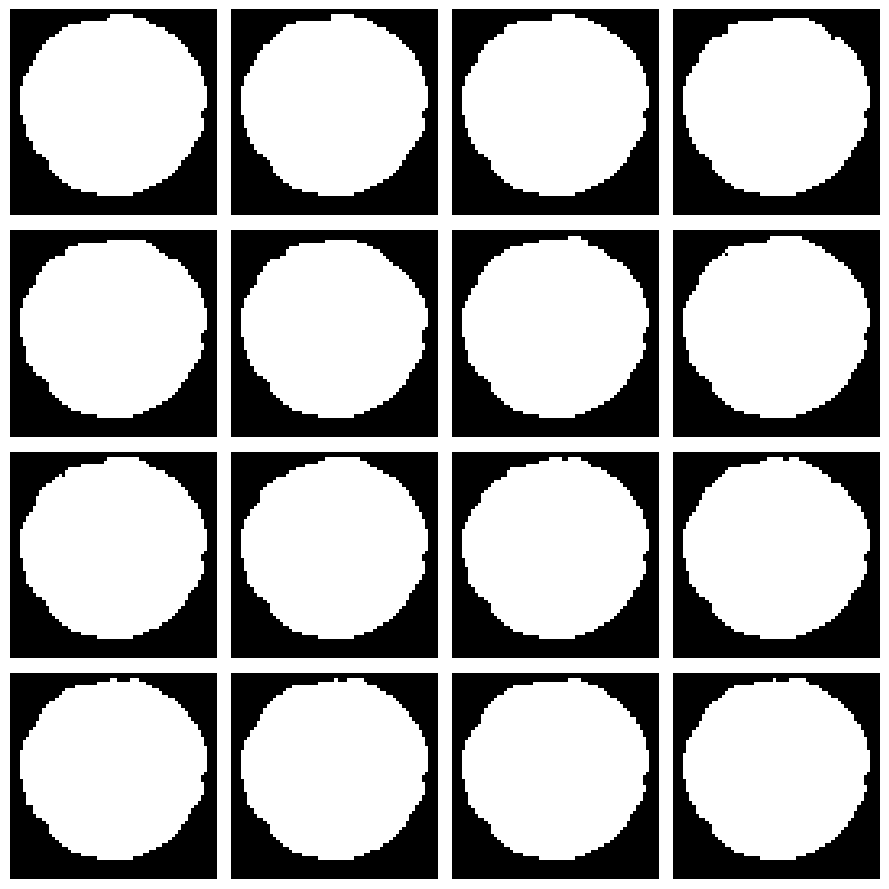

torch.Size([24, 15, 5, 64, 64])


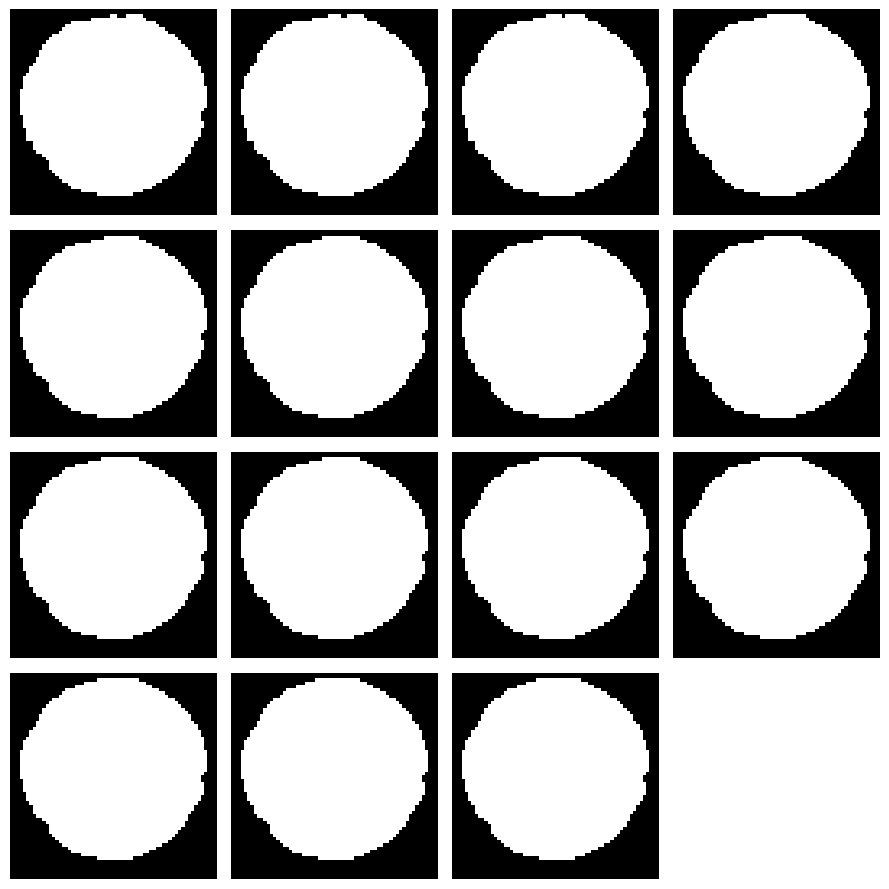

In [22]:
with torch.no_grad():
  for idx, (videos, targets) in enumerate(test_loader_masked):
    print(idx)
    print(videos.shape)
    show_mask(videos[1].data.cpu())
    pred = seg_clstm(videos, 15)
    print(pred.shape)
    show_mask(pred[1].data.cpu())
    break

In [23]:
print(pred[1].min())
print(pred[1].max())

tensor(-15.2768)
tensor(14.0494)


## Process data and generate comparison files
(if necessary)

In [ ]:
def process_and_store(path: str, test_loader_masked, bs, seg_clstm):
  with h5py.File(path, 'w') as f:
    test_group = f.create_group('test')
    lendataset = len(test_dataset_masked)
    num_log_frame = 16
    num_pred_frame = 15
    img_side_len = 64
    maskst_log_dset = test_group.create_dataset('masks_log', shape=(lendataset, num_log_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    maskst_targ_dset = test_group.create_dataset('masks_targ', shape=(lendataset, num_pred_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    maskst_pred_seg_dset = test_group.create_dataset('masks_pred_seg', shape=(lendataset, num_pred_frame, img_side_len, img_side_len/8, N_VALUES_CLOUD_MASK), dtype=np.uint8)
    with torch.no_grad():
      for idx, (videos, targets) in enumerate(test_loader_masked):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        mini = idx*bs
        maxi = (idx+1)*bs
        pred = seg_clstm(videos, 15, apply_softmax=True, hard_feedback=True)
        pred = torch.argmax(pred, dim=2)
        pred = torch.from_numpy(np.eye(N_VALUES_CLOUD_MASK)[pred.cpu()]).bool()
        pred = pred.permute((0, 1, 4, 2, 3))
        videos = videos.permute((0, 1, 3, 4, 2))
        targets = targets.permute((0, 1, 3, 4, 2))
        pred = pred.permute((0, 1, 3, 4, 2))
        maskst_log_dset[mini:maxi] = np.packbits(videos.bool().cpu().numpy(), axis=3)
        maskst_targ_dset[mini:maxi] = np.packbits(targets.bool().cpu().numpy(), axis=3)
        maskst_pred_seg_dset[mini:maxi] = np.packbits(pred.bool().cpu().numpy(), axis=3)
        if idx%10==0:
          print(f"{idx}/{len(test_loader_masked)}")

In [25]:
if IN_COLAB:
  if os.path.exists(drive_proc_mclstm_path):
    print('Masked clouds file already exists. Copying...')
    shutil.copyfile(drive_proc_mclstm_path, proc_mclstm_path)
  else:
    print('Masked clouds doesn\'t exist. Processing...')
    process_and_store(proc_mclstm_path, test_loader_masked, bs, seg_clstm)
    print('Saving in drive...')
    shutil.copyfile(proc_mclstm_path, drive_proc_mclstm_path)
else:
  if not os.path.exists(proc_mclstm_path):
    print('Masked clouds doesn\'t exist. Processing...')
    process_and_store(proc_mclstm_path, test_loader_masked, bs, seg_clstm)

In [26]:
if not os.path.exists(proc_mclstm_path):
  print('proc_mclstm_path file not available. Download it.')

with h5py.File(proc_mclstm_path, 'r') as fds:
    group_names = list(fds.keys())
    print(group_names)
    fds.close()

dsm = {}
for gname in group_names:
    dsm[gname] = xr.open_dataset(proc_mclstm_path, group=gname, engine="h5netcdf", phony_dims='sort')

['test']


## Load processed data

In [27]:
bs = 8

In [28]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: np.unpackbits(x, axis=1)),
    torch.from_numpy,
    transforms.Lambda(lambda x: torch.permute(x, (2, 0, 1)).float()),
])
btest_dataset_mask = common.VideoDataset(dsm['test']['masks_targ'], dsm['test']['masks_pred_seg'], transform=transform, stack_videos=False, device=device)
btest_loader_mask = DataLoader(btest_dataset_mask, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

In [29]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  print(idx)
  print(mtarg.shape)
  print(mseg.shape)
  break

/home/javgat/GOA/Repositorios/SkyMaskConvLSTM/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


0
torch.Size([8, 15, 5, 64, 64])
torch.Size([8, 15, 5, 64, 64])


0


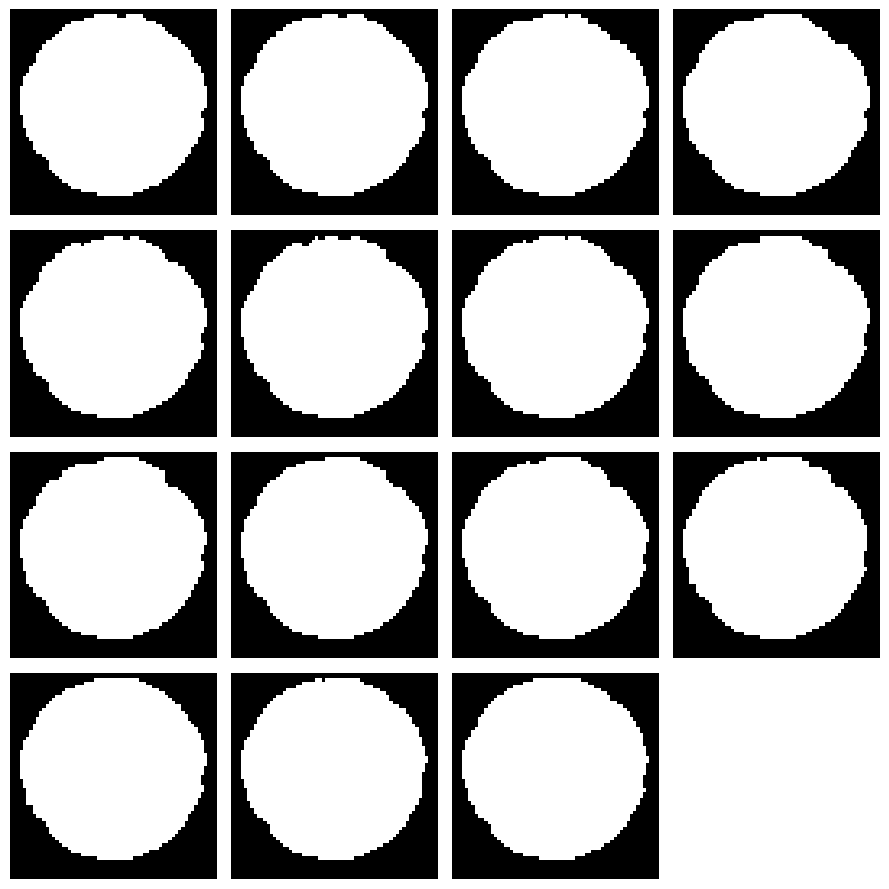

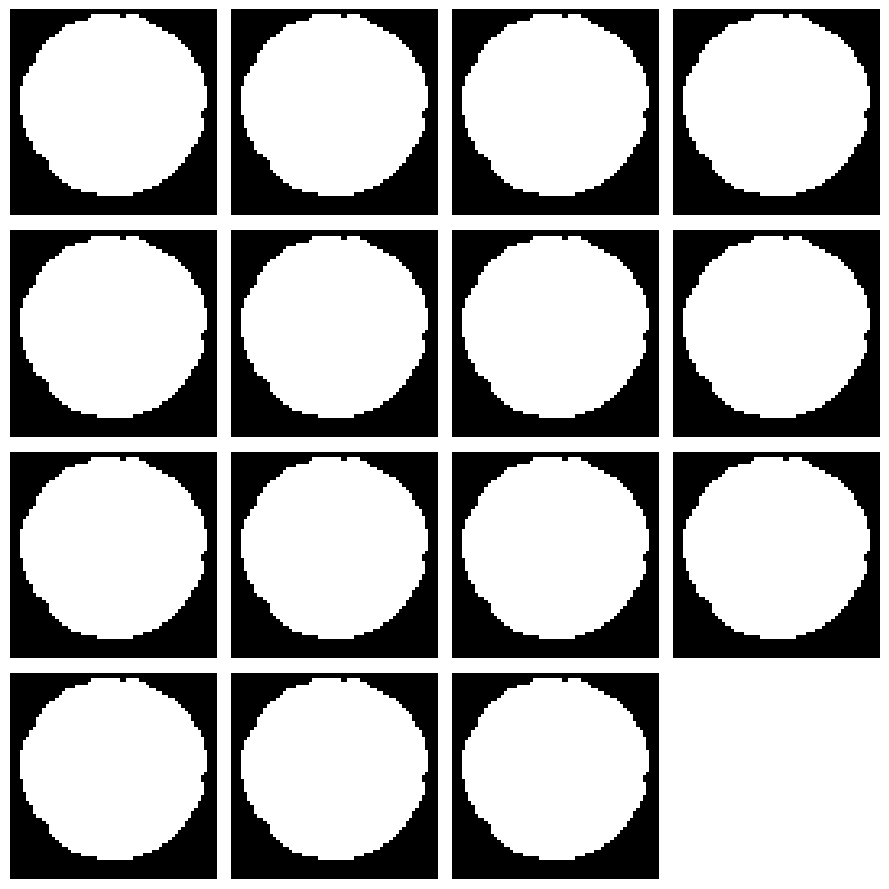

In [30]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  print(idx)
  showid = 3
  show_mask(mtarg[showid])
  show_mask(mseg[showid])
  break

In [31]:
def _show_vid_mask_data(vid_data):
  vid_data = vid_data[::2].flip(dims=(1,))
  voutput = torch.zeros(len(vid_data), 3, vid_data.size(-2), vid_data.size(-1), dtype=torch.float).to(device)
  for img_idx, img in enumerate(vid_data):
    img = img.unsqueeze(0)
    class_to_color = [torch.tensor([0, 0, 255]), torch.tensor([255, 255, 255]), torch.tensor([255, 255, 0]), torch.tensor([0, 255, 255]), torch.tensor([0, 0, 0])]
    output = torch.zeros(1, 3, vid_data.size(-2), vid_data.size(-1), dtype=torch.float).to(device)
    for class_idx, color in enumerate(class_to_color):
      mask = img[:,class_idx,:,:] == torch.max(img, dim=1)[0]
      mask = mask.unsqueeze(1) # should have shape 1, 1, 100, 100
      curr_color = color.reshape(1, 3, 1, 1).to(device)
      segment = mask*curr_color # should have shape 1, 3, 100, 100
      output += segment
    voutput[img_idx] = output.squeeze(0)
  torchvision.utils.save_image(voutput, 'save/real_image.png')
  display(idisplay.Image('save/real_image.png'))


def _show_vid_data(vid_data):
  vid_data = vid_data[::2].flip(dims=(1,))
  torchvision.utils.save_image(vid_data, 'save/real_image.png')
  display(idisplay.Image('save/real_image.png'))

## Full data processing

In [32]:
mse = nn.MSELoss()
_jaca = torchmetrics.JaccardIndex(task="multiclass", num_classes=5).to(device)
def jac(x, y):
  if len(x.shape) == 5:
    x = x.flatten(0, 1)
    y = y.flatten(0, 1)
  return _jaca(torch.argmax(x, axis=1), torch.argmax(y, axis=1))
try:
  _dice = torchmetrics.Dice().to(device)
except AttributeError:
  _dice = torchmetrics.segmentation.DiceScore(
      num_classes=5,
      input_format="index",
      average="micro",
      aggregation_level="global",
  ).to(device)
dice = lambda x, y: _dice(
    torch.argmax(x, axis=len(x.shape)-3),
    torch.argmax(y, axis=len(y.shape)-3)
)
_cce = nn.CrossEntropyLoss()
def cce(x, y):
  if len(x.shape) == 5:
    x = x.permute(0, 2, 1, 3, 4)
    y = y.permute(0, 2, 1, 3, 4)
  return _cce(x, y)
loss_functions = [mse, cce, jac, dice]

losses_tsteps_seg = [[[] for _ in range(15)] for _ in range(len(loss_functions))]
losses_seg = [0 for _ in range(len(loss_functions))]


for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  mtarg = mtarg.to(device, non_blocking=True)
  mseg = mseg.to(device, non_blocking=True)
  with torch.no_grad():
    for i in range(15):
      for l, lossf in enumerate(loss_functions):
        lossp = lossf(mseg[:,i,:,:,:], mtarg[:,i,:,:,:])
        losses_tsteps_seg[l][i].append(lossp.item())
    for l, lossf in enumerate(loss_functions):
      lossp = lossf(mseg, mtarg)
      losses_seg[l] += lossp.item()
    lossp = None
    if idx % 10 == 0:
        to_print = (
            f"B[{idx+1}/{len(btest_loader_mask)}]"
            f" AccLoss SEG: {np.mean(losses_seg)/bs:.4g} "
        )
        print(to_print)

B[1/559] AccLoss SEG: 0.09033 
B[11/559] AccLoss SEG: 0.9113 
B[21/559] AccLoss SEG: 1.674 
B[31/559] AccLoss SEG: 2.449 
B[41/559] AccLoss SEG: 3.224 
B[51/559] AccLoss SEG: 3.987 
B[61/559] AccLoss SEG: 4.765 
B[71/559] AccLoss SEG: 5.568 
B[81/559] AccLoss SEG: 6.378 
B[91/559] AccLoss SEG: 7.28 
B[101/559] AccLoss SEG: 8.1 
B[111/559] AccLoss SEG: 8.907 
B[121/559] AccLoss SEG: 9.708 
B[131/559] AccLoss SEG: 10.49 
B[141/559] AccLoss SEG: 11.3 
B[151/559] AccLoss SEG: 12.12 
B[161/559] AccLoss SEG: 12.9 
B[171/559] AccLoss SEG: 13.68 
B[181/559] AccLoss SEG: 14.47 
B[191/559] AccLoss SEG: 15.26 
B[201/559] AccLoss SEG: 16 
B[211/559] AccLoss SEG: 16.77 
B[221/559] AccLoss SEG: 17.54 
B[231/559] AccLoss SEG: 18.29 
B[241/559] AccLoss SEG: 19.09 
B[251/559] AccLoss SEG: 19.86 
B[261/559] AccLoss SEG: 20.63 
B[271/559] AccLoss SEG: 21.41 
B[281/559] AccLoss SEG: 22.19 
B[291/559] AccLoss SEG: 23 
B[301/559] AccLoss SEG: 23.77 
B[311/559] AccLoss SEG: 24.55 
B[321/559] AccLoss SEG: 25.

In [33]:
n_vidba = 559
losses_seg = np.array(losses_seg)/n_vidba

In [34]:
losses_tsteps_seg_path = os.path.join(data_folder, 'tsteps_seg.npy')

In [35]:
np.save(losses_tsteps_seg_path, np.array(losses_tsteps_seg))

In [36]:
losses_tsteps_seg = np.load(losses_tsteps_seg_path)

In [37]:
losses_tsteps_noseg_path = os.path.join(data_folder, 'tsteps_noseg.npy')
losses_tsteps_noseg = np.load(losses_tsteps_noseg_path)

In [38]:
means_seg = np.mean(losses_tsteps_seg, axis=2)
ci95_seg = 1.96 * sem(losses_tsteps_seg, axis=2)
std_seg = np.std(losses_tsteps_seg, axis=2)

In [39]:
print(repr(means_seg))
print(repr(losses_seg))
print(repr(std_seg))
print(repr(ci95_seg))

array([[0.01399486, 0.01846913, 0.02185222, 0.02455397, 0.02693772,
        0.02902492, 0.03086756, 0.03254114, 0.03410768, 0.03563144,
        0.03708002, 0.03846396, 0.03974633, 0.04096225, 0.04216774],
       [0.93981962, 0.95100531, 0.95946305, 0.96621741, 0.97217678,
        0.97739479, 0.98200138, 0.98618533, 0.99010168, 0.99391109,
        0.99753254, 1.0009924 , 1.00419833, 1.00723811, 1.01025185],
       [0.75273776, 0.71705121, 0.69358348, 0.67492193, 0.65944768,
        0.65443434, 0.64684231, 0.63936846, 0.63411693, 0.62748149,
        0.62218431, 0.61785834, 0.61326756, 0.60945976, 0.60587873],
       [0.96501286, 0.95382718, 0.94536944, 0.93861508, 0.93265571,
        0.9274377 , 0.92283111, 0.91864716, 0.91473081, 0.91092141,
        0.90729995, 0.90384009, 0.90063417, 0.89759438, 0.89458064]])
array([0.03109339, 0.98256602, 0.61592573, 0.92226651])
array([[0.01336092, 0.01772775, 0.0211156 , 0.02396158, 0.02660473,
        0.02889962, 0.03094917, 0.03284536, 0.03464048,

In [40]:
means_seg = np.zeros((len(loss_functions), 15))
stds_seg = np.zeros((len(loss_functions), 15))

for l in range(len(loss_functions)):
    for i in range(15):
        means_seg[l, i] = np.mean(losses_tsteps_seg[l][i])
        stds_seg[l, i] = np.std(losses_tsteps_seg[l][i])

In [41]:
print(losses_tsteps_seg)
print(losses_seg)

[[[0.00172119 0.00195312 0.00136719 ... 0.04178467 0.04572754 0.04977214]
  [0.00245361 0.00240479 0.0019043  ... 0.05397949 0.06364746 0.07832031]
  [0.0026123  0.00274658 0.0022583  ... 0.06343994 0.07720947 0.09638672]
  ...
  [0.00396729 0.00362549 0.00268555 ... 0.10594483 0.08896484 0.08398438]
  [0.00377197 0.0036377  0.00252686 ... 0.10582276 0.08851318 0.08557943]
  [0.00357666 0.00357666 0.00264893 ... 0.10803223 0.08476563 0.08893229]]

 [[0.90913558 0.90971529 0.90825045 ... 1.00929415 1.01915133 1.02926278]
  [0.91096652 0.91084445 0.90959322 ... 1.03978121 1.06395102 1.10063326]
  [0.91136324 0.91169894 0.91047823 ... 1.06343234 1.09785616 1.14579928]
  ...
  [0.91475075 0.9138962  0.91154635 ... 1.16969454 1.12724459 1.11479342]
  [0.91426241 0.91392678 0.91114956 ... 1.16938937 1.12611544 1.11878109]
  [0.91377413 0.91377413 0.91145486 ... 1.17491305 1.11674666 1.12716329]]

 [[0.99097496 0.989806   0.99282491 ... 0.70162195 0.68384051 0.61080605]
  [0.98716187 0.987462

In [42]:
losses_names = ['MSE', 'Cross Entropy', 'Jaccard Index', 'Dice Coefficient']

In [43]:
means_noseg = [[0.01870207, 0.02406489, 0.02789866, 0.03099857, 0.03347814,
        0.03552296, 0.03728211, 0.03871344, 0.04001388, 0.04119037,
        0.04238339, 0.04350626, 0.04451778, 0.0455299 , 0.04643907],
       [0.95158766, 0.96499472, 0.97457915, 0.98232892, 0.98852783,
        0.9936399 , 0.99803776, 1.00161609, 1.00486721, 1.00780843,
        1.01079096, 1.01359815, 1.01612694, 1.01865724, 1.02093017],
       [0.71730926, 0.68331353, 0.66281711, 0.64709313, 0.63529405,
        0.6357139 , 0.6280362 , 0.62292346, 0.61932218, 0.61323612,
        0.60802194, 0.60251451, 0.59863618, 0.59571261, 0.59398487],
       [0.95324483, 0.93983777, 0.93025334, 0.92250357, 0.91630466,
        0.91119259, 0.90679473, 0.9032164 , 0.89996529, 0.89702406,
        0.89404153, 0.89123435, 0.88870556, 0.88617526, 0.88390233]]
losses_noseg = [0.03668277, 0.99653945, 0.58664872, 0.90829309]
std_noseg = [[0.01715703, 0.0225521 , 0.02648864, 0.02976437, 0.0324006 ,
        0.03454966, 0.03634894, 0.03800827, 0.03949447, 0.04079178,
        0.04195408, 0.04304942, 0.04402911, 0.04507531, 0.04603875],
       [0.04289255, 0.05638023, 0.0662216 , 0.07441092, 0.0810015 ,
        0.08637415, 0.09087234, 0.09502067, 0.09873617, 0.10197945,
        0.1048852 , 0.10762354, 0.11007276, 0.11268828, 0.11509687],
       [0.16652   , 0.18226039, 0.18929121, 0.19572545, 0.19817211,
        0.20528554, 0.2099487 , 0.21268779, 0.21487099, 0.21617447,
        0.21725372, 0.21660256, 0.21627535, 0.21769164, 0.21973034],
       [0.04289257, 0.05638024, 0.0662216 , 0.07441093, 0.08100151,
        0.08637415, 0.09087235, 0.09502067, 0.09873617, 0.10197946,
        0.1048852 , 0.10762354, 0.11007277, 0.11268828, 0.11509687]]
ci95_noseg = [[0.00142358, 0.00187122, 0.00219785, 0.00246965, 0.00268839,
        0.0028667 , 0.003016  , 0.00315368, 0.00327699, 0.00338463,
        0.00348107, 0.00357196, 0.00365325, 0.00374005, 0.00381999],
       [0.00355894, 0.00467806, 0.00549463, 0.00617413, 0.00672097,
        0.00716676, 0.00753999, 0.00788419, 0.00819248, 0.00846158,
        0.00870268, 0.00892989, 0.00913311, 0.00935013, 0.00954998],
       [0.01381673, 0.01512277, 0.01570614, 0.01624001, 0.01644302,
        0.01703324, 0.01742016, 0.01764743, 0.01782858, 0.01793673,
        0.01802628, 0.01797225, 0.0179451 , 0.01806262, 0.01823178],
       [0.00355894, 0.00467806, 0.00549463, 0.00617413, 0.00672097,
        0.00716676, 0.00753999, 0.00788419, 0.00819248, 0.00846158,
        0.00870268, 0.00892989, 0.00913311, 0.00935013, 0.00954998]]

In [44]:
means_noseg = np.mean(losses_tsteps_noseg, axis=2)
ci95_noseg = 1.96 * sem(losses_tsteps_noseg, axis=2)
std_noseg = np.std(losses_tsteps_noseg, axis=2)

In [45]:
losses_names = ['MSE', 'Cross Entropy', 'Intersection over Union', 'Dice Coefficient']

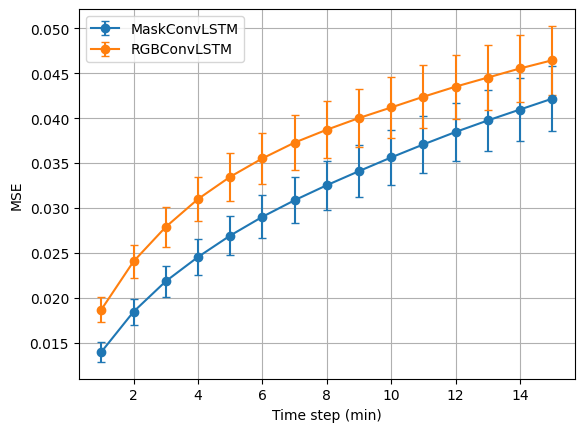

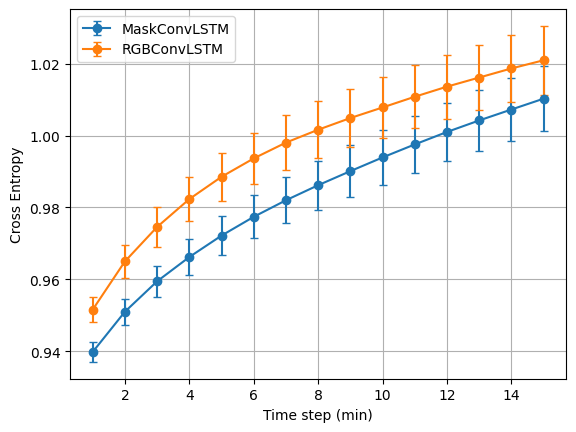

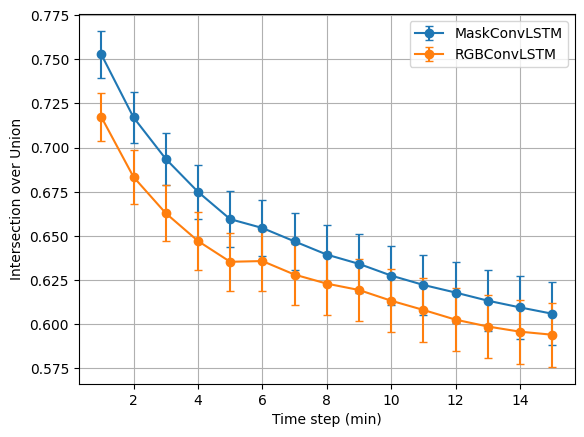

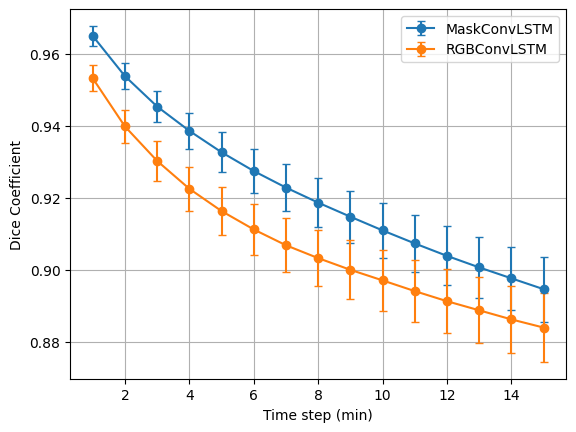

In [46]:
for ms, cs, mns, cns, name in zip(means_seg, ci95_seg, means_noseg, ci95_noseg, losses_names):
  #plt.plot(range(1, 16), lstes, '-o', label='MaskConvLSTM')
  plt.errorbar(range(1, 16), ms, cs, fmt="-o", label="MaskConvLSTM", capsize=3)
  #plt.plot(range(1, 16), lstens, '-o', label='ConvLSTM')
  plt.errorbar(range(1, 16), mns, cns, fmt="-o", label="RGBConvLSTM", capsize=3)
  plt.xlabel('Time step (min)')
  plt.ylabel(name)
  plt.legend()
  plt.grid()
  plt.show()

In [47]:
p_vals = []

print("Timestep | p-value | significant?")
print("-----------------------------")

for lseg, lnoseg, name in zip(losses_tsteps_seg, losses_tsteps_noseg, losses_names):
    for t in range(15):
        seg = np.array(lseg[t])
        nose = np.array(lnoseg[t])

        # Paired t-test
        stat, p = ttest_rel(seg, nose)
        p_vals.append(p)

        print(f"t+{t+1:2}     | {p:.4e} | {'YES' if p < 0.05 else 'no'}")

Timestep | p-value | significant?
-----------------------------
t+ 1     | 1.0019e-67 | YES
t+ 2     | 3.7307e-49 | YES
t+ 3     | 1.5475e-37 | YES
t+ 4     | 2.1742e-31 | YES
t+ 5     | 1.3725e-26 | YES
t+ 6     | 2.7352e-23 | YES
t+ 7     | 1.9202e-21 | YES
t+ 8     | 8.7999e-19 | YES
t+ 9     | 2.1432e-16 | YES
t+10     | 5.7081e-14 | YES
t+11     | 2.3023e-12 | YES
t+12     | 9.2134e-11 | YES
t+13     | 2.4709e-09 | YES
t+14     | 2.6943e-08 | YES
t+15     | 4.8336e-07 | YES
t+ 1     | 1.0019e-67 | YES
t+ 2     | 3.7308e-49 | YES
t+ 3     | 1.5475e-37 | YES
t+ 4     | 2.1742e-31 | YES
t+ 5     | 1.3725e-26 | YES
t+ 6     | 2.7352e-23 | YES
t+ 7     | 1.9202e-21 | YES
t+ 8     | 8.7999e-19 | YES
t+ 9     | 2.1432e-16 | YES
t+10     | 5.7081e-14 | YES
t+11     | 2.3023e-12 | YES
t+12     | 9.2133e-11 | YES
t+13     | 2.4709e-09 | YES
t+14     | 2.6943e-08 | YES
t+15     | 4.8336e-07 | YES
t+ 1     | 2.6343e-26 | YES
t+ 2     | 2.7057e-23 | YES
t+ 3     | 6.7913e-18 | YES
t+ 4     | 6

In [48]:
from sklearn.metrics import confusion_matrix

def compute_avg_conf_matrix(predictions, targets, num_classes=5):
    conf_total = np.zeros((num_classes, num_classes), dtype=np.int64)
    for y_true, y_pred in zip(targets, predictions):
        y_true = torch.argmax(y_true, dim=0)
        y_pred = torch.argmax(y_pred, dim=0)
        cm = confusion_matrix(y_true.flatten(), y_pred.flatten(), labels=list(range(num_classes)))
        conf_total += cm
    return conf_total

In [49]:
confs_tsteps_seg = [np.zeros((5, 5)) for _ in range(15)]
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  with torch.no_grad():
    for i in range(15):
      confs_tsteps_seg[i] += compute_avg_conf_matrix(mseg[:,i,:,:,:], mtarg[:,i,:,:,:])
    if idx % 25 == 0:
        to_print = (
            f"B[{idx+1}/{len(btest_loader_mask)}]"
        )
        print(to_print)
        display(confs_tsteps_seg[0])

B[1/559]


array([[12615.,     0.,     0.,    90.,     0.],
       [    0.,     0.,     0.,     0.,     0.],
       [    0.,     0.,     0.,     0.,     0.],
       [   51.,     0.,     0., 20012.,     0.],
       [    0.,     0.,     0.,     0.,     0.]])

B[26/559]


array([[3.23671e+05, 2.83000e+02, 0.00000e+00, 2.24600e+03, 1.00000e+00],
       [2.96000e+02, 1.04603e+05, 2.13000e+02, 1.15830e+04, 1.42100e+03],
       [0.00000e+00, 1.99000e+02, 2.36400e+03, 6.54000e+02, 4.00000e+01],
       [1.77900e+03, 8.73000e+03, 6.28000e+02, 3.79267e+05, 1.64700e+03],
       [0.00000e+00, 3.42600e+03, 1.78000e+02, 4.47900e+03, 4.26000e+03]])

B[51/559]


...

array([[6.078634e+06, 2.671000e+03, 0.000000e+00, 3.044300e+04,
        5.800000e+01],
       [2.562000e+03, 1.503117e+06, 1.616000e+03, 1.672380e+05,
        4.095700e+04],
       [0.000000e+00, 1.732000e+03, 2.499500e+04, 2.166000e+03,
        1.239000e+03],
       [2.759600e+04, 1.172940e+05, 1.688000e+03, 8.004602e+06,
        2.918300e+04],
       [5.000000e+01, 5.698500e+04, 1.375000e+03, 4.843400e+04,
        2.721330e+05]])

B[526/559]


array([[6.378304e+06, 2.719000e+03, 0.000000e+00, 3.177000e+04,
        5.900000e+01],
       [2.584000e+03, 1.541593e+06, 1.616000e+03, 1.797700e+05,
        4.237600e+04],
       [0.000000e+00, 1.732000e+03, 2.499500e+04, 2.166000e+03,
        1.239000e+03],
       [2.878800e+04, 1.257420e+05, 1.688000e+03, 8.444562e+06,
        3.220600e+04],
       [5.200000e+01, 6.163200e+04, 1.375000e+03, 5.272800e+04,
        2.762720e+05]])

B[551/559]


array([[6.676831e+06, 2.800000e+03, 0.000000e+00, 3.351700e+04,
        5.900000e+01],
       [2.659000e+03, 1.585265e+06, 1.617000e+03, 1.986740e+05,
        4.301100e+04],
       [0.000000e+00, 1.735000e+03, 2.501700e+04, 2.194000e+03,
        1.252000e+03],
       [3.035500e+04, 1.354860e+05, 1.697000e+03, 8.876011e+06,
        3.318000e+04],
       [5.200000e+01, 6.533600e+04, 1.383000e+03, 5.844500e+04,
        2.785920e+05]])

In [50]:
path_conf_seg = os.path.join(data_folder, 'confs_tsteps_seg.npy')

In [51]:
np.save(path_conf_seg, confs_tsteps_seg)

In [52]:
confs_tsteps_seg = np.load(path_conf_seg)

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conf_matrix(cm, classes, title, ax, normalize=True):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='YlGnBu', xticklabels=classes, yticklabels=classes, square=True, cbar=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)

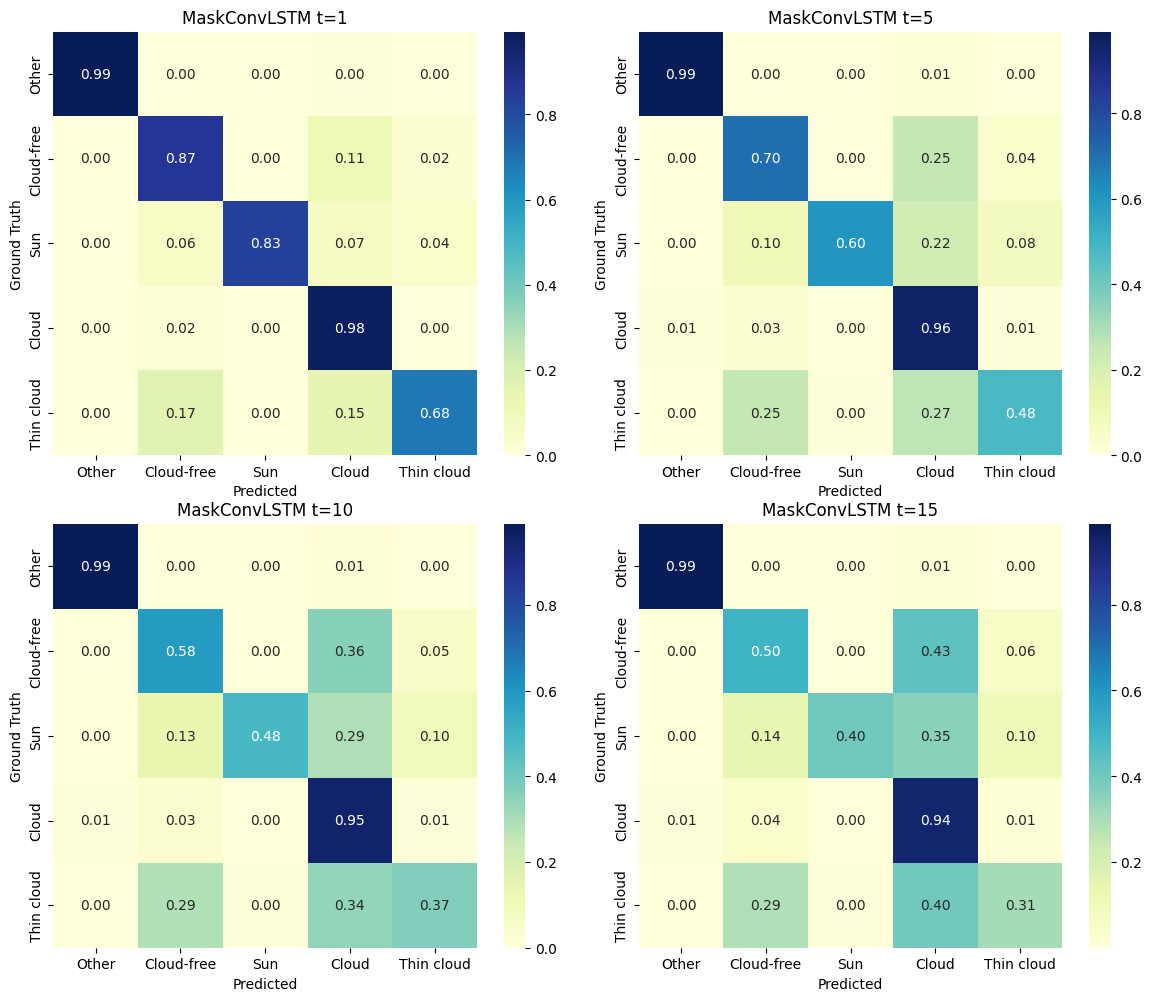

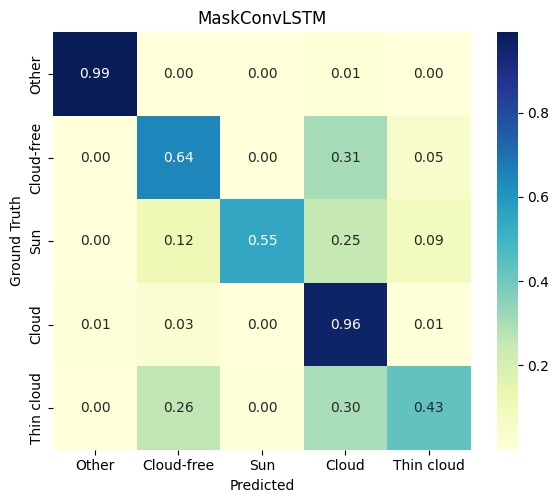

In [54]:
class_names = ["Other", "Cloud-free", "Sun", "Cloud", "Thin cloud"]
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, step in enumerate([0, 4, 9, 14]):
    plot_conf_matrix(confs_tsteps_seg[step], class_names, f"MaskConvLSTM t={step+1}", axs[i//2][i%2])
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
plot_conf_matrix(np.sum(confs_tsteps_seg, axis=0), class_names, "MaskConvLSTM", ax)
plt.tight_layout()
plt.show()

In [55]:
def plot_conf_matrix_precission(cm, classes, title, ax, normalize=True):
    cm = cm.T
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
    cm = cm.T
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='YlGnBu', xticklabels=classes, yticklabels=classes, square=True, cbar=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)

In [56]:
class_names = ["Other", "Cloud-free", "Sun", "Cloud", "Thin cloud"]

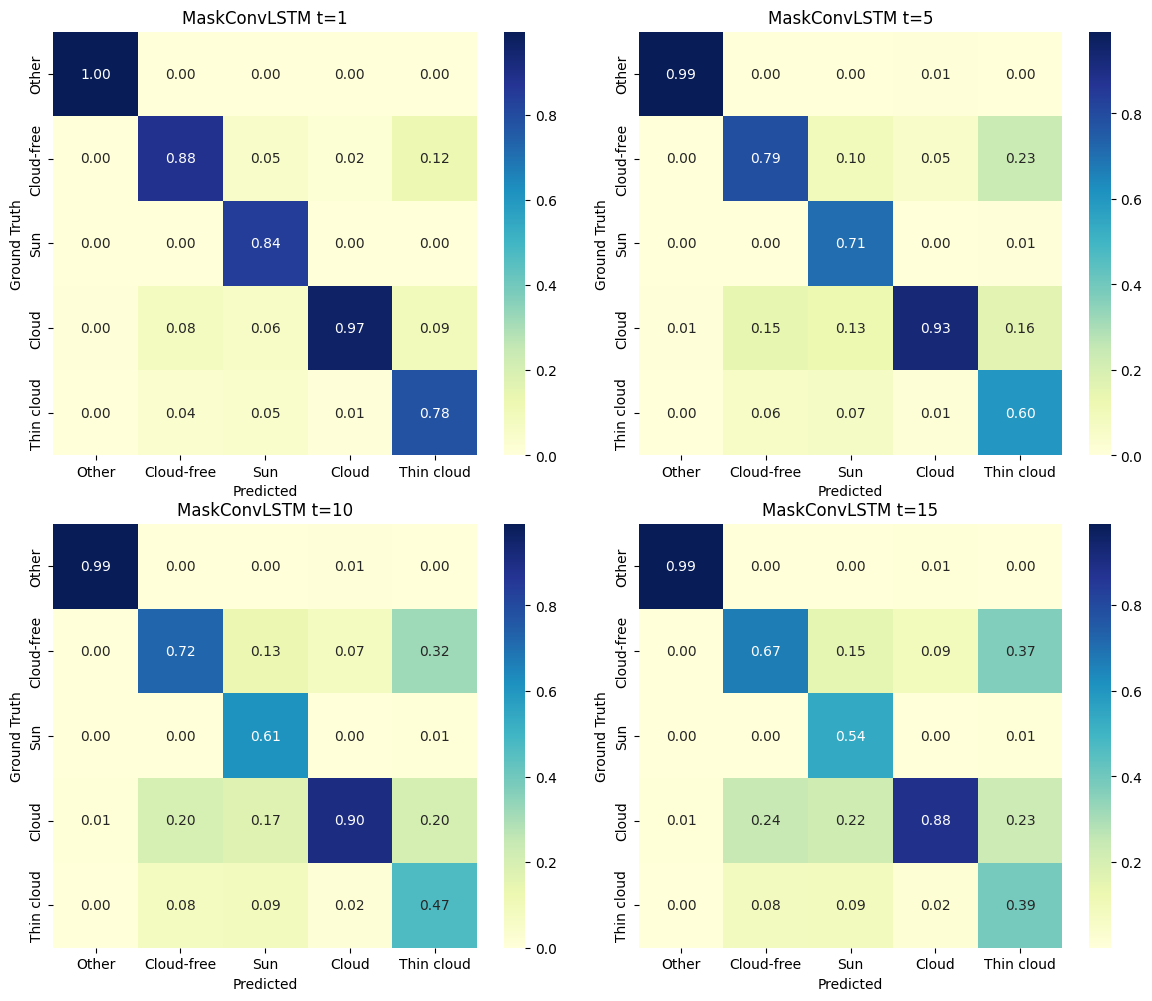

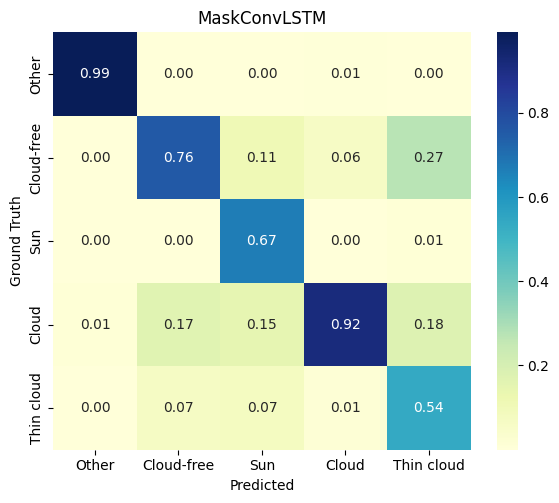

In [57]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, step in enumerate([0, 4, 9, 14]):
    plot_conf_matrix_precission(confs_tsteps_seg[step], class_names, f"MaskConvLSTM t={step+1}", axs[i//2][i%2])
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
plot_conf_matrix_precission(np.sum(confs_tsteps_seg, axis=0), class_names, "MaskConvLSTM", ax)
plt.tight_layout()
plt.show()

In [58]:
def iou_dice_per_class_per_timestep(confs_tsteps_seg, eps=1e-7):
  """
  confs_tsteps_seg: list de length T
      cada elemento: numpy array (C, C), filas=GT, cols=Pred

  devuelve:
      iou_t:   (T, C)
      dice_t:  (T, C)
      support: (T, C)  # nº pix GT por clase
  """
  T = len(confs_tsteps_seg)
  C = confs_tsteps_seg[0].shape[0]

  iou_t = np.zeros((T, C), dtype=np.float64)
  dice_t = np.zeros((T, C), dtype=np.float64)
  support_t = np.zeros((T, C), dtype=np.float64)

  for t, cm in enumerate(confs_tsteps_seg):
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    denom_iou = tp + fp + fn
    denom_dice = 2 * tp + fp + fn

    iou_t[t] = np.divide(tp, denom_iou + eps)
    dice_t[t] = np.divide(2 * tp, denom_dice + eps)
    support_t[t] = support

  return iou_t, dice_t, support_t

In [59]:
iou_t, dice_t, support_t = iou_dice_per_class_per_timestep(confs_tsteps_seg)


In [60]:
tsteps_iou_noseg_path = os.path.join(data_folder, 'tsteps_iou_noseg.npy')
tsteps_dice_noseg_path = os.path.join(data_folder, 'tsteps_dice_noseg.npy')
ns_iou_t = np.load(tsteps_iou_noseg_path)
ns_dice_t = np.load(tsteps_dice_noseg_path)

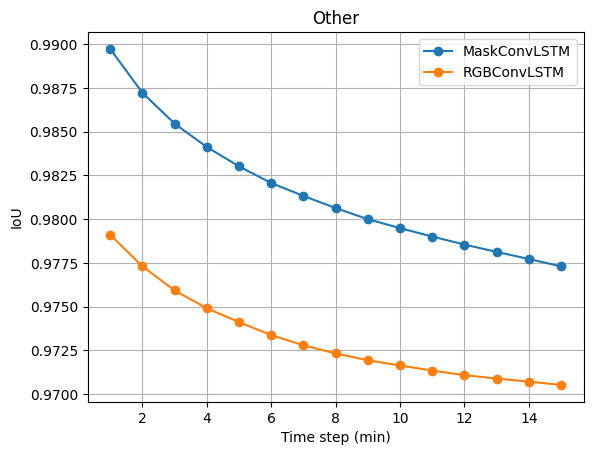

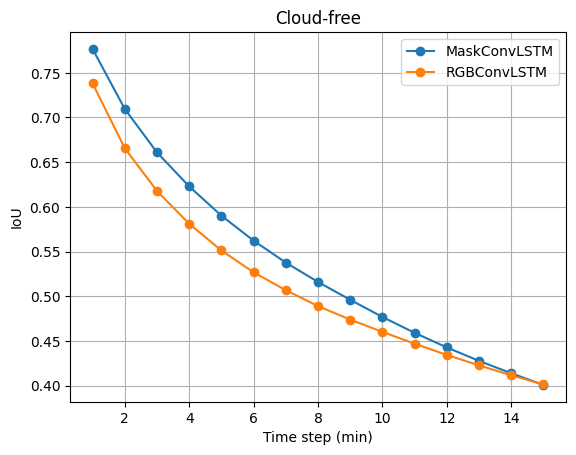

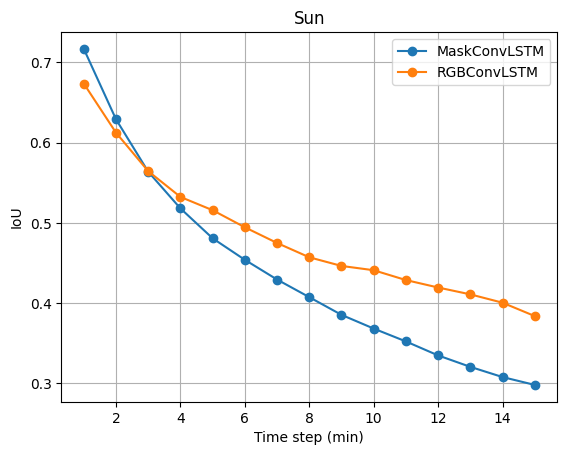

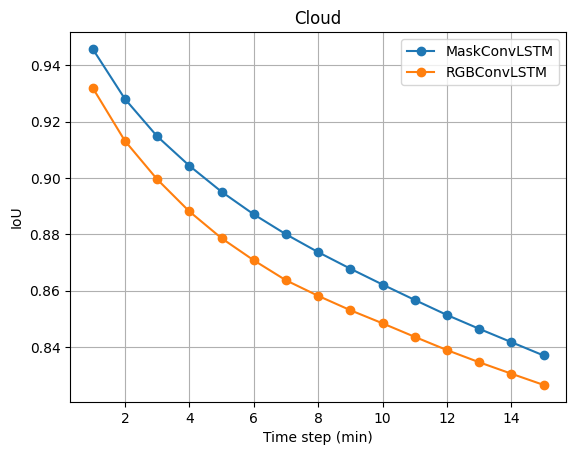

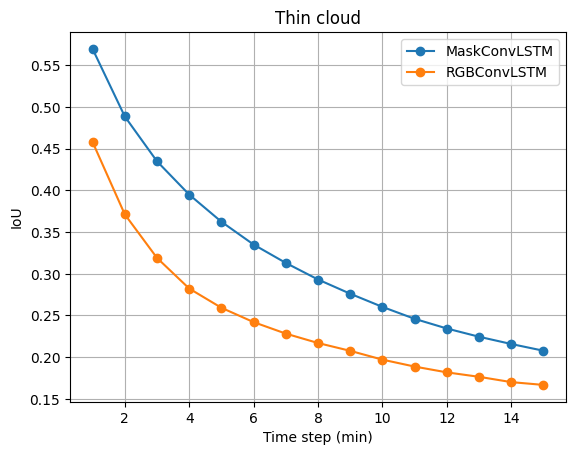

In [61]:
for i, cname in enumerate(class_names):
  segvals = iou_t[:, i]
  nosegvals = ns_iou_t[:, i]
  plt.plot(range(1, 16), segvals, '-o', label='MaskConvLSTM')
  plt.plot(range(1, 16), nosegvals, '-o', label='RGBConvLSTM')
  plt.xlabel('Time step (min)')
  plt.title(cname)
  plt.ylabel("IoU")
  plt.legend()
  plt.grid()
  plt.show()

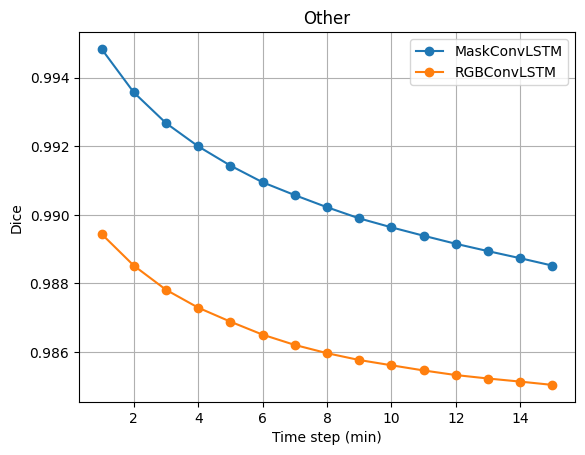

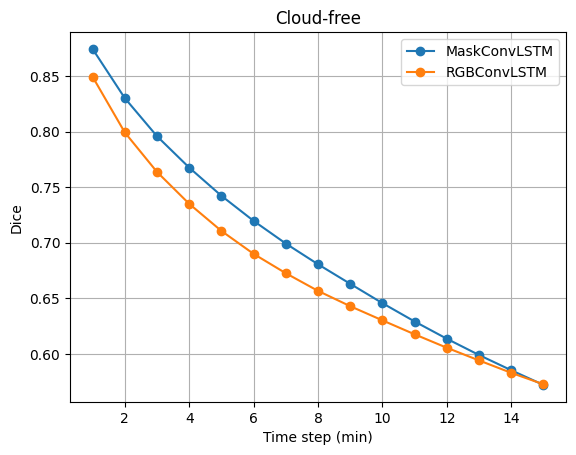

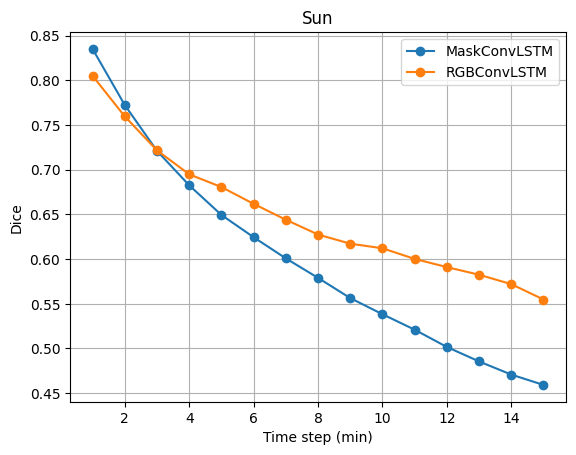

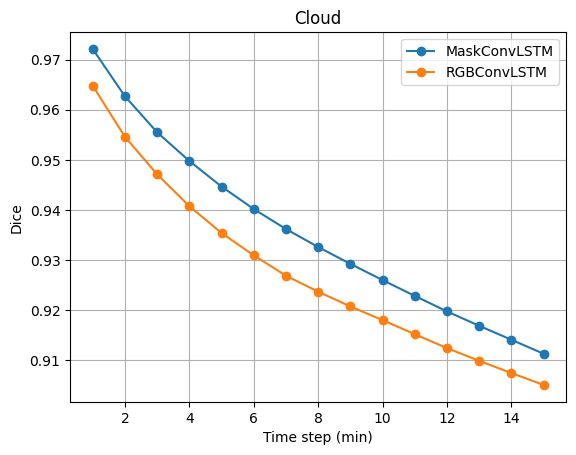

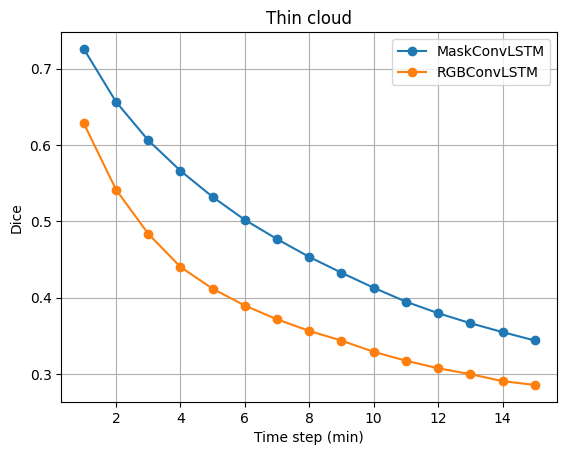

In [62]:
for i, cname in enumerate(class_names):
  segvals = dice_t[:, i]
  nosegvals = ns_dice_t[:, i]
  plt.plot(range(1, 16), segvals, '-o', label='MaskConvLSTM')
  plt.plot(range(1, 16), nosegvals, '-o', label='RGBConvLSTM')
  plt.xlabel('Time step (min)')
  plt.title(cname)
  plt.ylabel("Dice")
  plt.legend()
  plt.grid()
  plt.show()

In [63]:
path_confs_tsteps_noseg = os.path.join(data_folder, 'confs_noseg.npy')
confs_tsteps_noseg = np.load(path_confs_tsteps_noseg)

In [64]:
amounts = np.array(confs_tsteps_seg).sum(axis=2).sum(axis=0)
print(amounts/amounts.sum())

[0.371733   0.10698999 0.00169563 0.49653055 0.02305082]


In [65]:
def get_diag(cm):
    cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm = np.nan_to_num(cm)
    return np.diag(cm)

seg_diags = np.zeros((15, 5))
for i in range(15):
    seg_diags[i] += get_diag(confs_tsteps_seg[i])
print(class_names)
print(seg_diags)

['Other', 'Cloud-free', 'Sun', 'Cloud', 'Thin cloud']
[[0.99459612 0.86525445 0.82843235 0.97720711 0.68027803]
 [0.9932447  0.81129719 0.7509837  0.97121889 0.60177952]
 [0.99229522 0.76869736 0.68661599 0.96683547 0.54981959]
 [0.99158897 0.73324567 0.63925283 0.96353826 0.51053194]
 [0.99101369 0.70175955 0.60024972 0.96056773 0.47787008]
 [0.99052531 0.67385972 0.57116252 0.95800872 0.44996242]
 [0.99016484 0.6487916  0.54539837 0.95581482 0.4267908 ]
 [0.98981854 0.62616407 0.52270888 0.95386815 0.40529068]
 [0.98949351 0.6049562  0.4988915  0.95211355 0.38648638]
 [0.98921883 0.58448147 0.47993615 0.95040176 0.36866233]
 [0.98896019 0.56521018 0.46273262 0.94869769 0.3524152 ]
 [0.98871546 0.54730919 0.44306353 0.94698068 0.33886162]
 [0.9884971  0.53074503 0.42656093 0.94536106 0.32723389]
 [0.98829197 0.51540604 0.41190595 0.94371845 0.31696535]
 [0.98807055 0.50076222 0.40044819 0.94210444 0.30706888]]


In [66]:
def get_precision_diag(cm):
    cm = cm.astype('float') / cm.sum(axis=0, keepdims=True)
    cm = np.nan_to_num(cm)
    return np.diag(cm)

seg_diags = np.zeros((15, 5))
noseg_diags = np.zeros((15, 5))
for i in range(15):
    seg_diags[i] += get_precision_diag(confs_tsteps_seg[i])
    noseg_diags[i] += get_precision_diag(confs_tsteps_noseg[i])
print(class_names)
print(seg_diags)
print(noseg_diags)

['Other', 'Cloud-free', 'Sun', 'Cloud', 'Thin cloud']
[[0.99508827 0.88363617 0.84192636 0.96713444 0.7782226 ]
 [0.9939033  0.84981991 0.79493192 0.95430848 0.72249548]
 [0.9930616  0.82494755 0.75917129 0.94444333 0.6756451 ]
 [0.99241145 0.80531302 0.73215906 0.9364135  0.6358557 ]
 [0.99186211 0.78766477 0.7073218  0.92928922 0.60015011]
 [0.99137871 0.77215224 0.68879782 0.92300812 0.56754478]
 [0.99098823 0.75823908 0.66880683 0.91736901 0.54015583]
 [0.99062838 0.74546547 0.64891693 0.9122563  0.51449454]
 [0.99030396 0.73347964 0.62887809 0.90743635 0.49152201]
 [0.99005512 0.7211087  0.61295715 0.90282665 0.46962434]
 [0.98982377 0.70941813 0.59612311 0.89836189 0.44887147]
 [0.98959788 0.69821674 0.57823885 0.89402541 0.43187202]
 [0.98938835 0.68737836 0.56340302 0.8900531  0.41689469]
 [0.98918027 0.67710023 0.54936783 0.88625993 0.40333315]
 [0.9889697  0.66715758 0.53830384 0.88243885 0.39095938]]
[[0.99443028 0.87679933 0.75907891 0.96171308 0.55770171]
 [0.99290058 0.84

In [67]:
for i, (srow, nsrow) in enumerate(zip(seg_diags, noseg_diags)):
    print(f"t={i+1} & {srow[0]:.3} & {srow[1]:.3} & {srow[2]:.3} & {srow[3]:.3} & {srow[4]:.3} & {nsrow[0]:.3} & {nsrow[1]:.3} & {nsrow[2]:.3} & {nsrow[3]:.3} & {nsrow[4]:.3} \\\\")

t=1 & 0.995 & 0.884 & 0.842 & 0.967 & 0.778 & 0.994 & 0.877 & 0.759 & 0.962 & 0.558 \\
t=2 & 0.994 & 0.85 & 0.795 & 0.954 & 0.722 & 0.993 & 0.842 & 0.711 & 0.952 & 0.459 \\
t=3 & 0.993 & 0.825 & 0.759 & 0.944 & 0.676 & 0.992 & 0.812 & 0.667 & 0.945 & 0.402 \\
t=4 & 0.992 & 0.805 & 0.732 & 0.936 & 0.636 & 0.991 & 0.786 & 0.639 & 0.938 & 0.363 \\
t=5 & 0.992 & 0.788 & 0.707 & 0.929 & 0.6 & 0.99 & 0.762 & 0.626 & 0.933 & 0.338 \\
t=6 & 0.991 & 0.772 & 0.689 & 0.923 & 0.568 & 0.99 & 0.741 & 0.606 & 0.928 & 0.321 \\
t=7 & 0.991 & 0.758 & 0.669 & 0.917 & 0.54 & 0.99 & 0.722 & 0.586 & 0.923 & 0.308 \\
t=8 & 0.991 & 0.745 & 0.649 & 0.912 & 0.514 & 0.989 & 0.705 & 0.57 & 0.919 & 0.299 \\
t=9 & 0.99 & 0.733 & 0.629 & 0.907 & 0.492 & 0.989 & 0.691 & 0.563 & 0.915 & 0.291 \\
t=10 & 0.99 & 0.721 & 0.613 & 0.903 & 0.47 & 0.989 & 0.678 & 0.56 & 0.912 & 0.282 \\
t=11 & 0.99 & 0.709 & 0.596 & 0.898 & 0.449 & 0.989 & 0.665 & 0.551 & 0.908 & 0.275 \\
t=12 & 0.99 & 0.698 & 0.578 & 0.894 & 0.432 & 0.989 & 

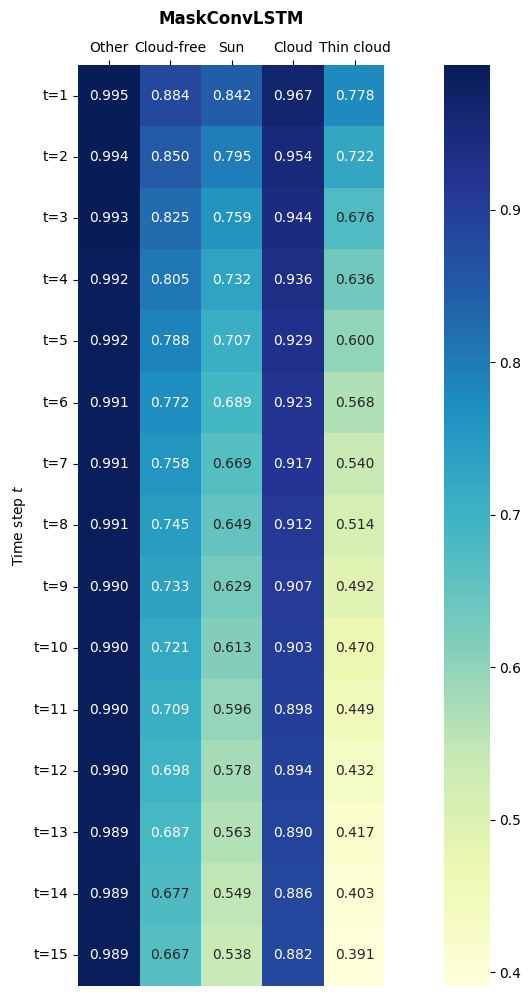

In [68]:
fig, ax = plt.subplots(figsize=(12, 10))
scores = seg_diags
tsteps_labels = [f't={i}' for i in range(1,16)]
sns.heatmap(scores, annot=True, fmt=".03f", cmap='YlGnBu', xticklabels=class_names, yticklabels=tsteps_labels, square=True, cbar=True, ax=ax)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('')
ax.set_ylabel('Time step $t$')
ax.text(0.5, 1.04, 'MaskConvLSTM', ha='center', va='bottom', fontsize='large', fontweight='bold', transform=ax.transAxes)
ax.axvline(5, color='white', linewidth=2)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


/home/javgat/GOA/Repositorios/SkyMaskConvLSTM/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


0/559


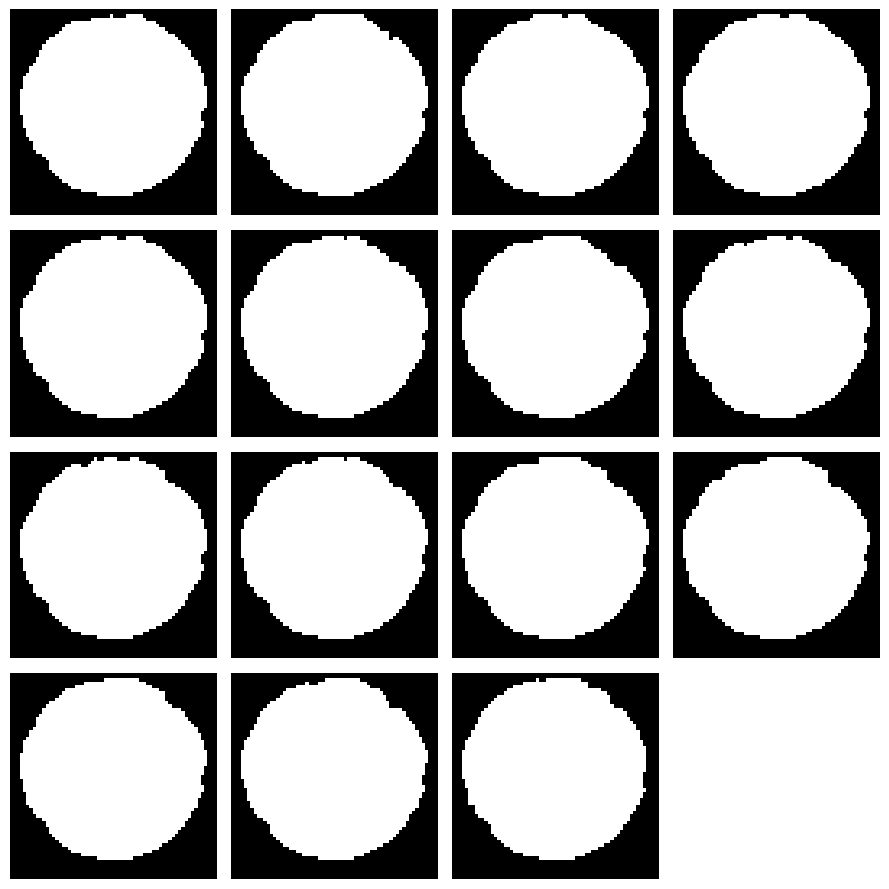

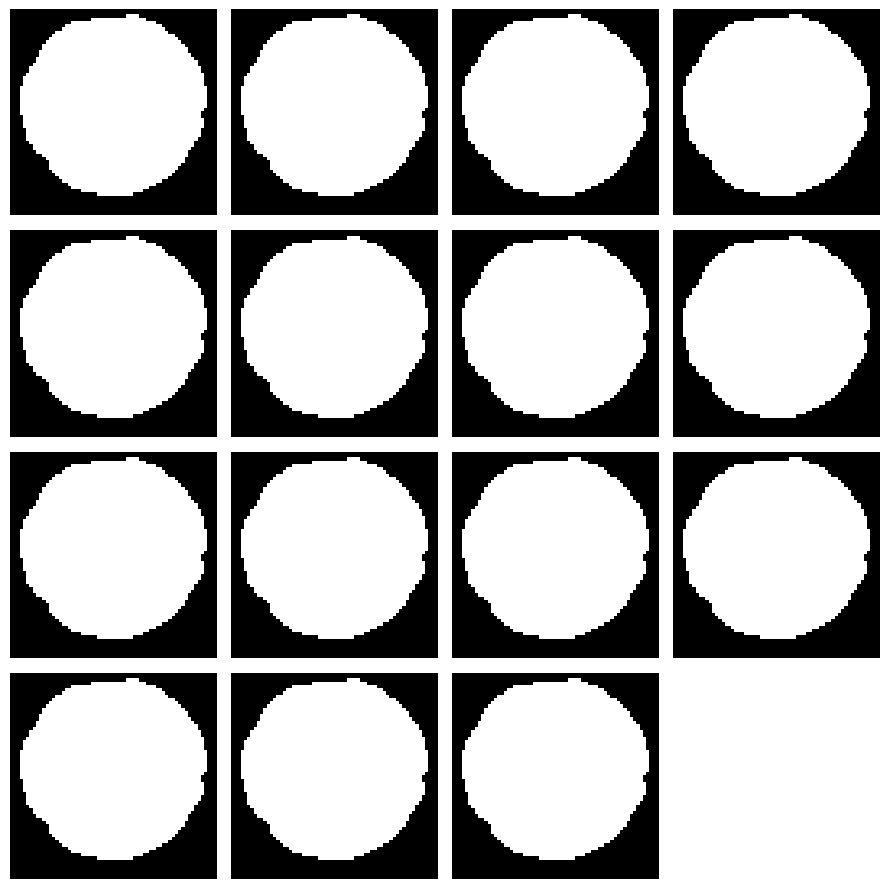

10/559


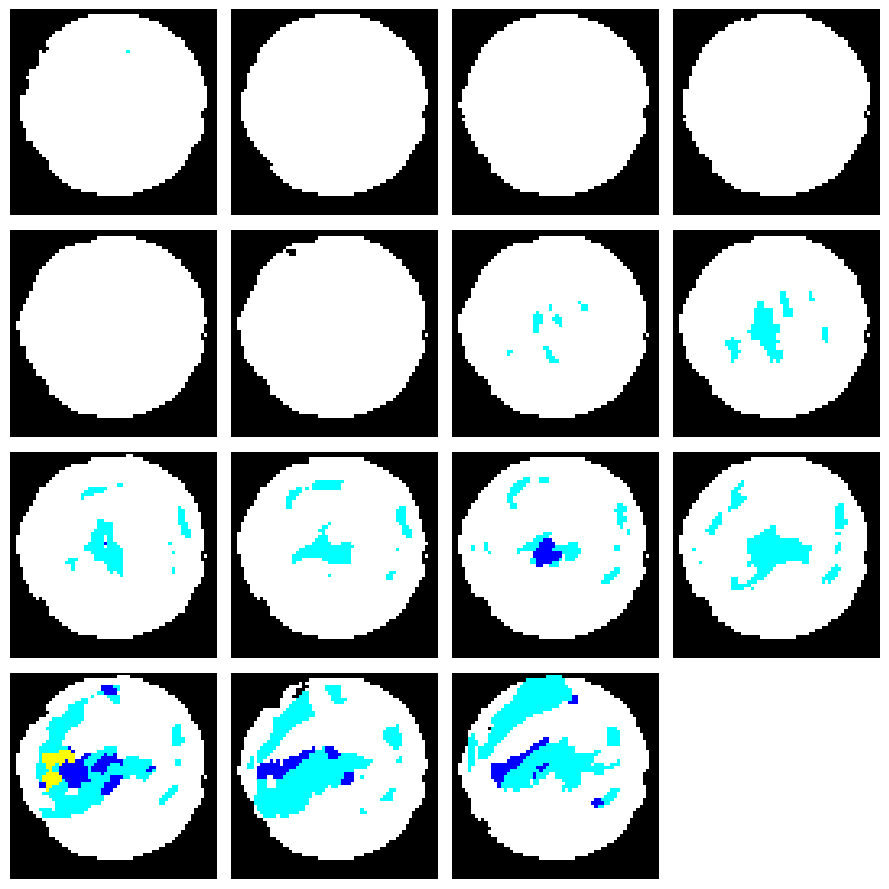

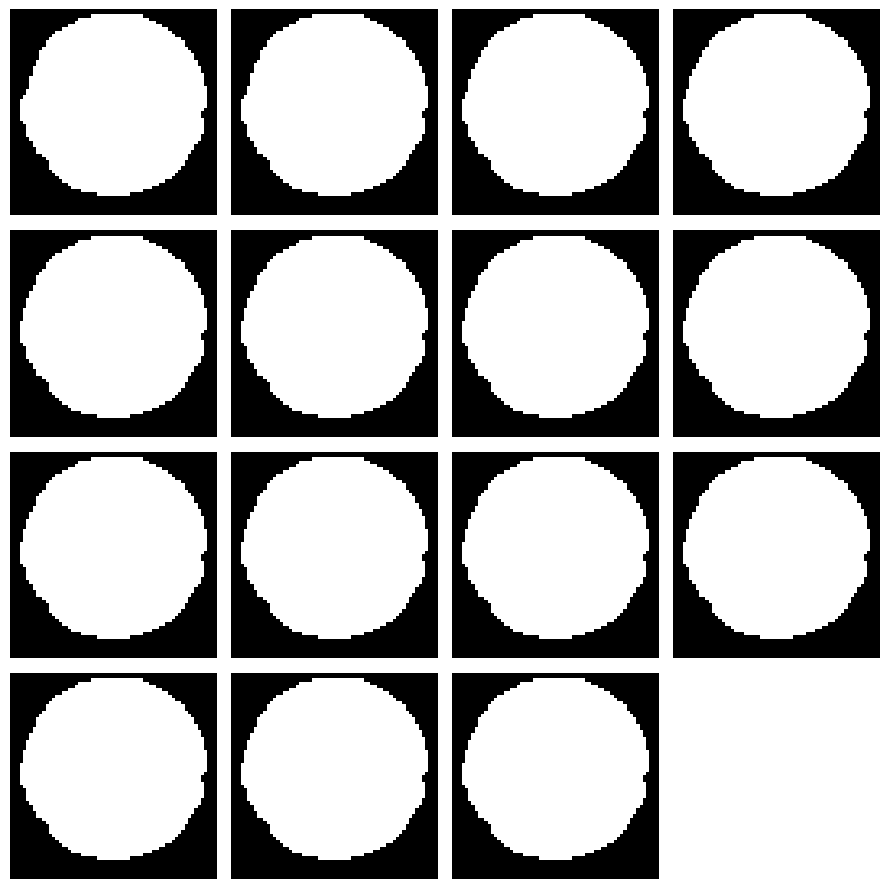

20/559


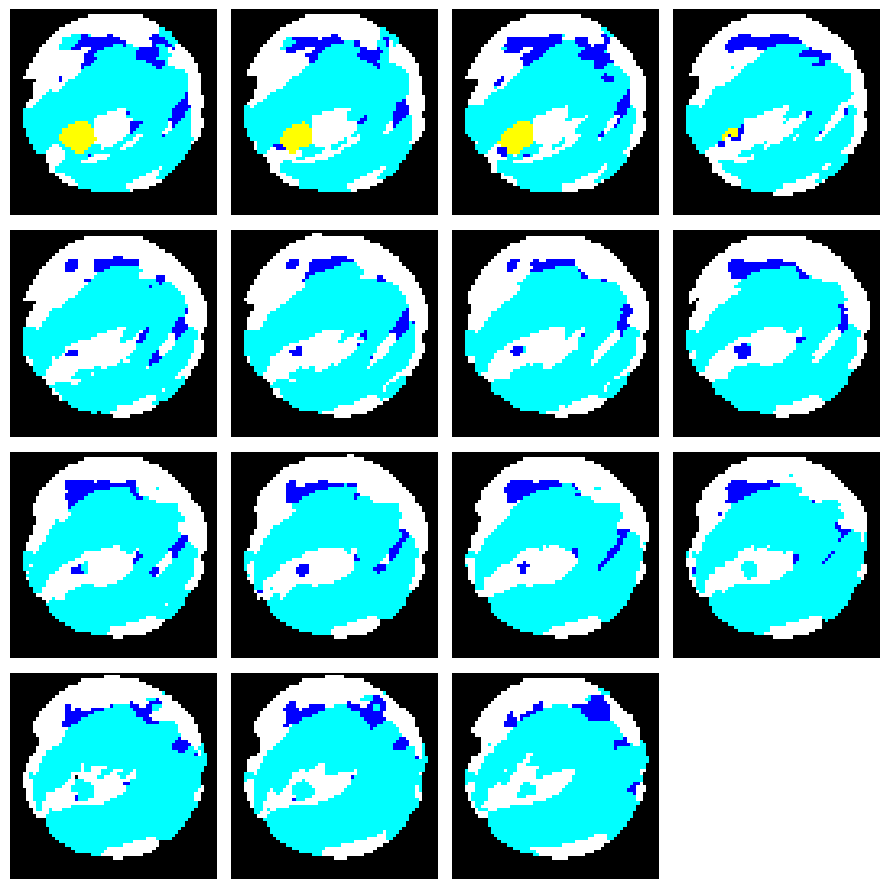

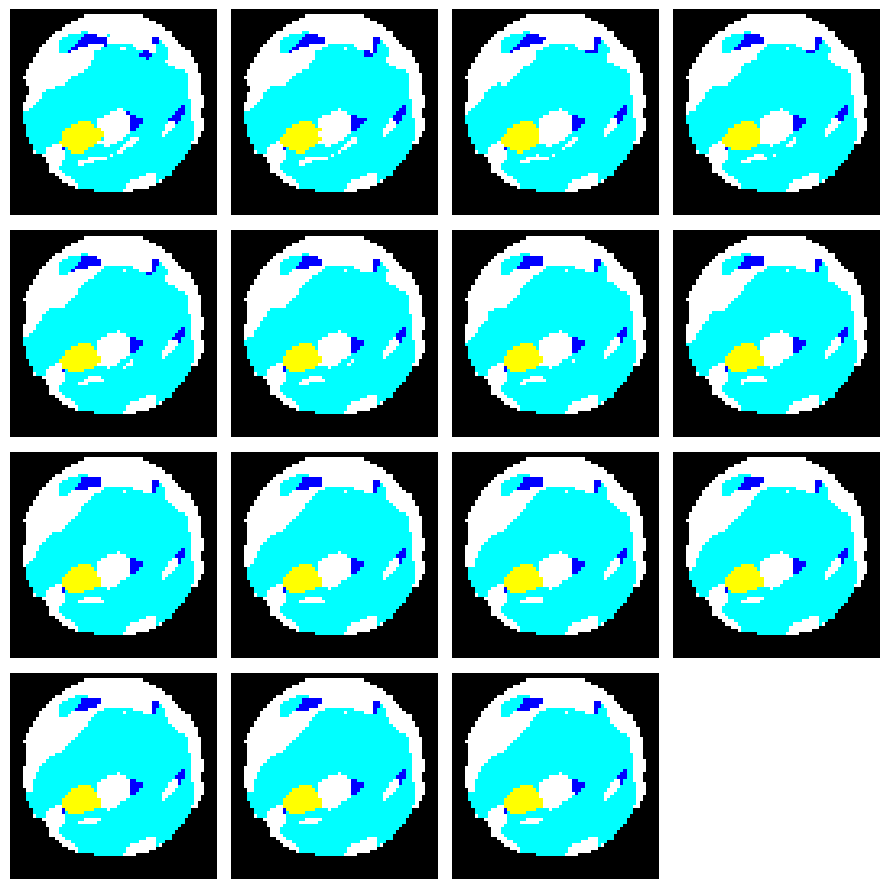

30/559


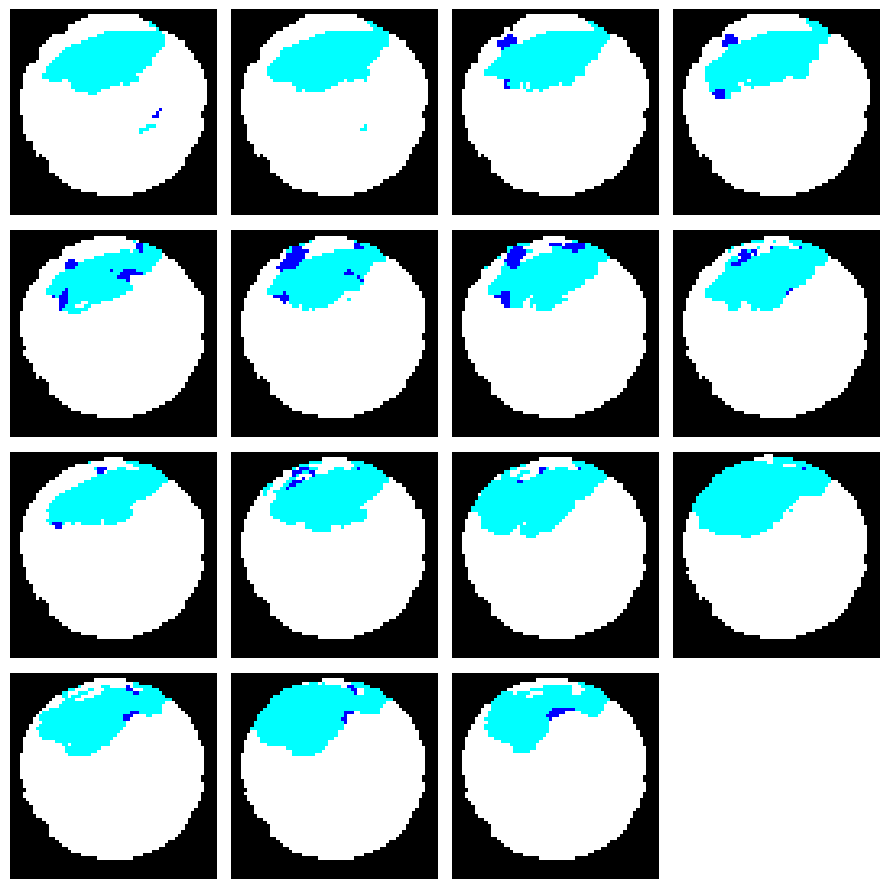

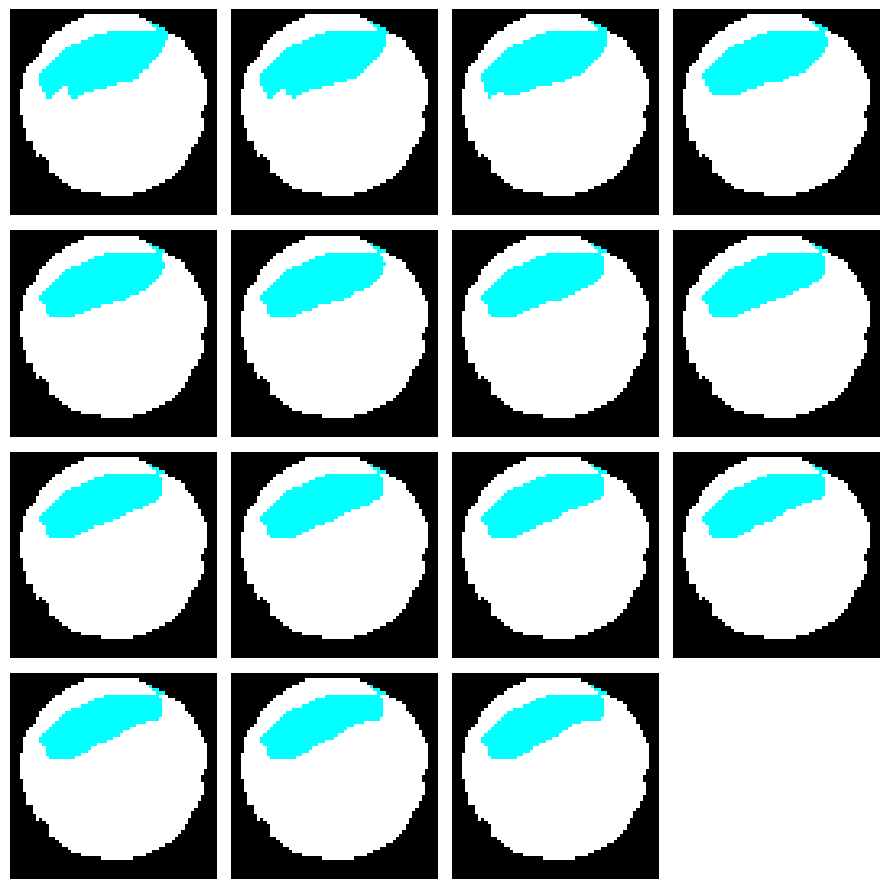

40/559


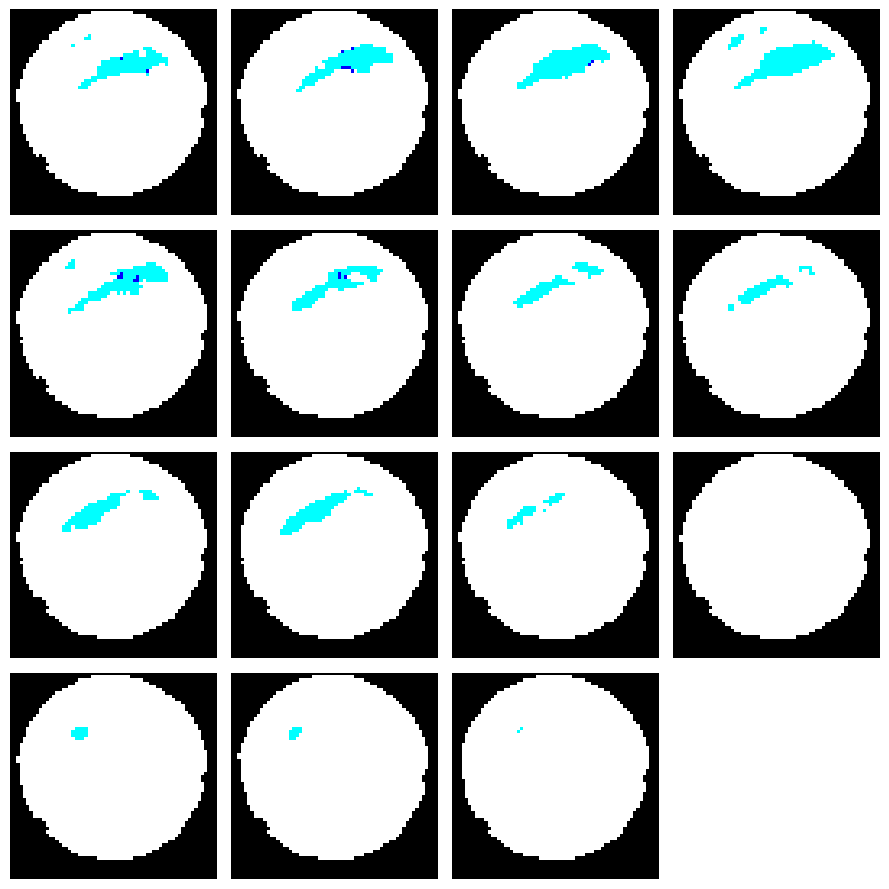

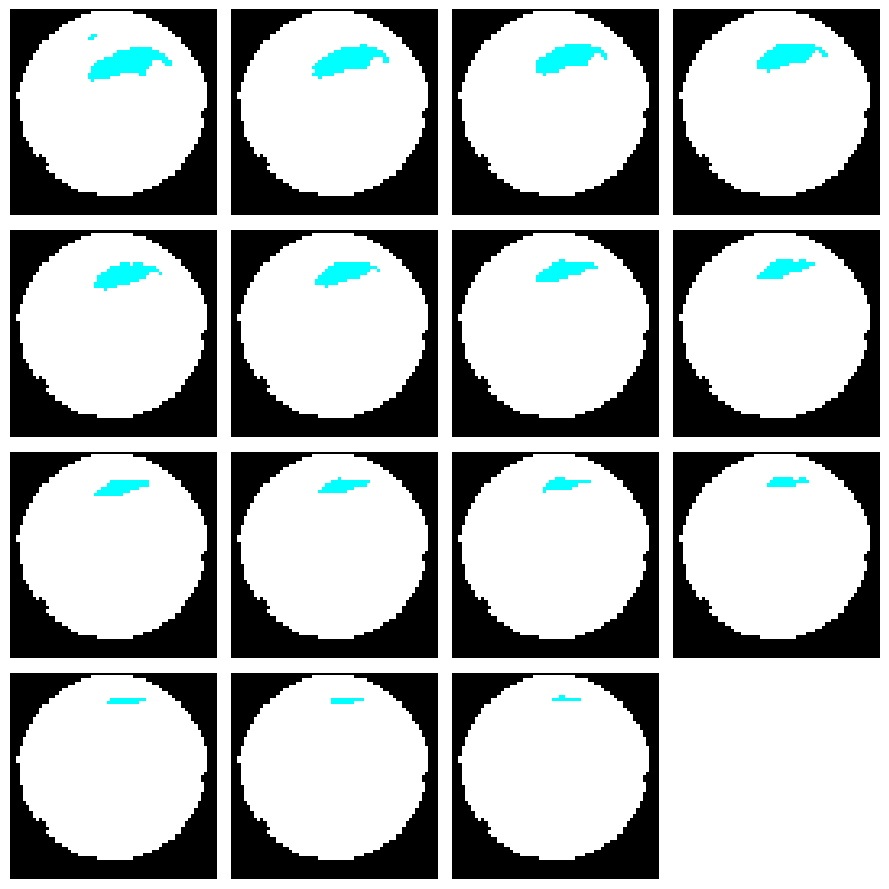

50/559


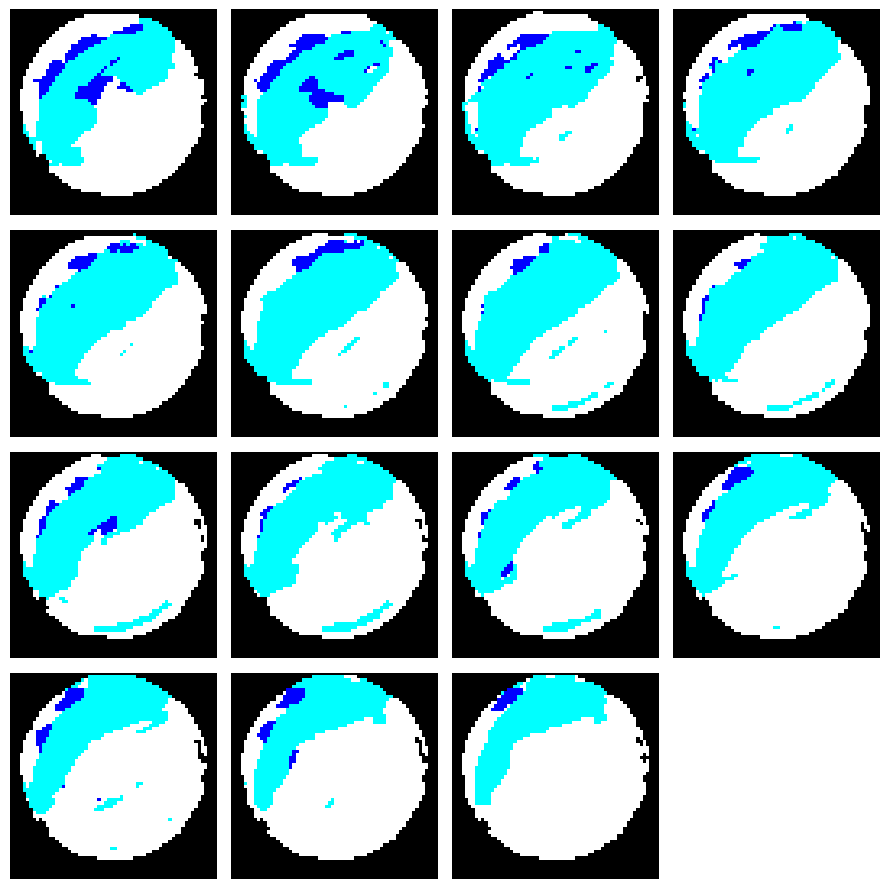

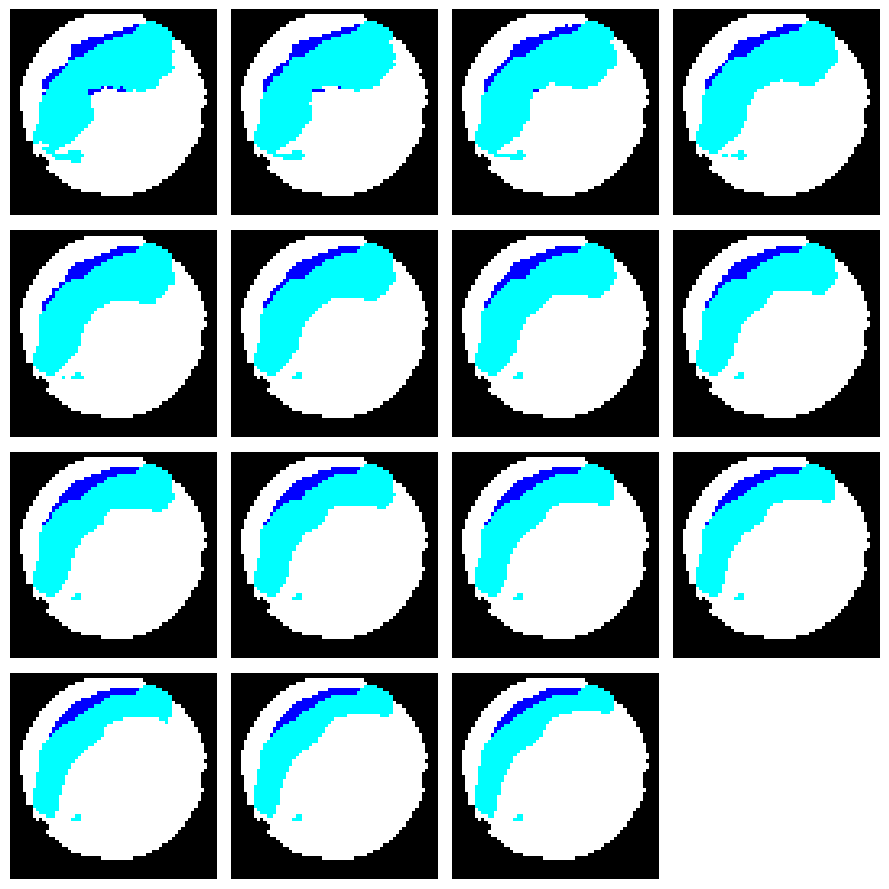

60/559


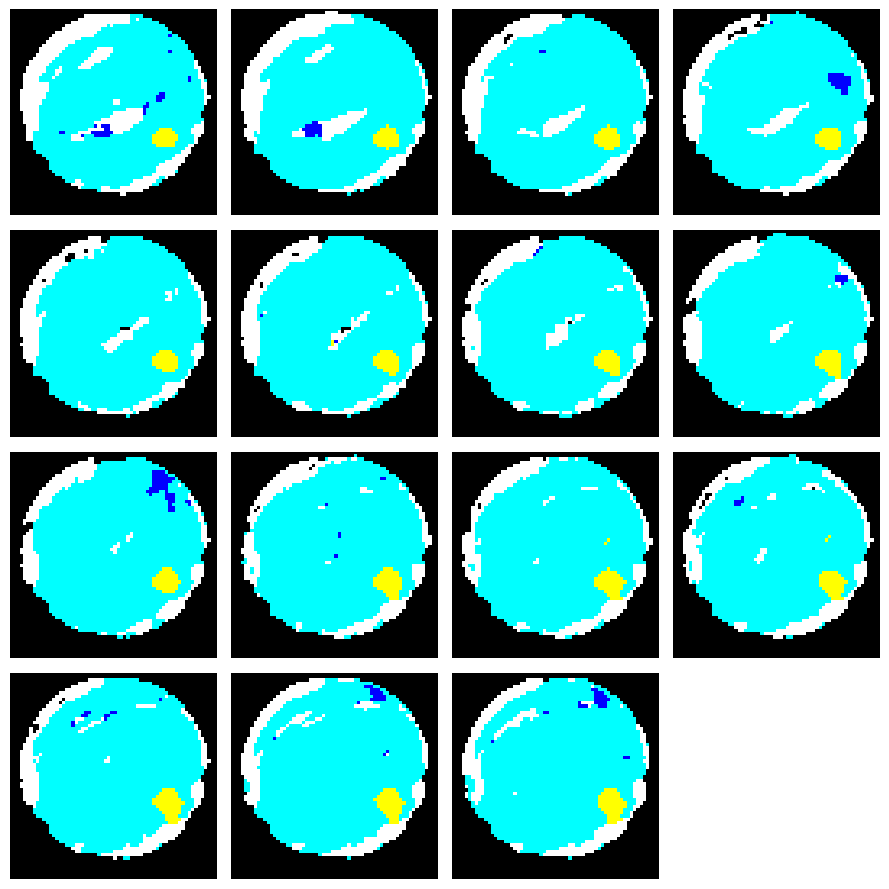

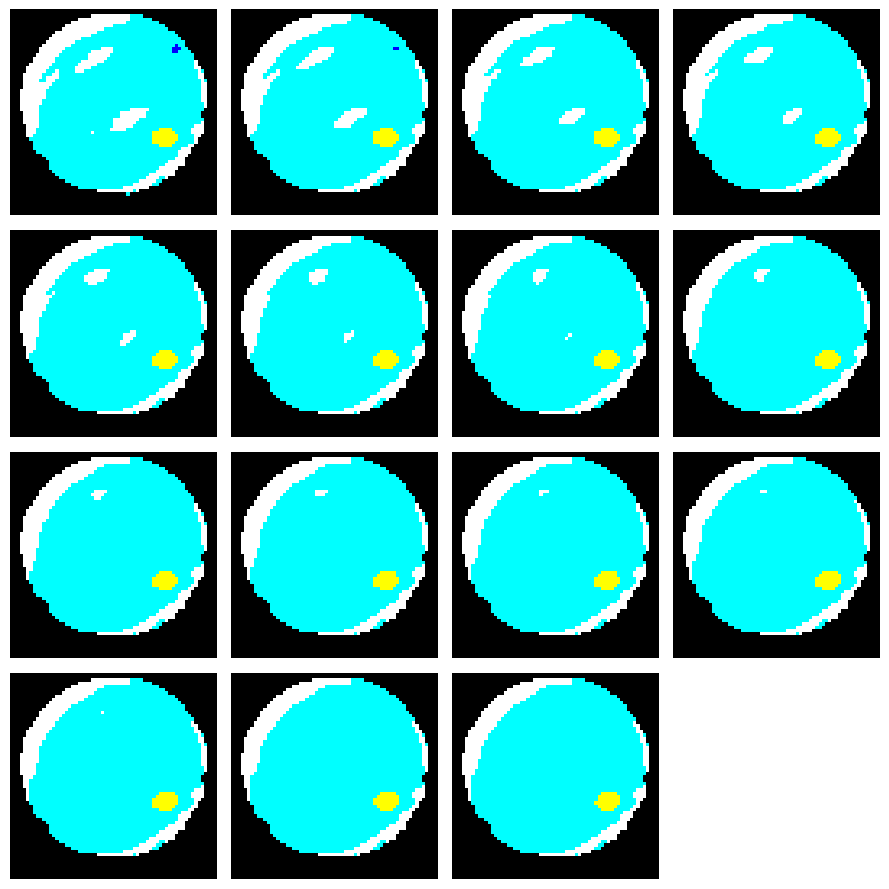

70/559


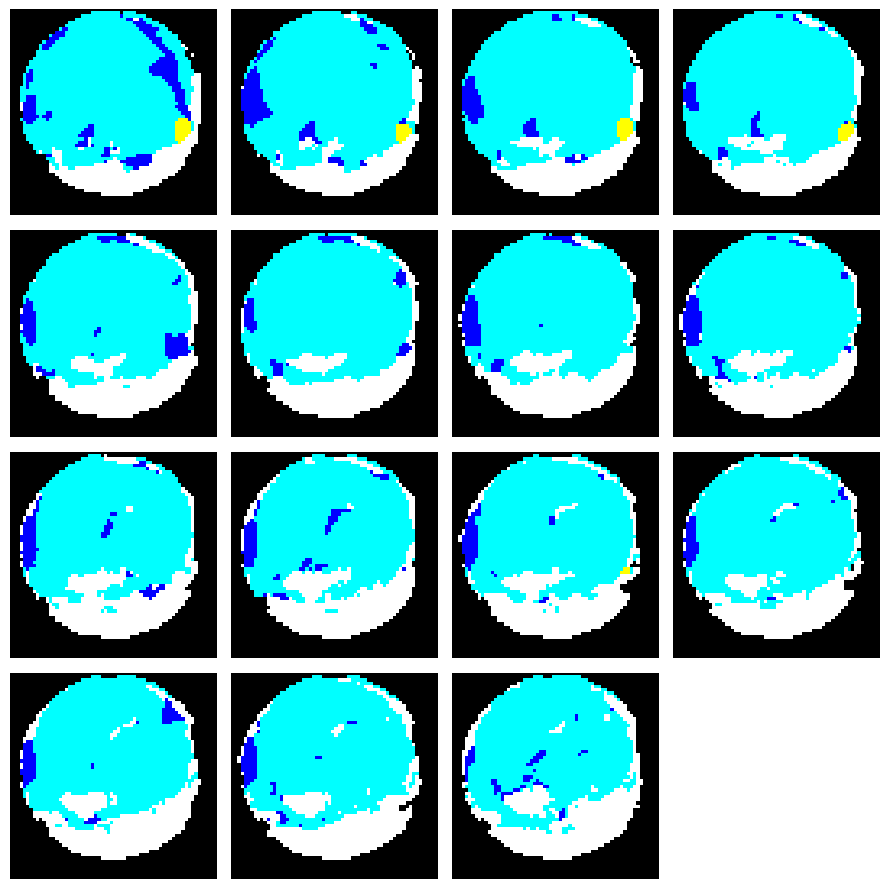

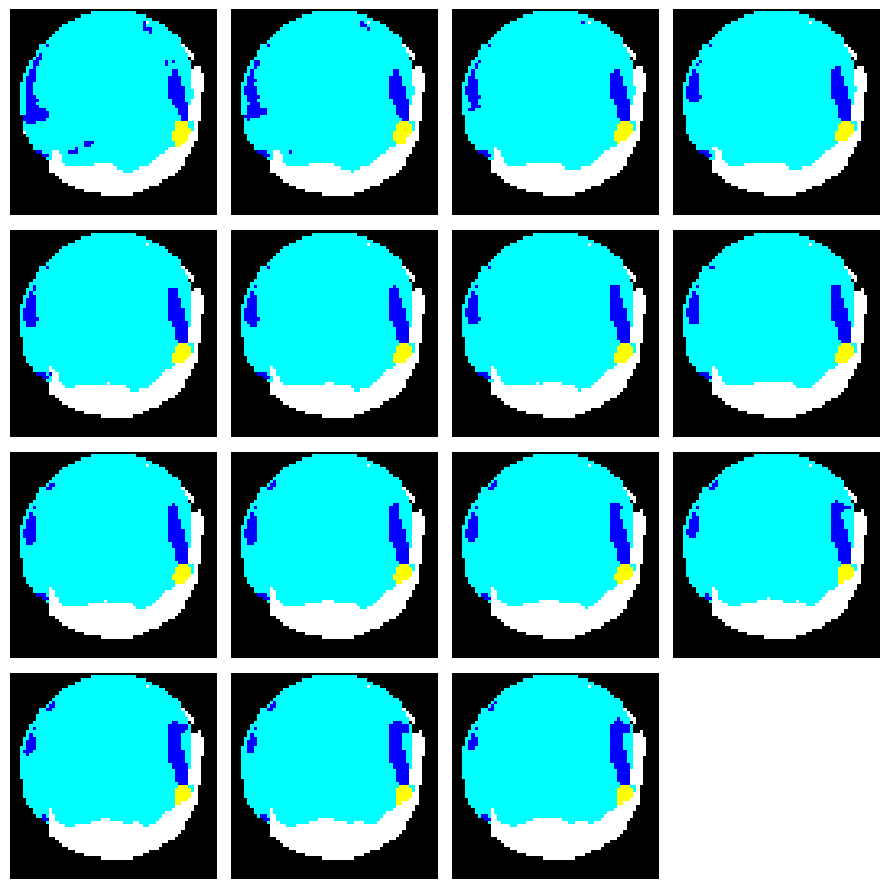

80/559


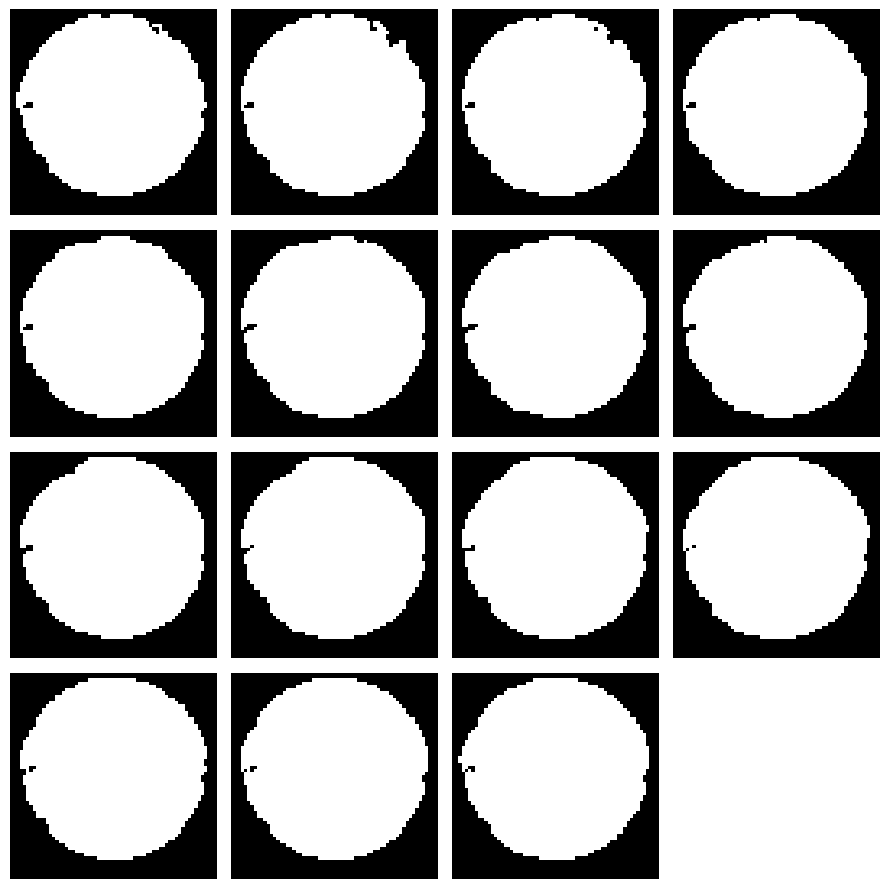

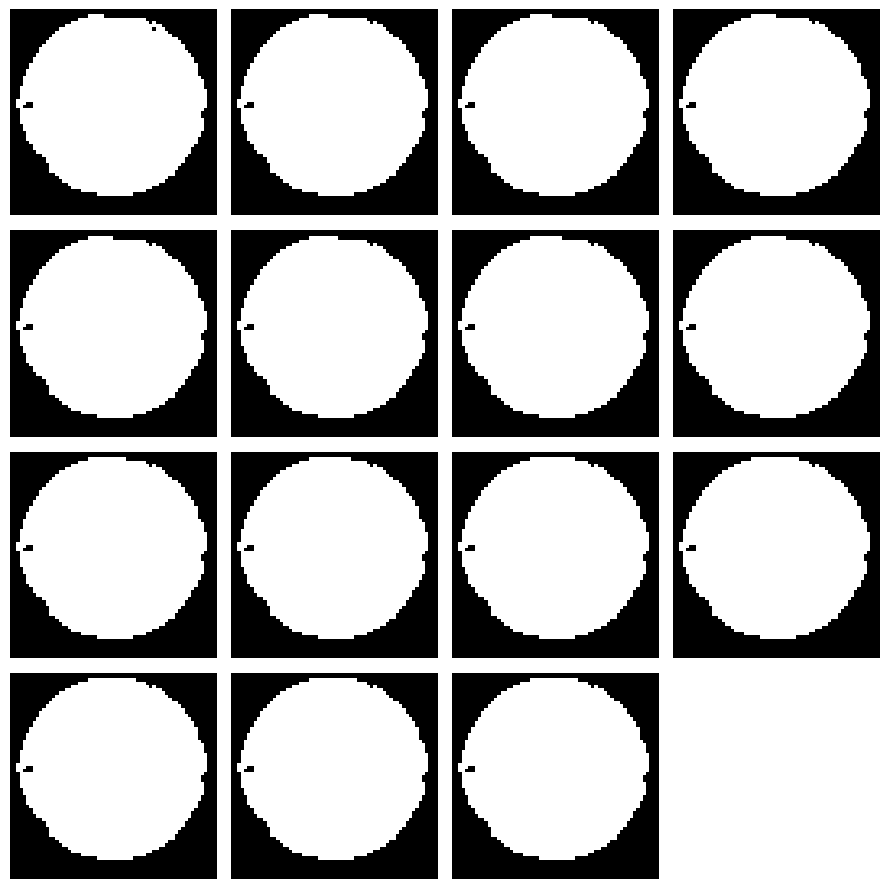

90/559


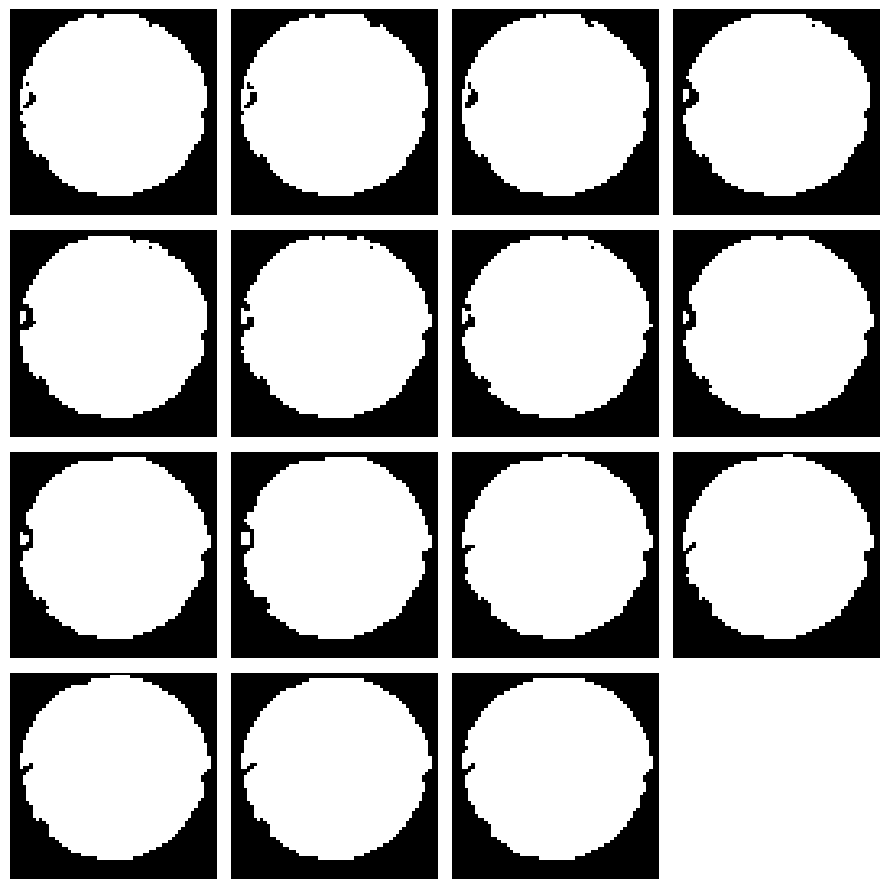

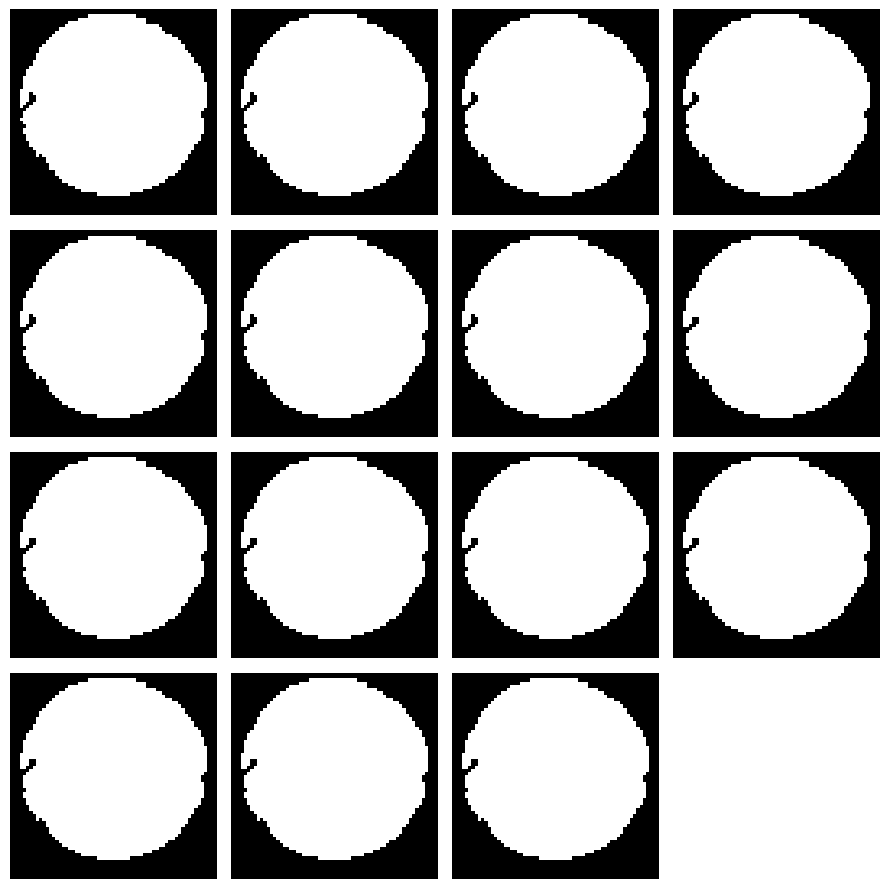

100/559


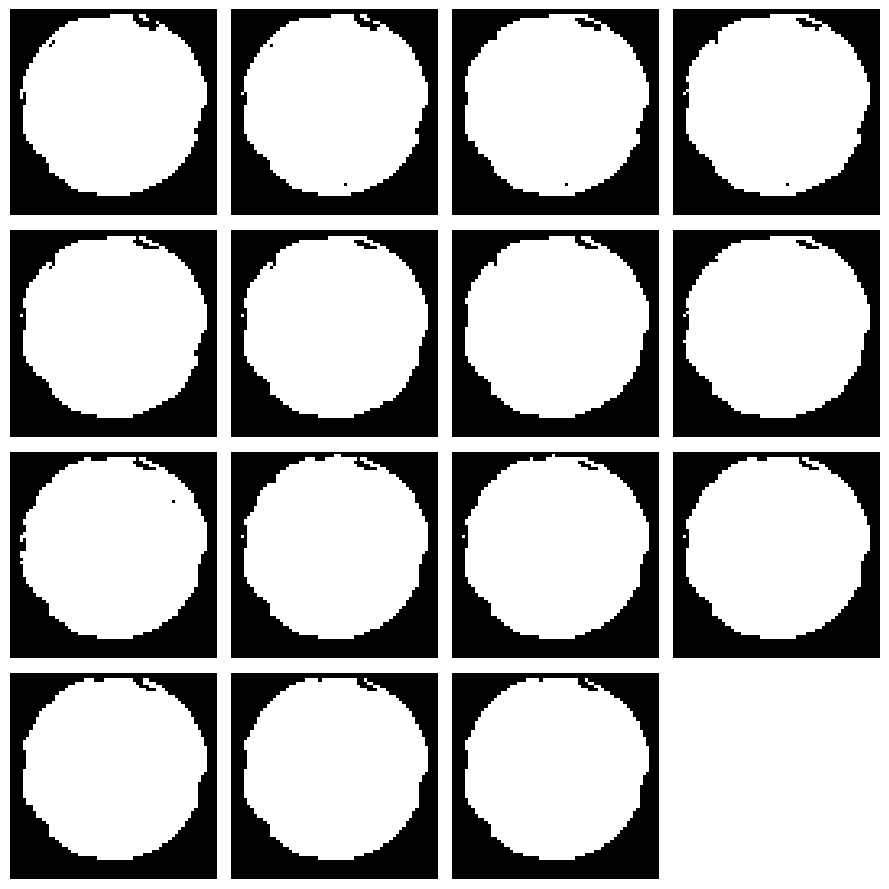

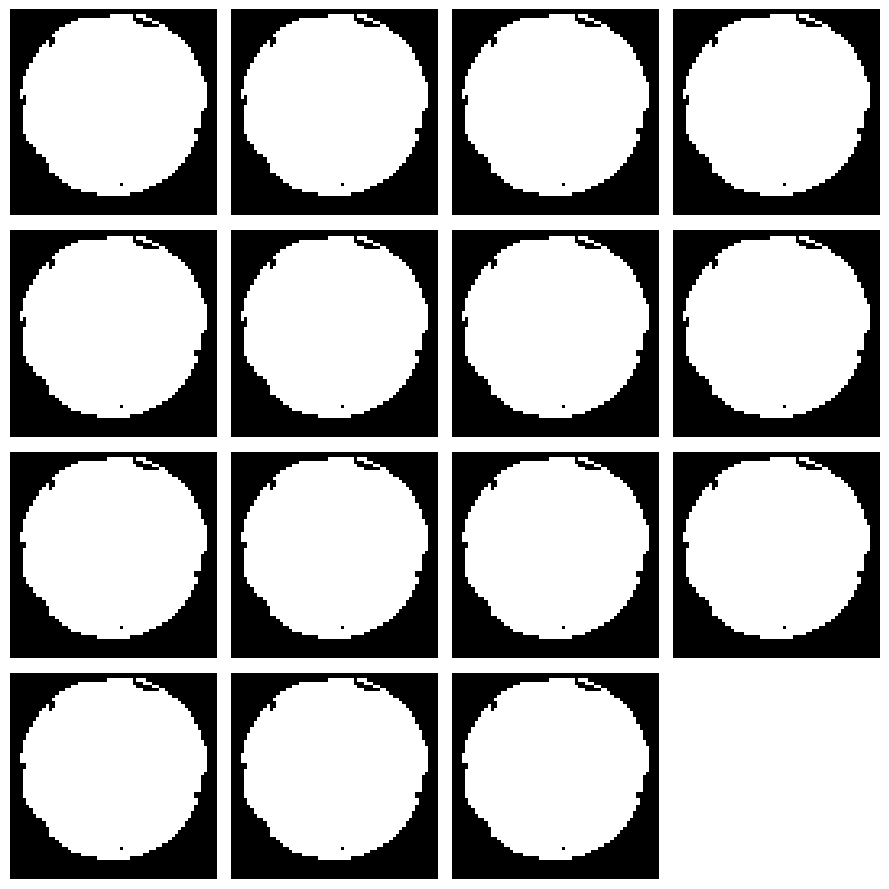

110/559


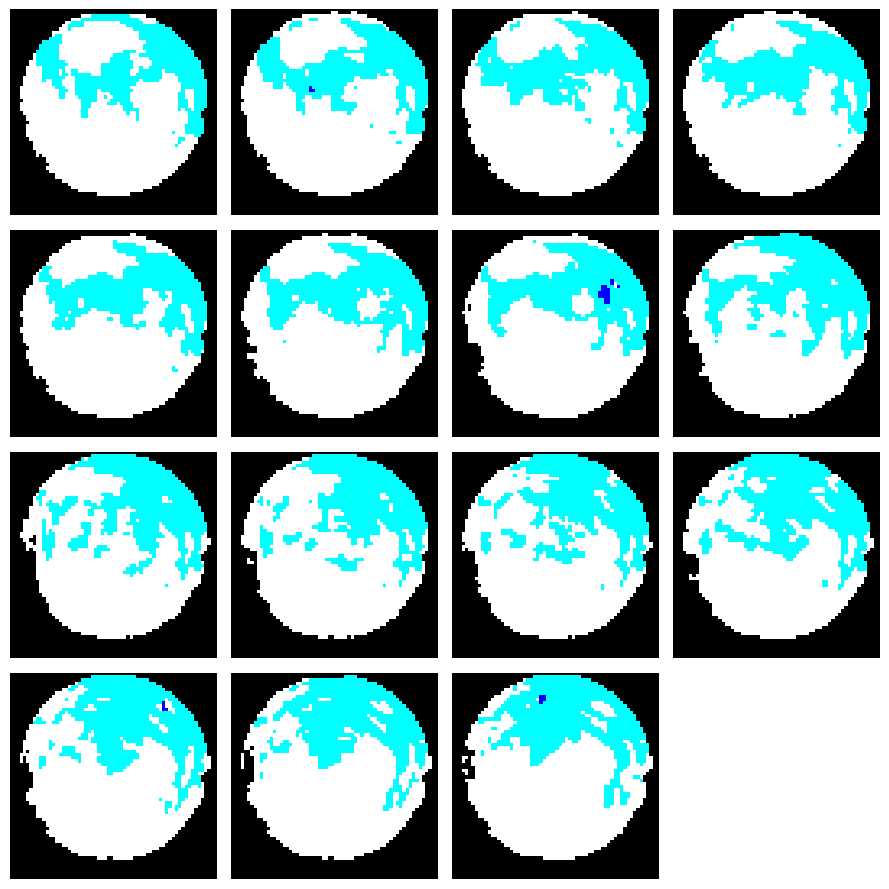

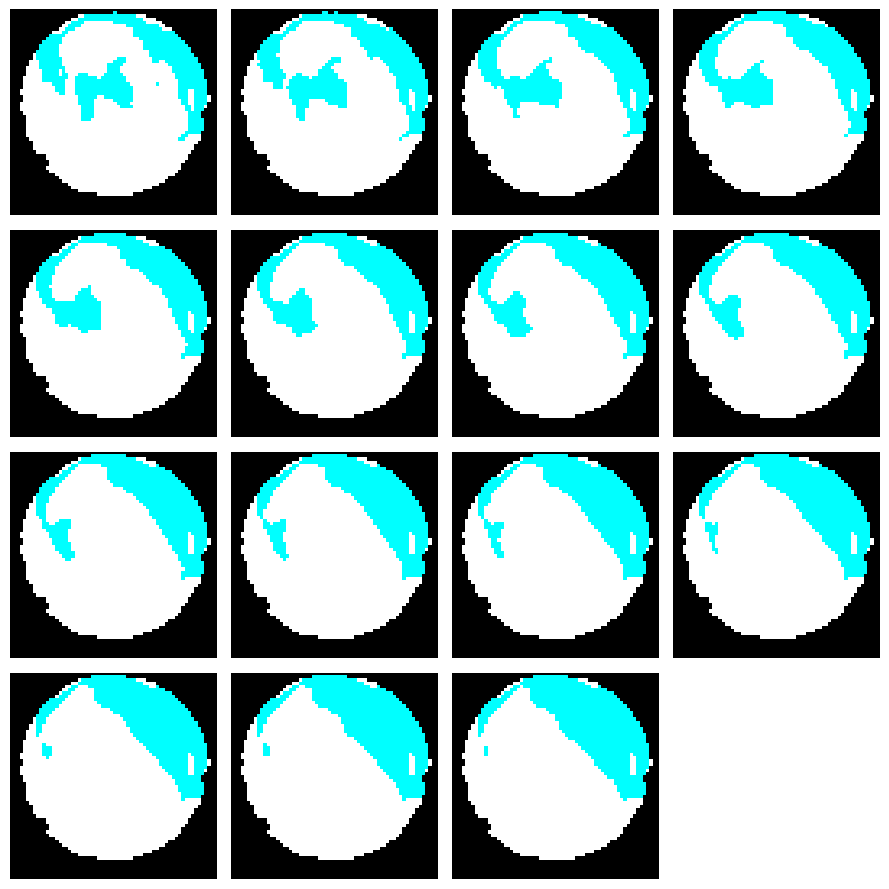

120/559


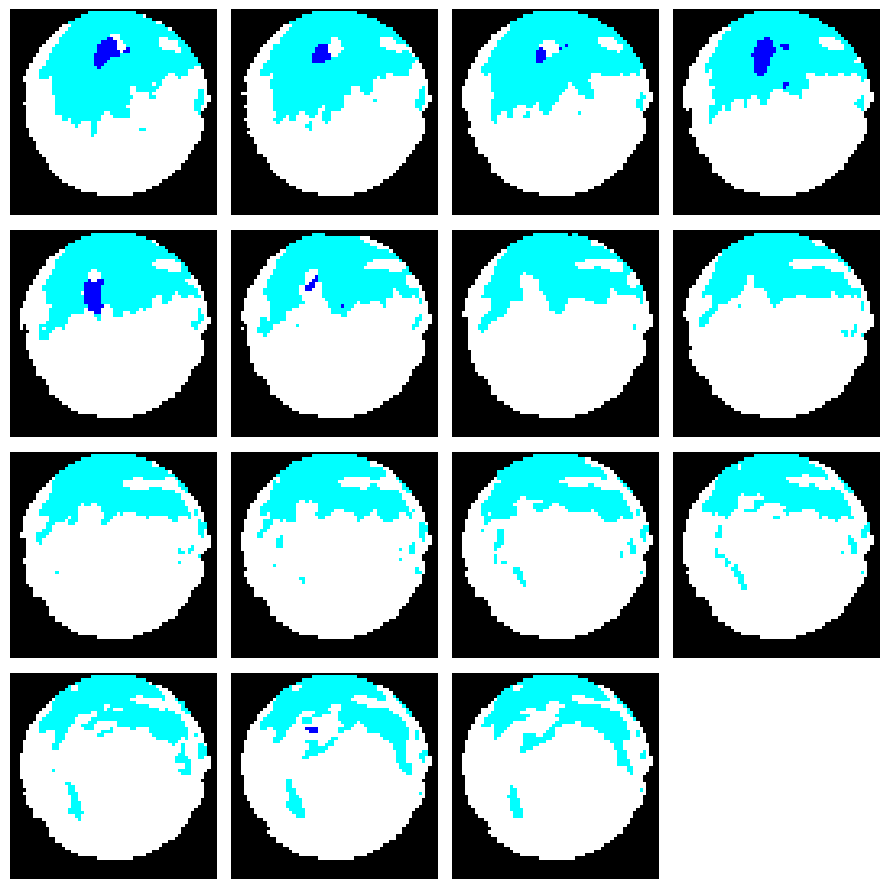

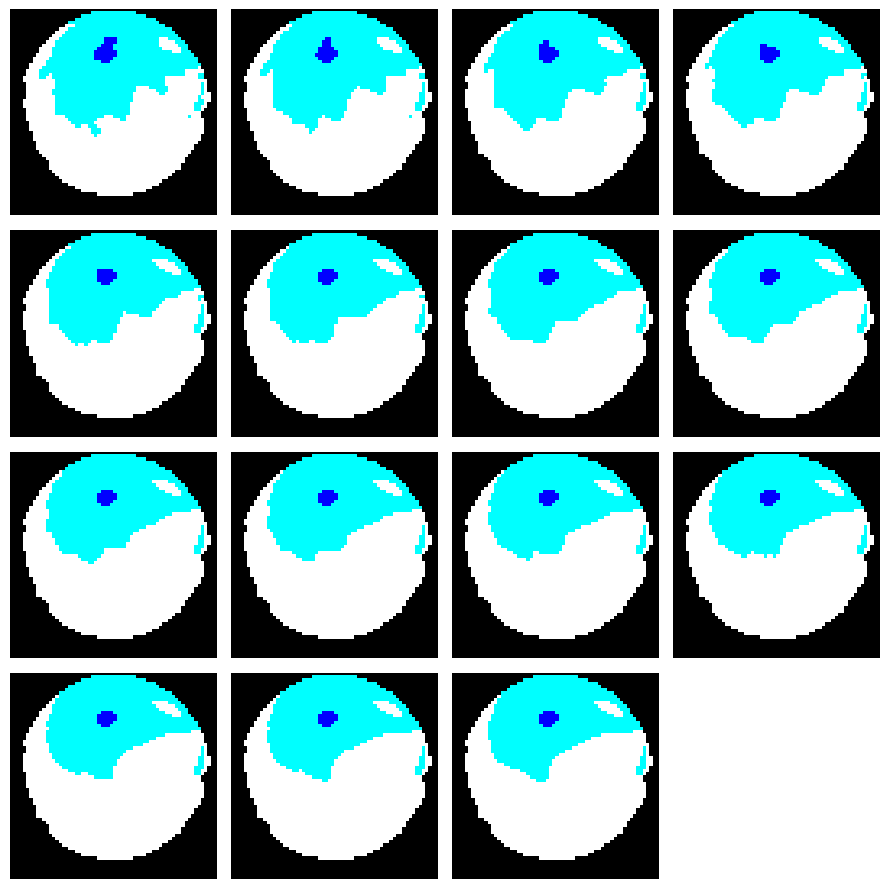

130/559


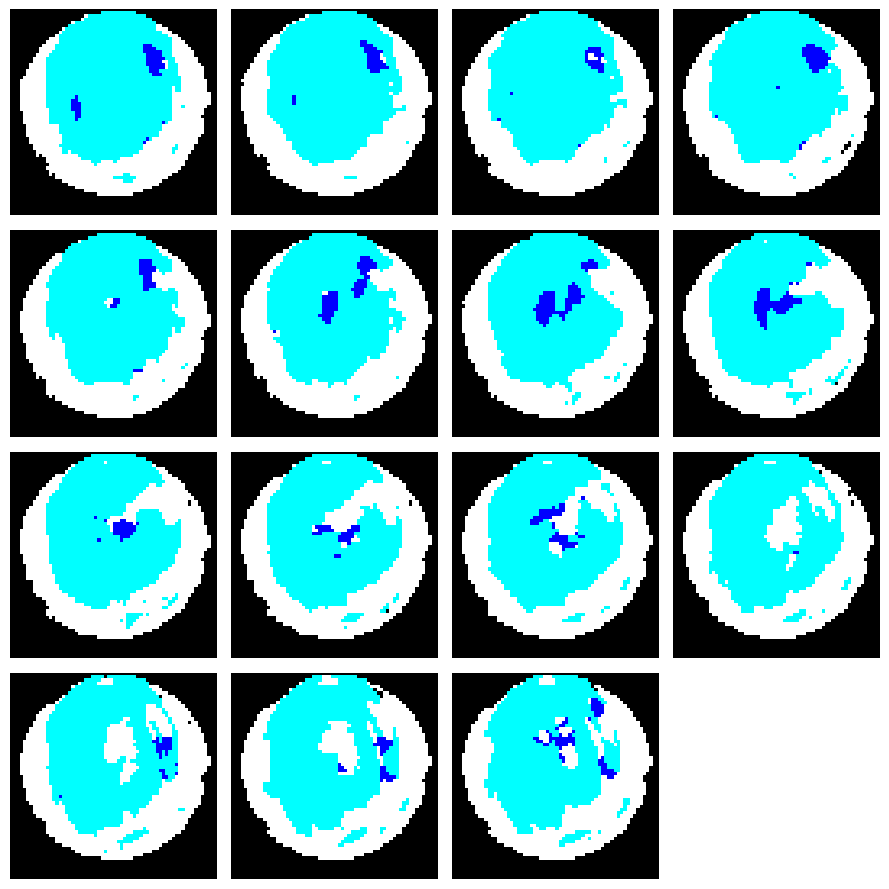

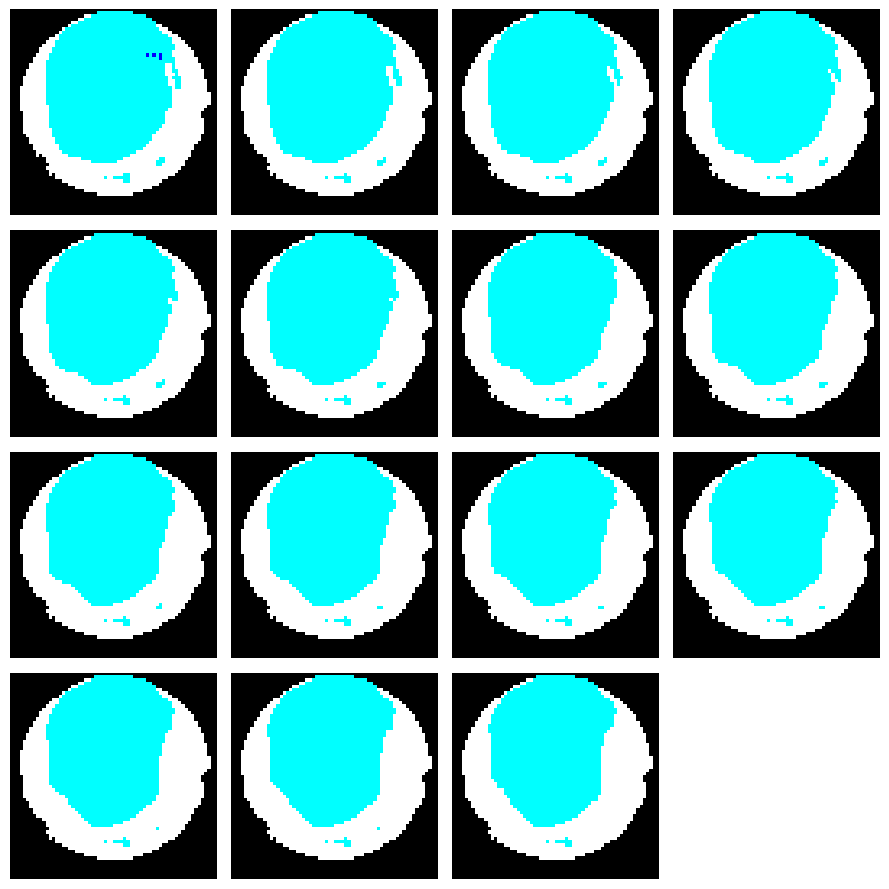

140/559


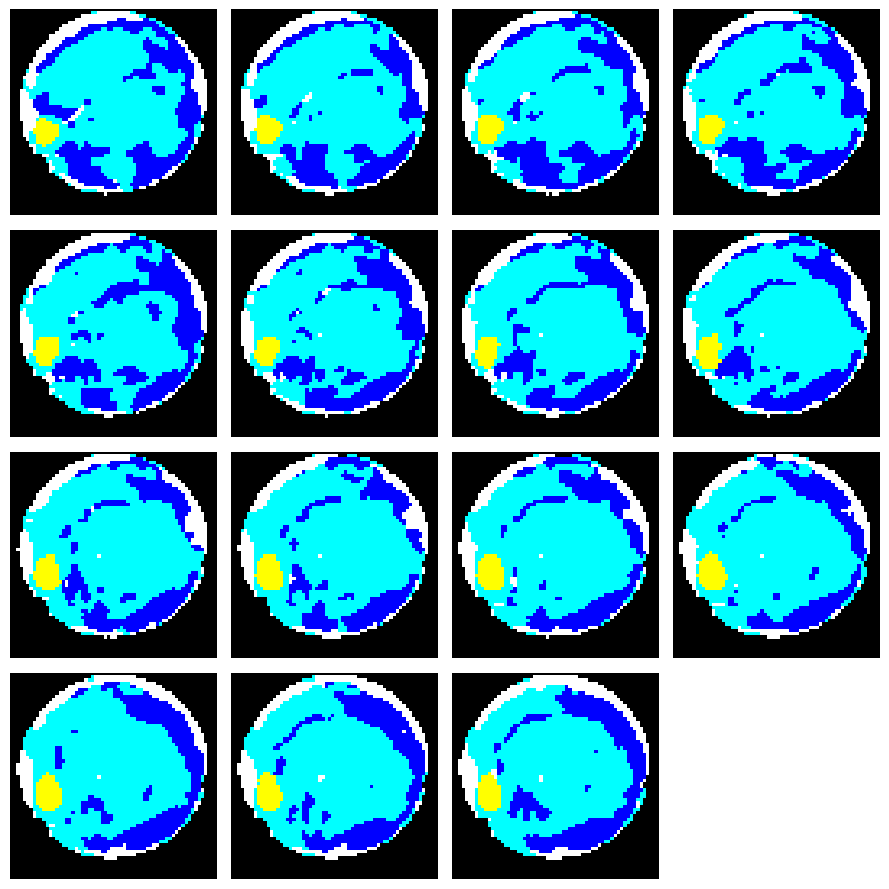

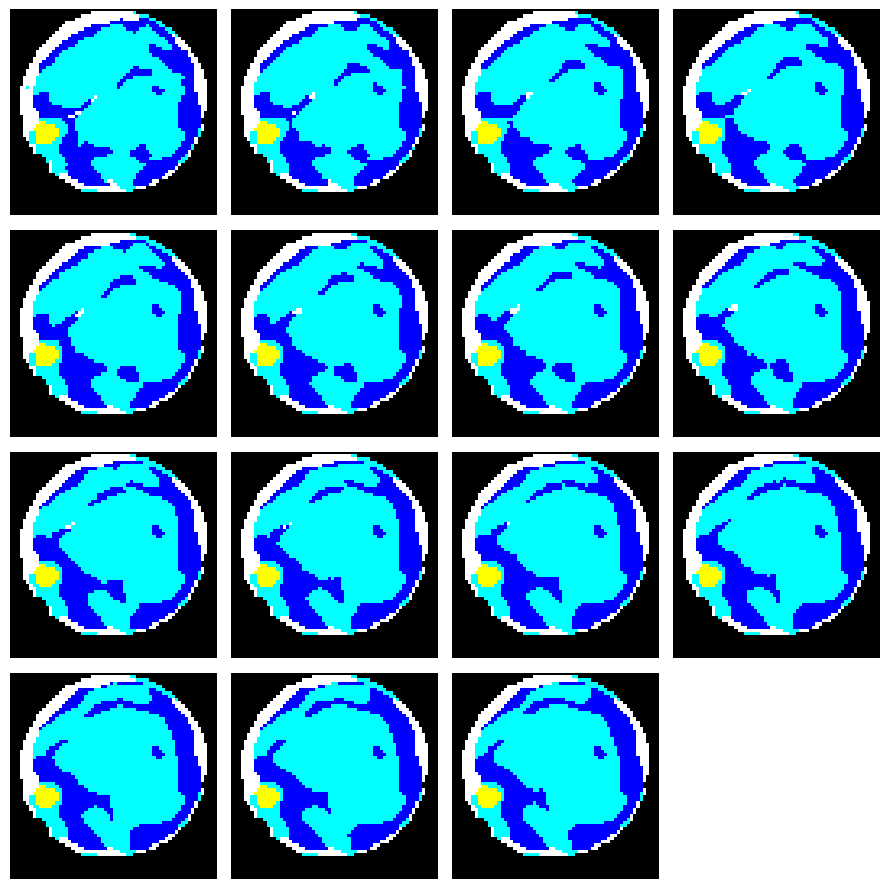

150/559


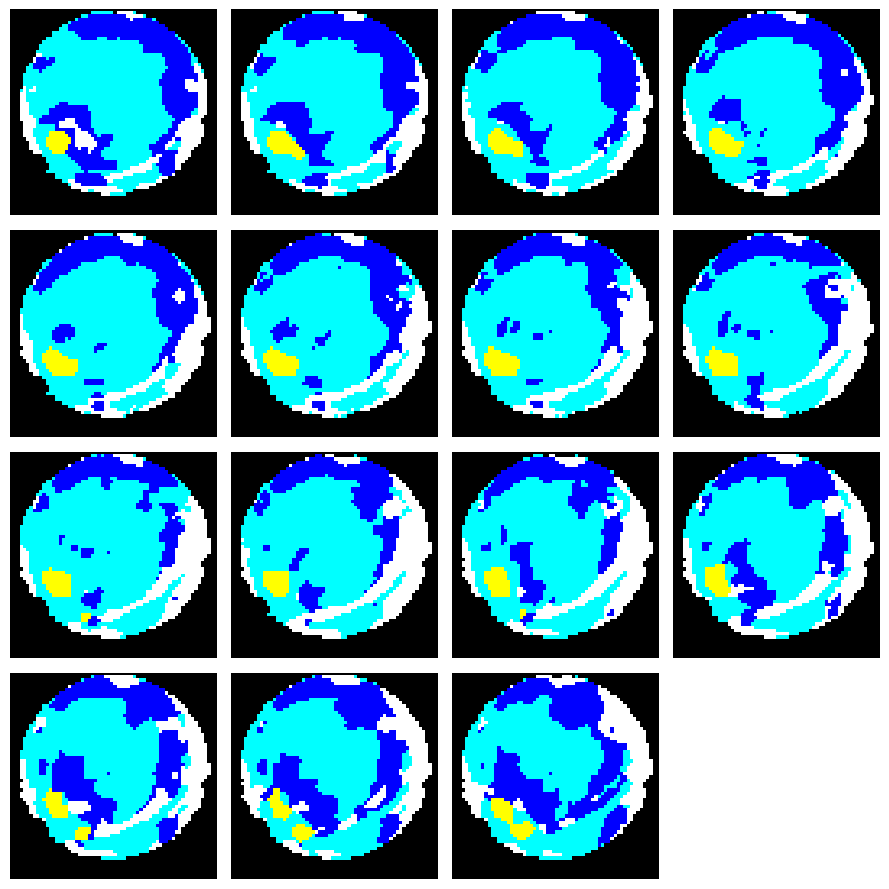

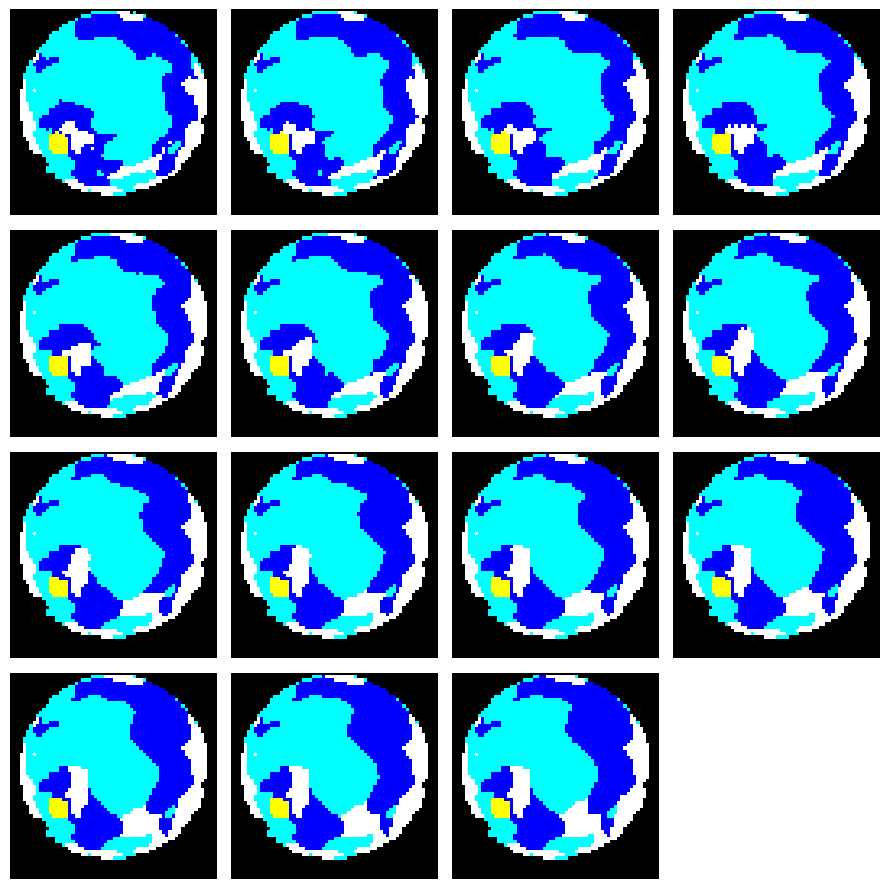

160/559


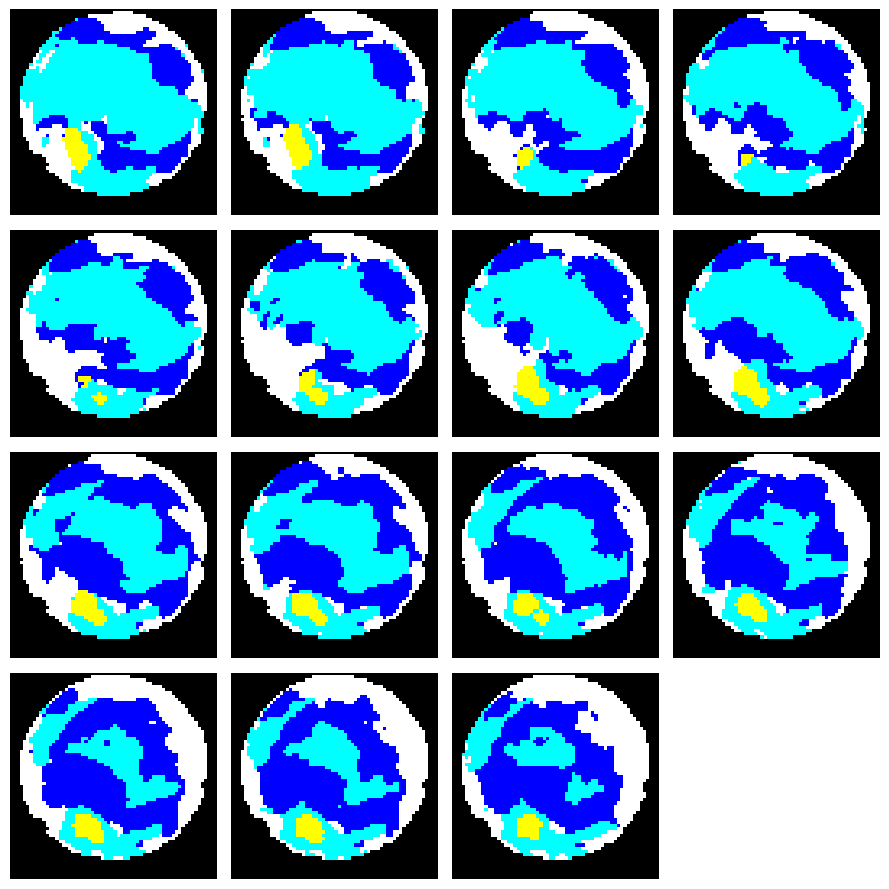

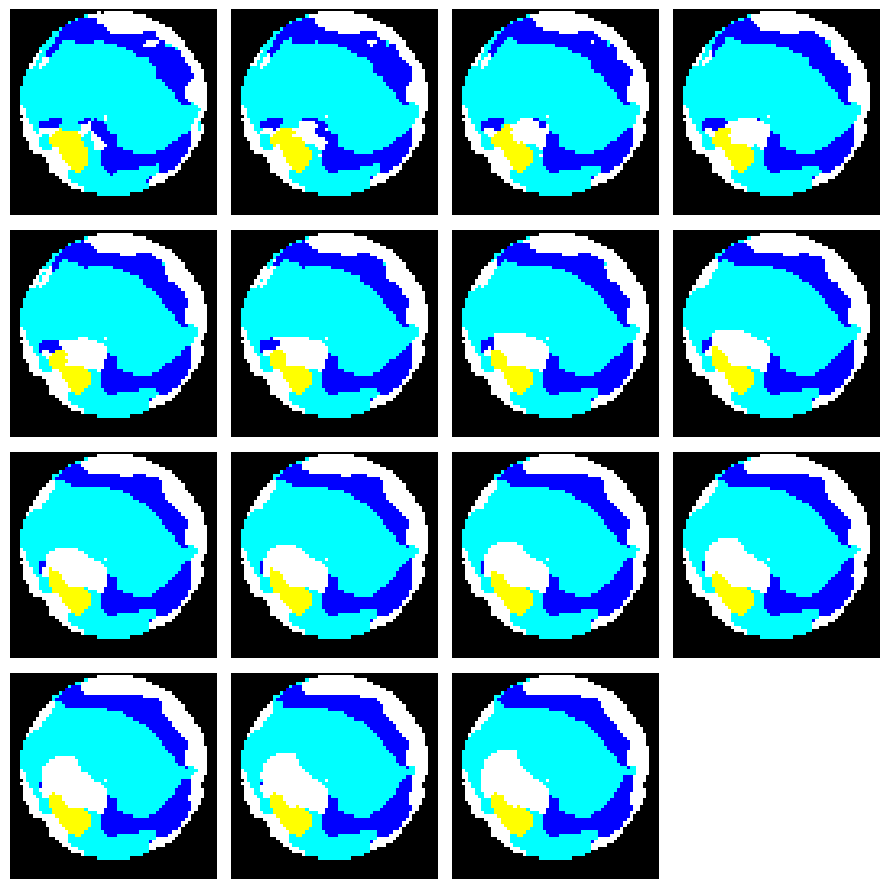

170/559


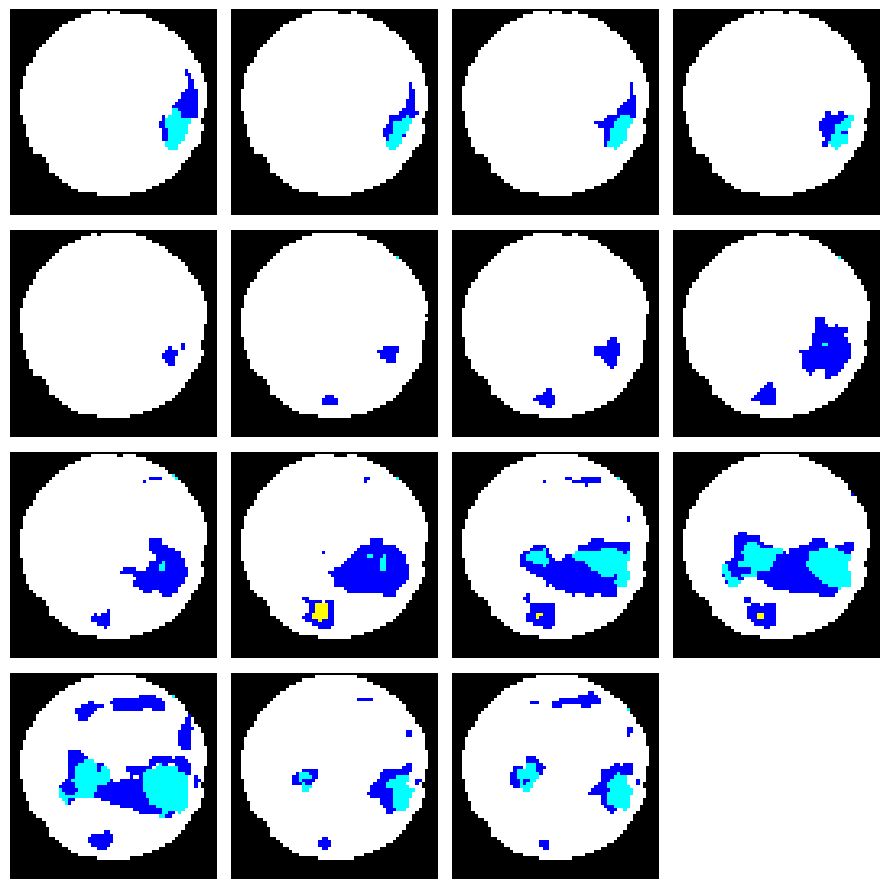

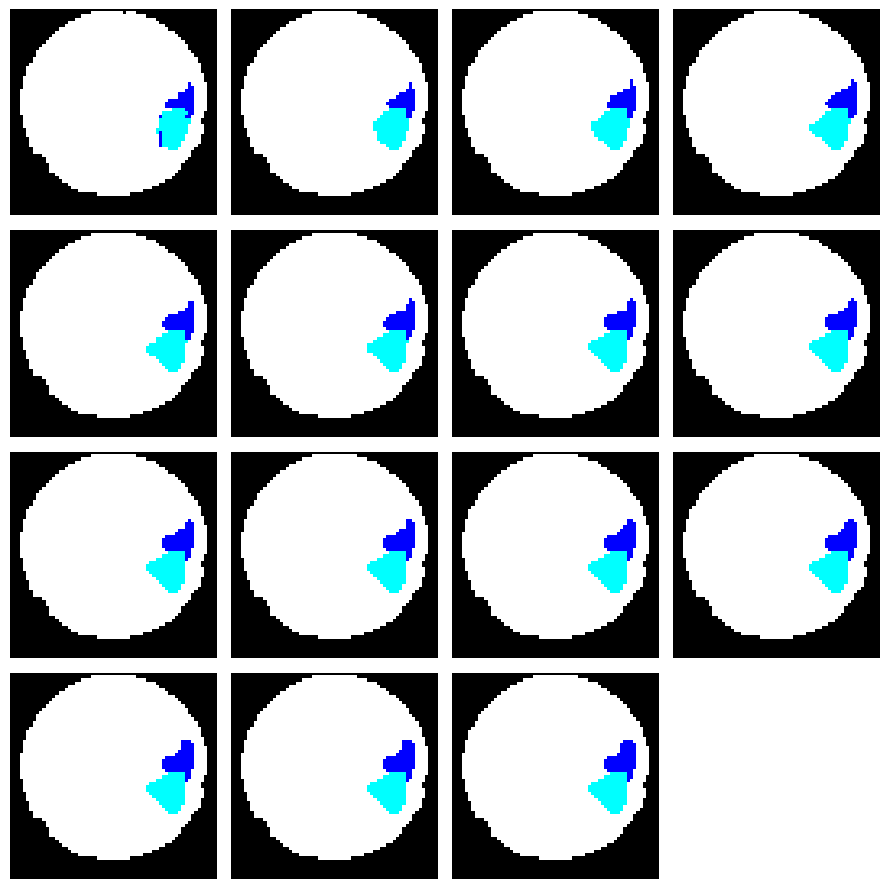

180/559


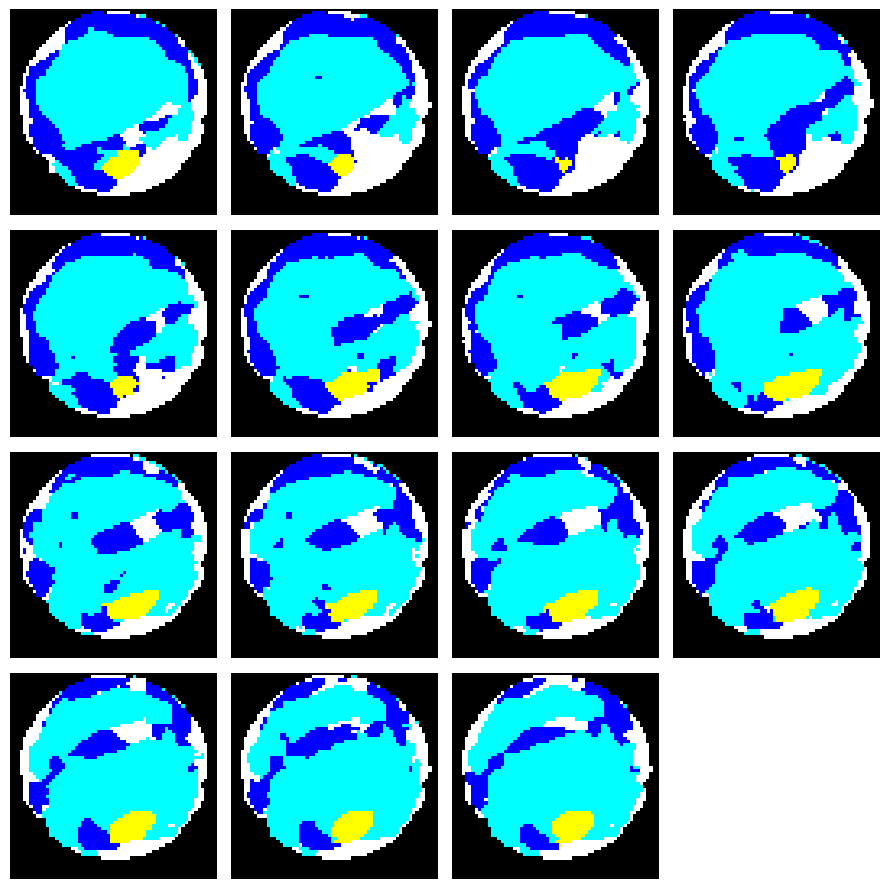

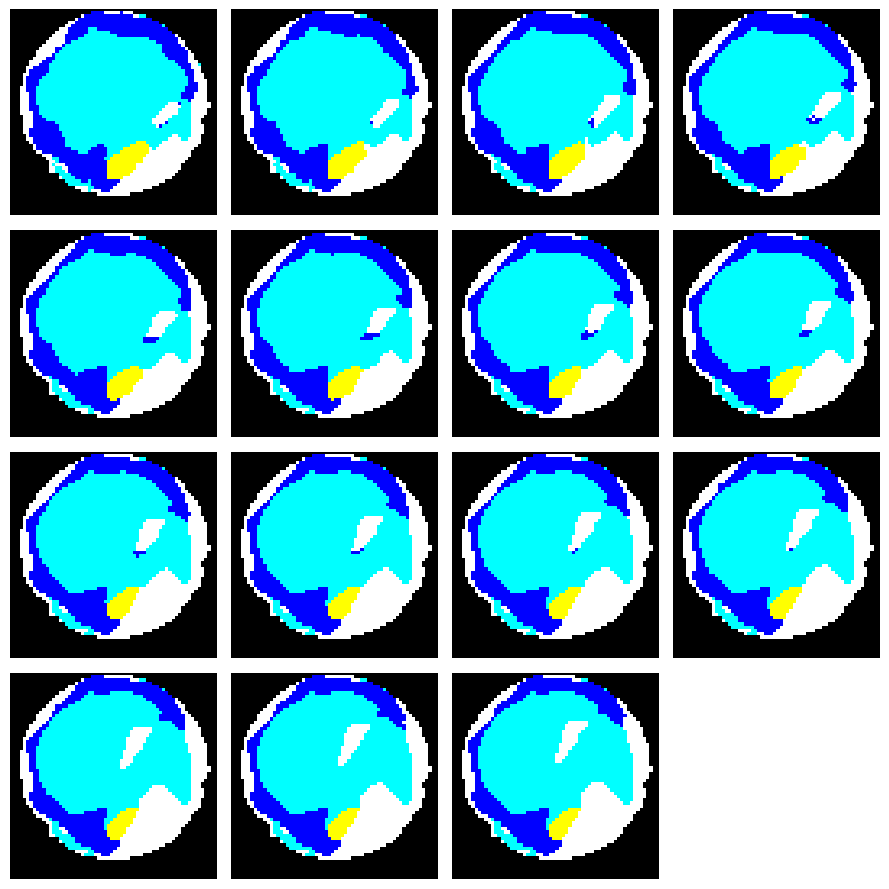

190/559


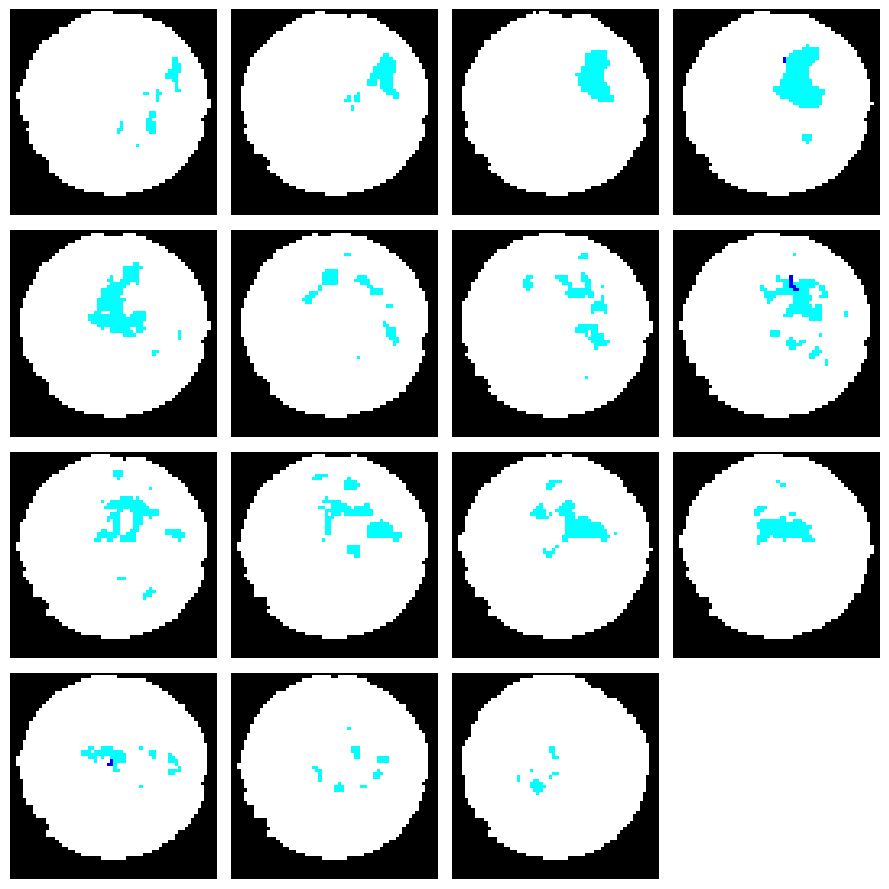

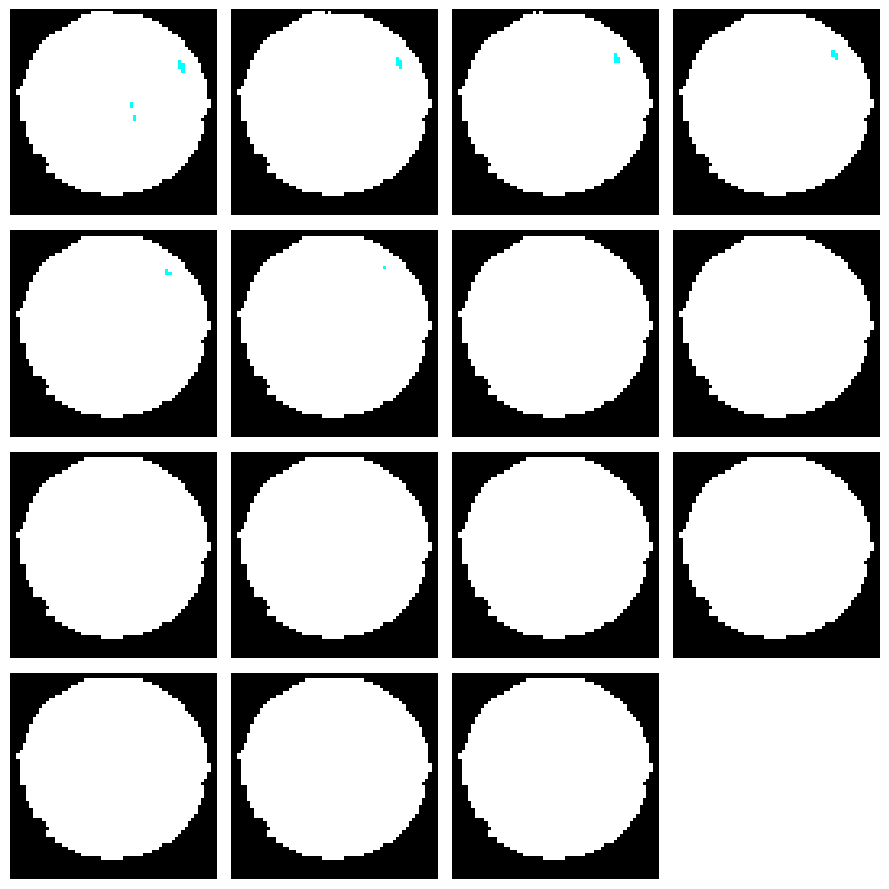

200/559


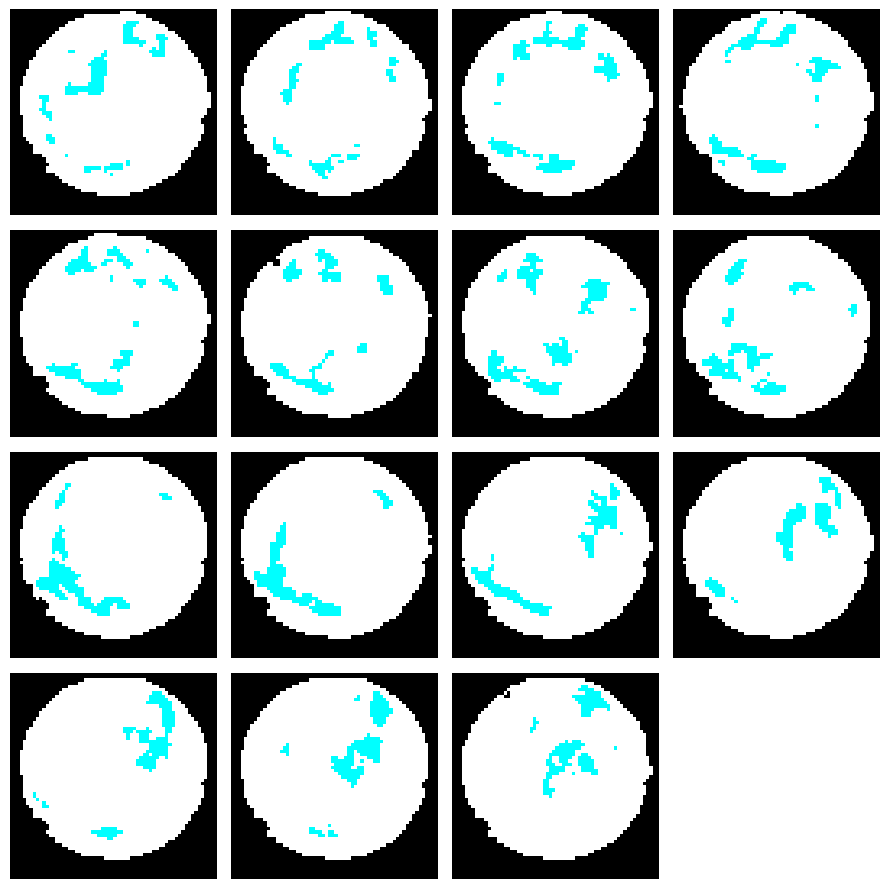

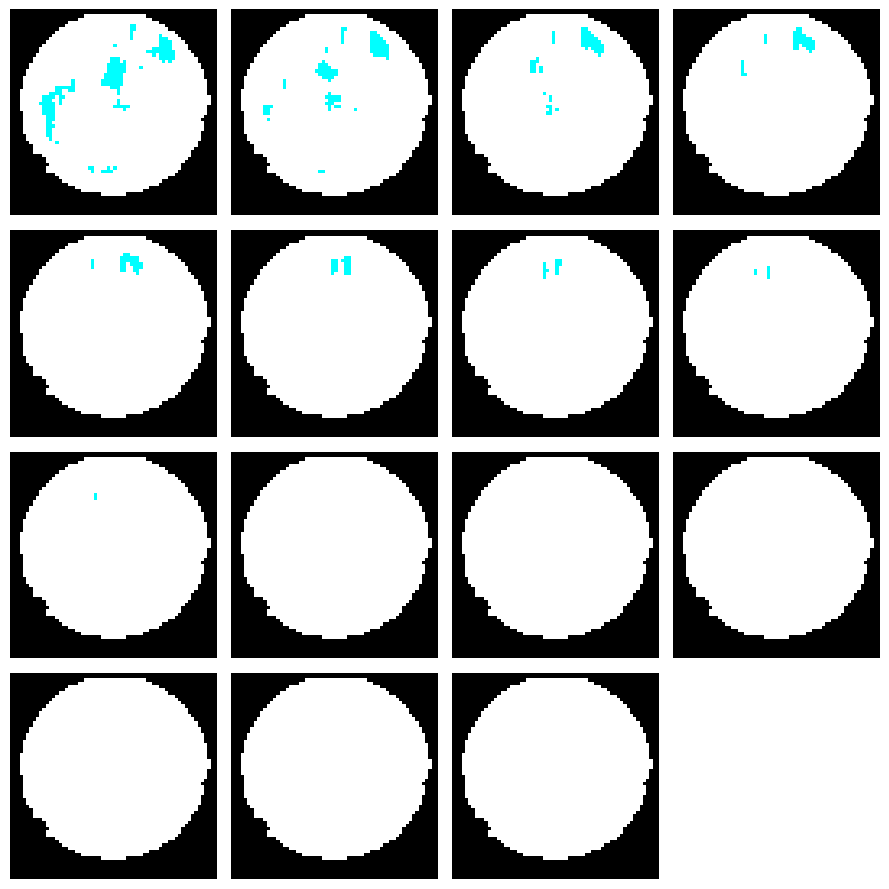

210/559


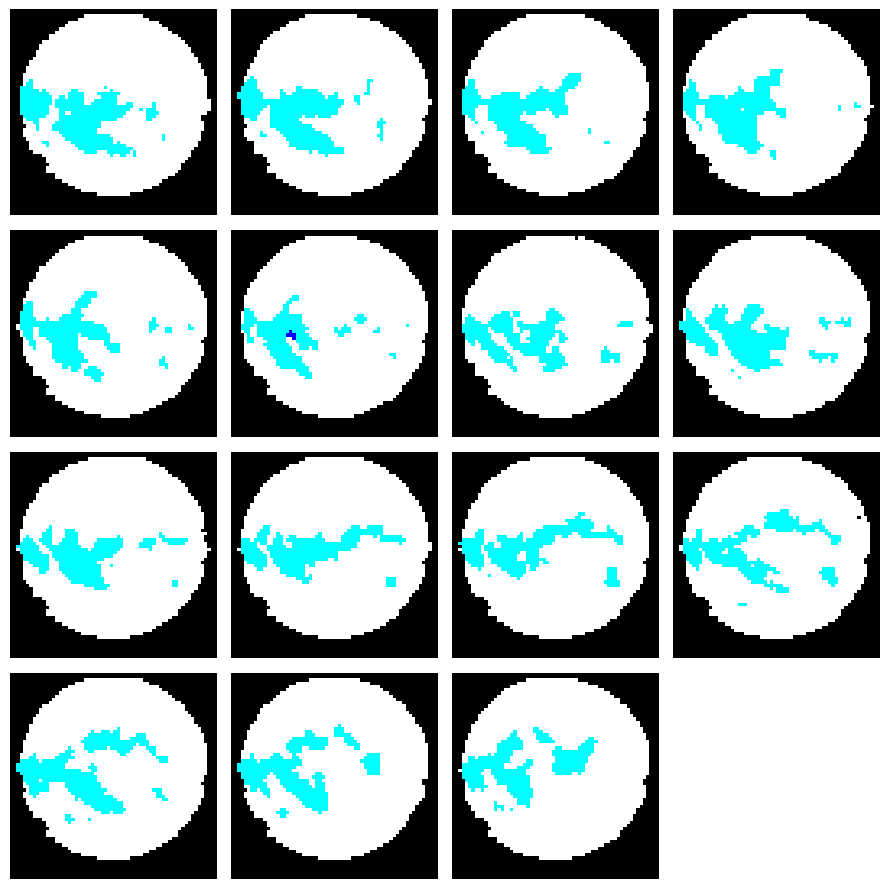

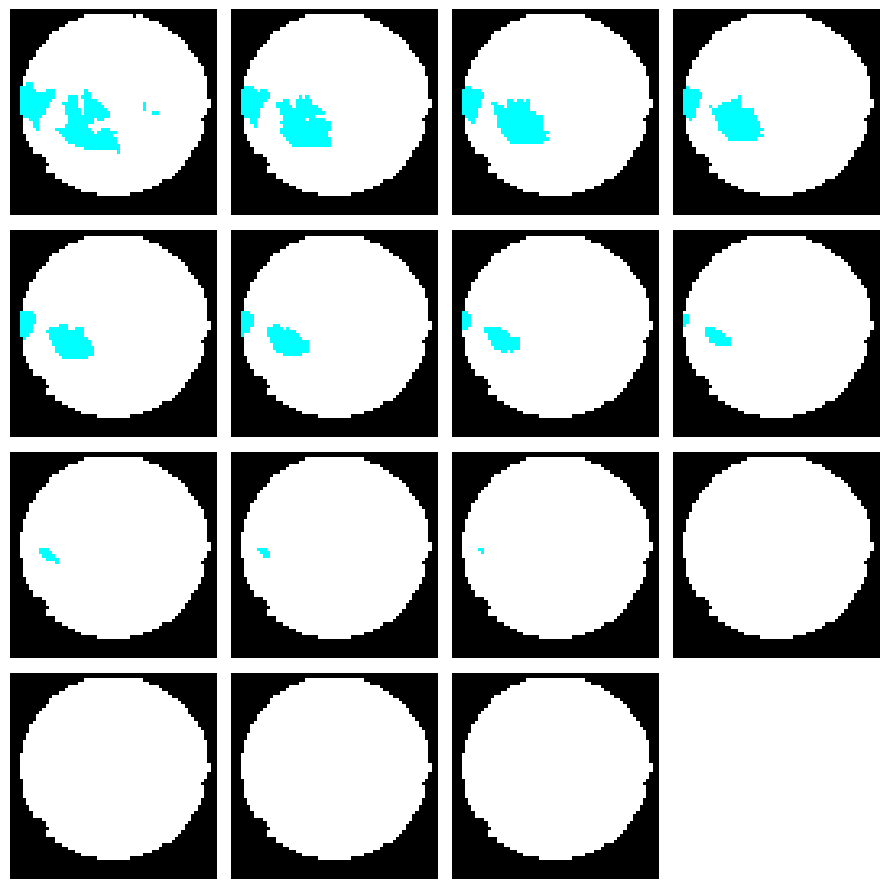

220/559


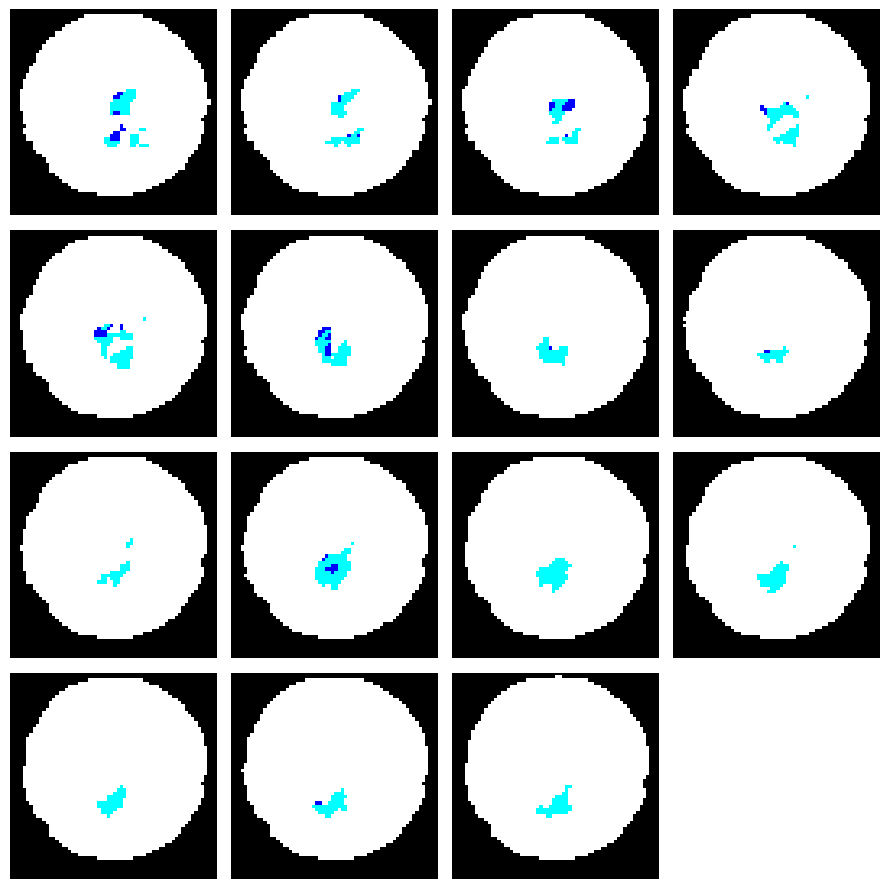

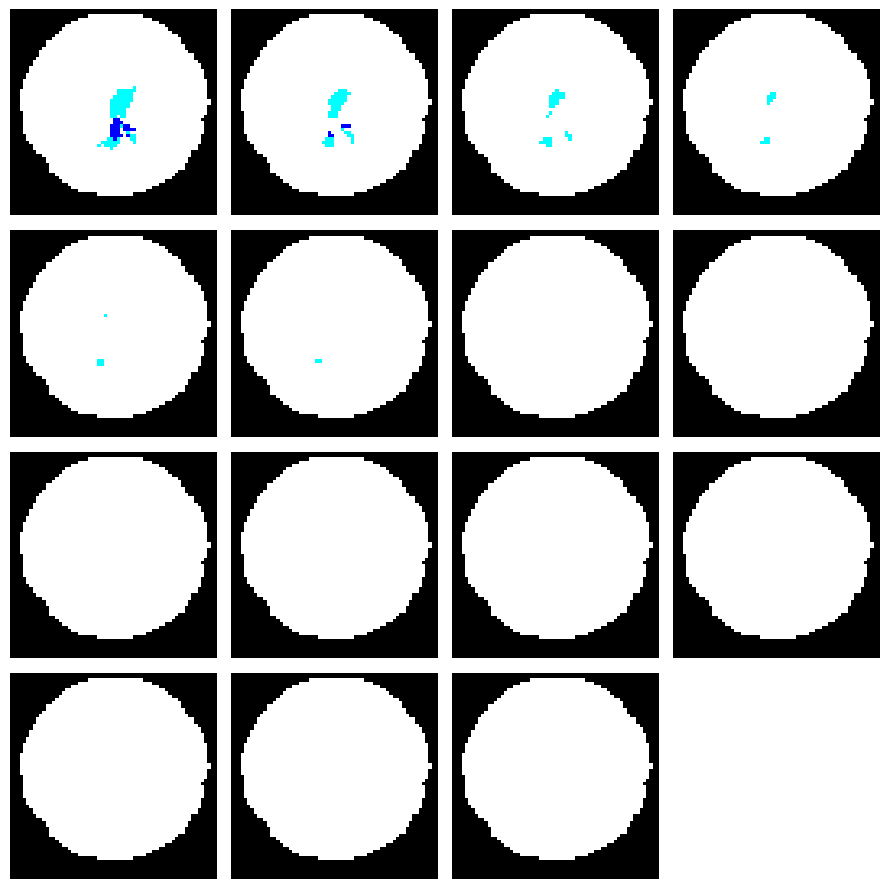

230/559


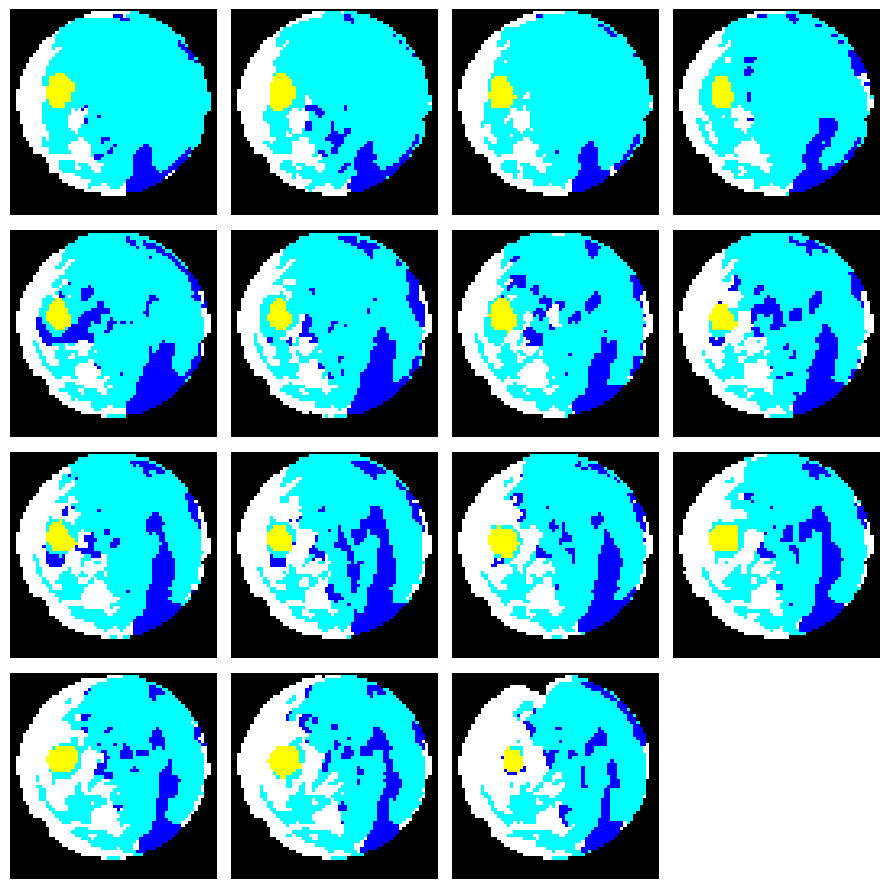

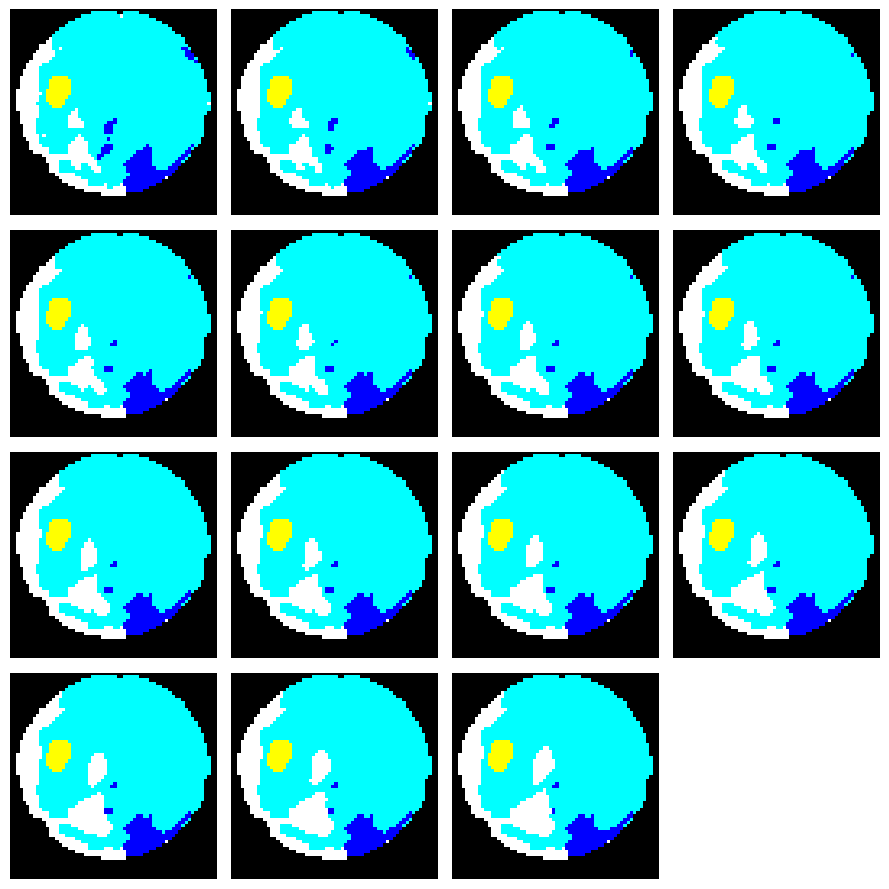

240/559


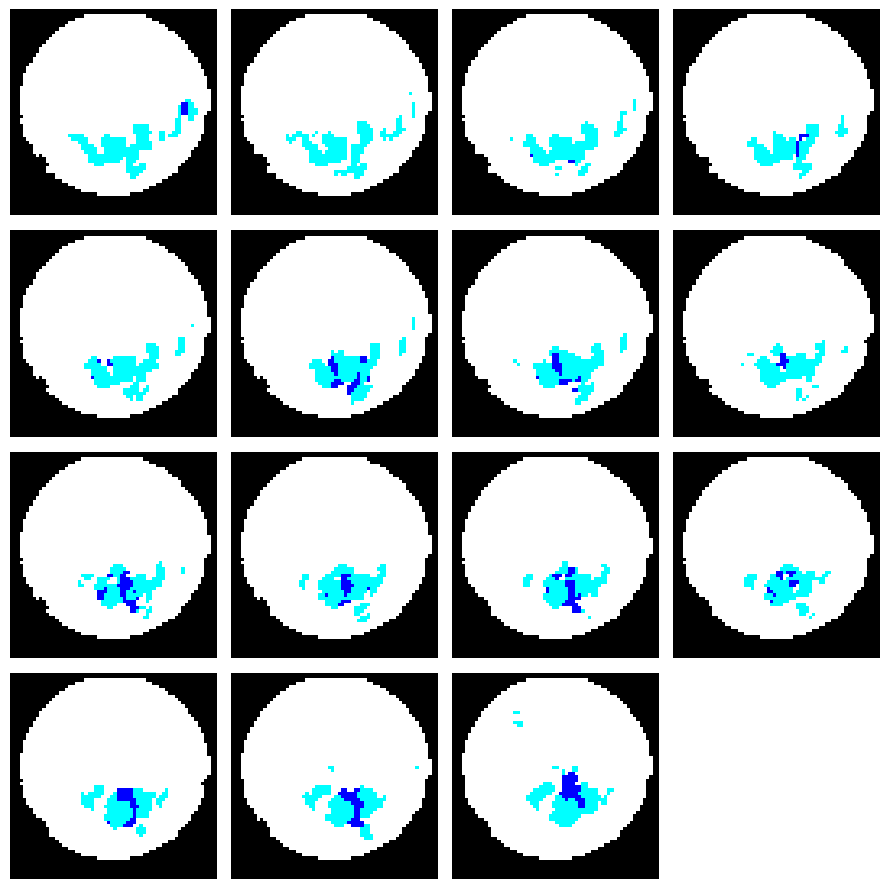

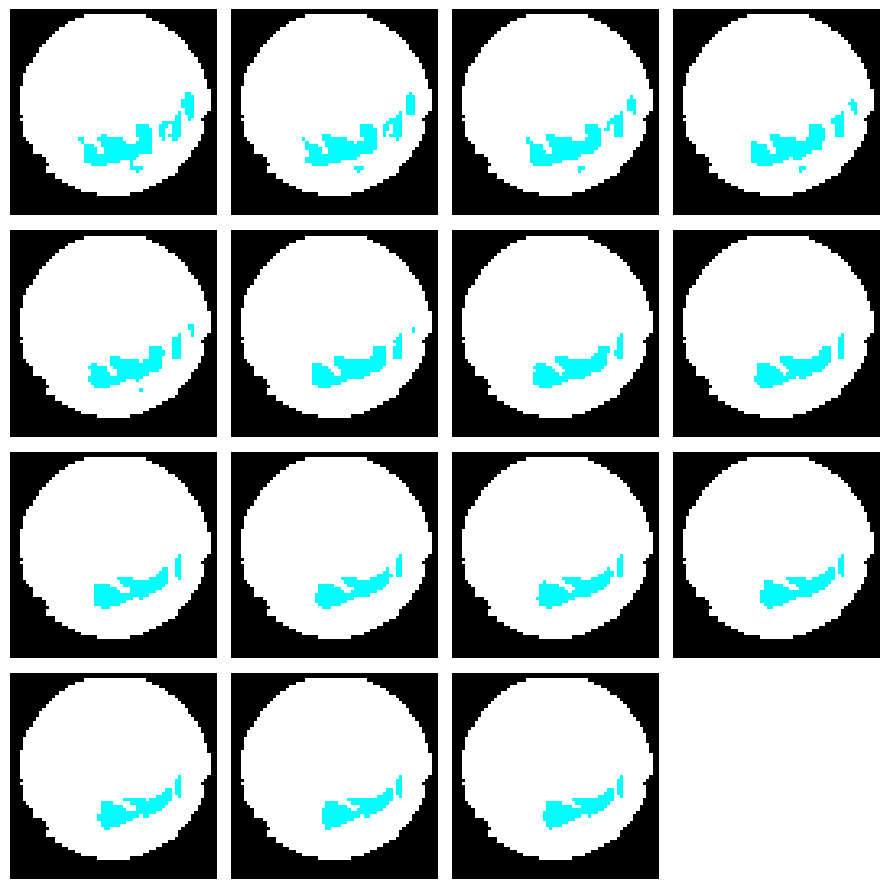

250/559


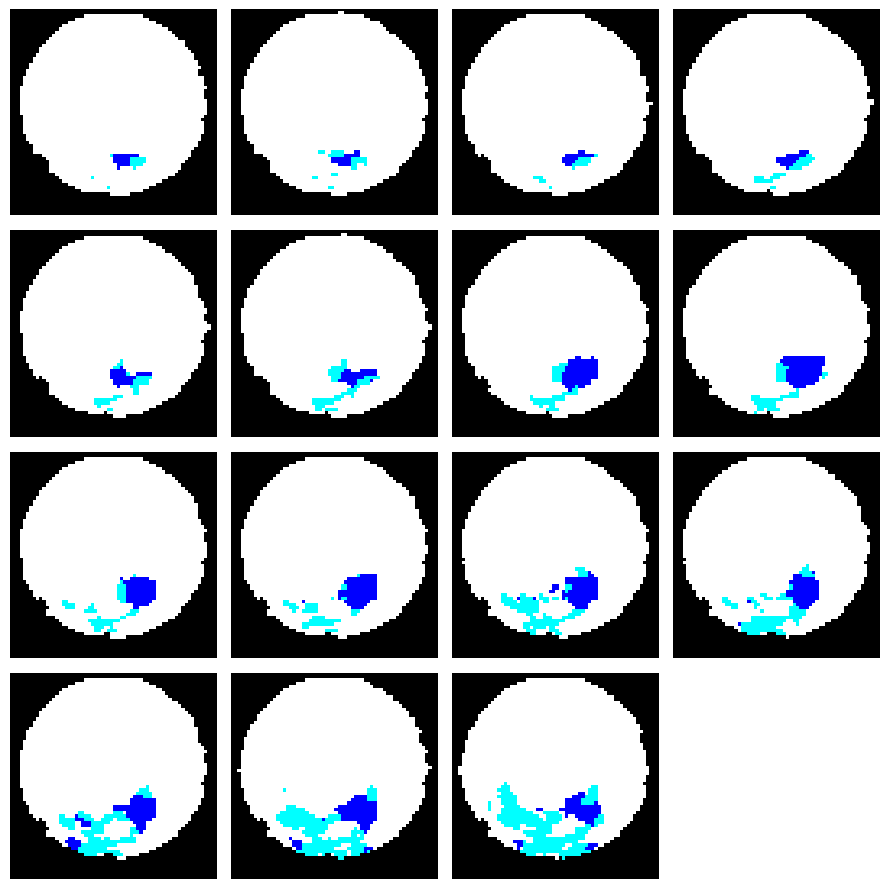

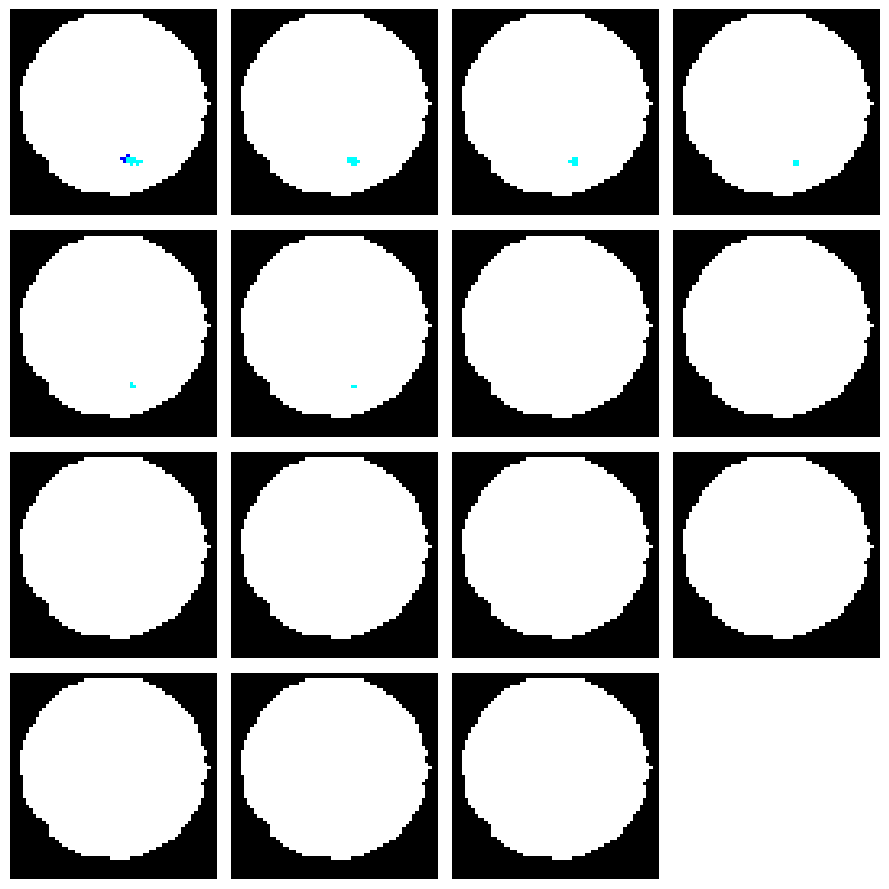

260/559


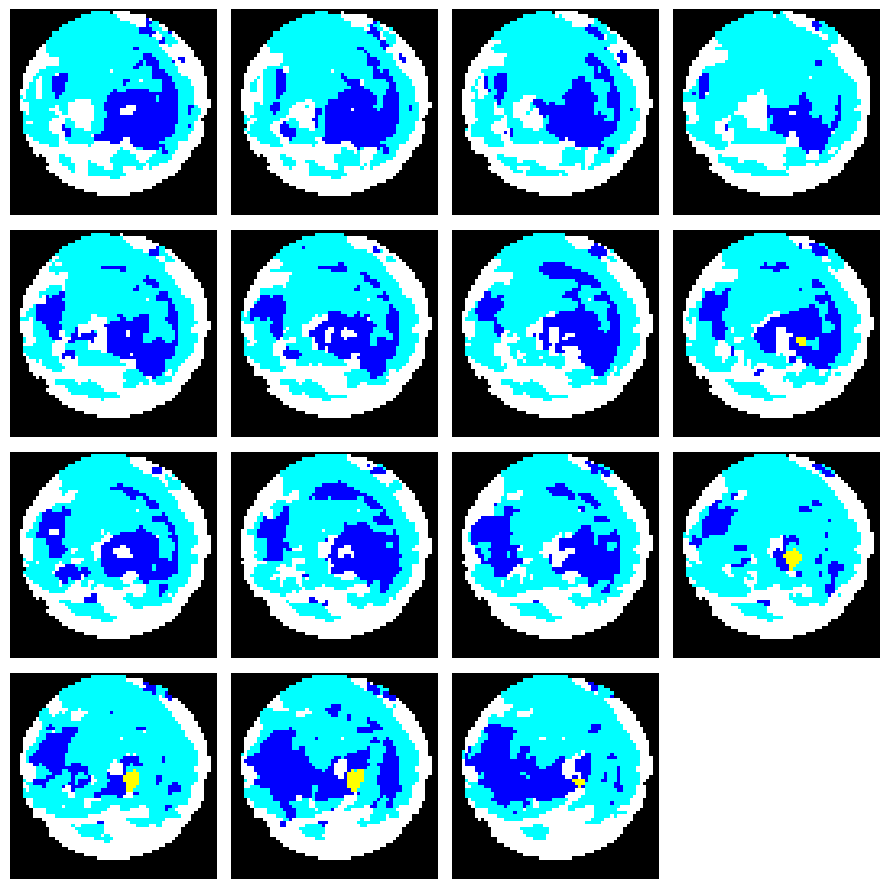

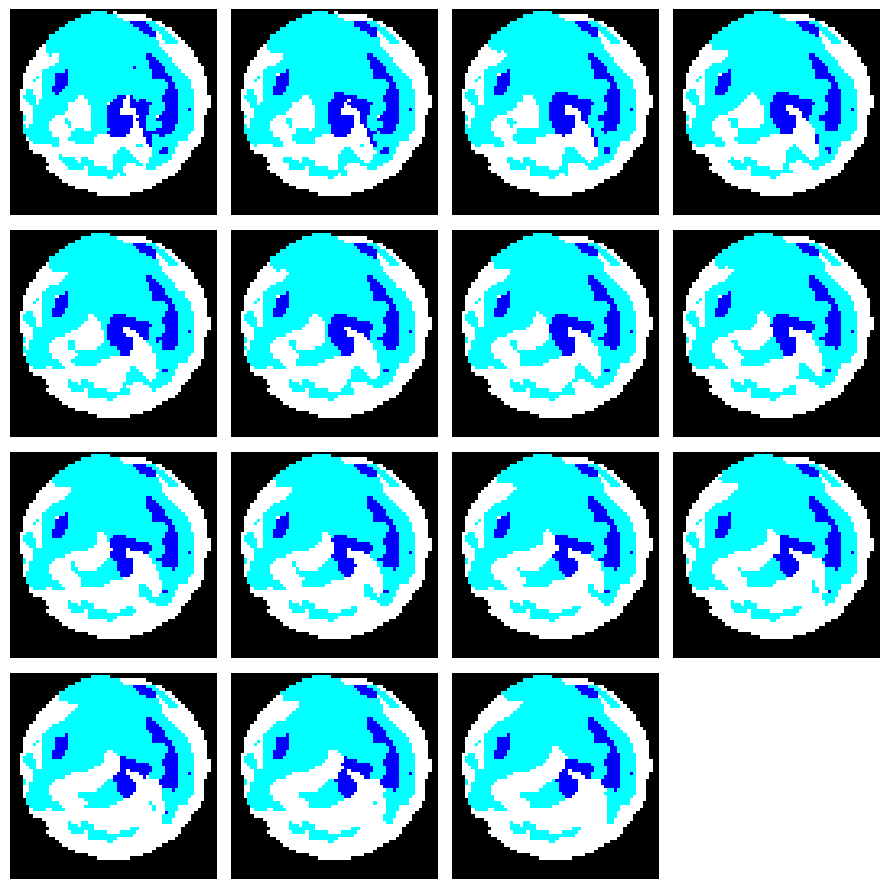

270/559


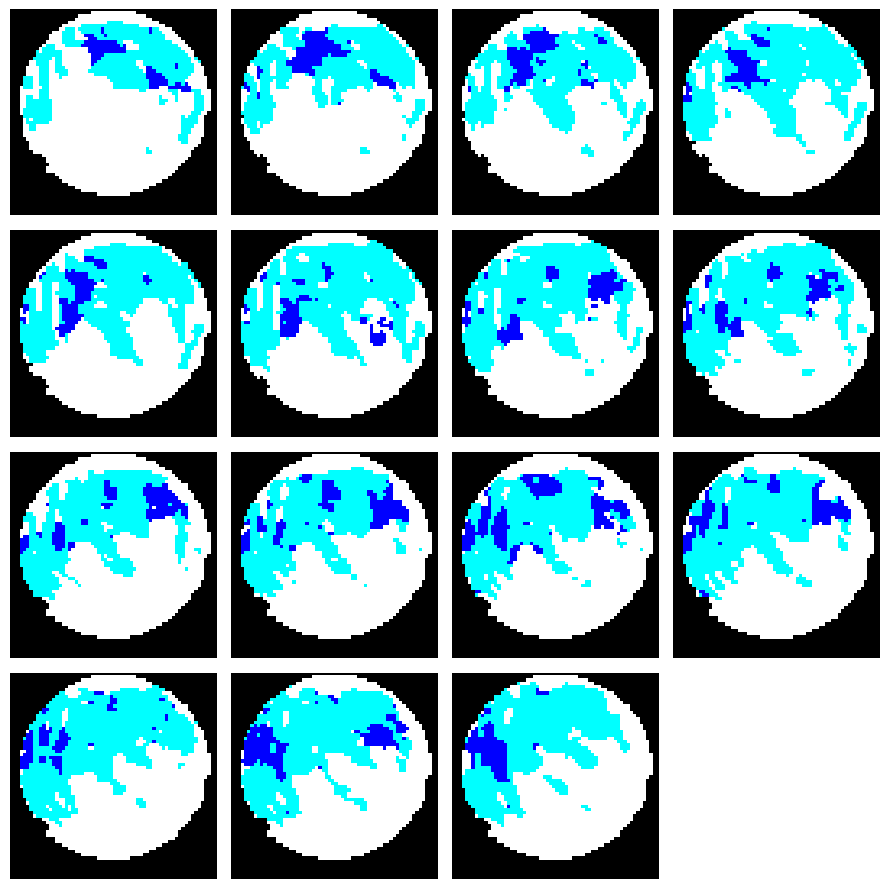

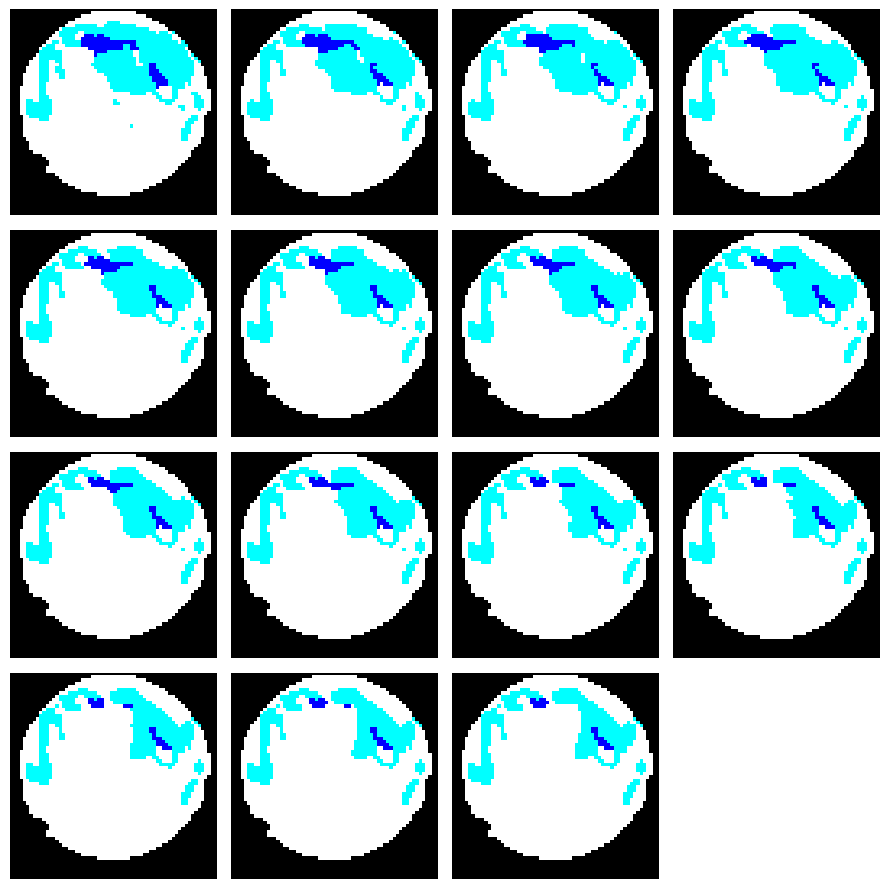

280/559


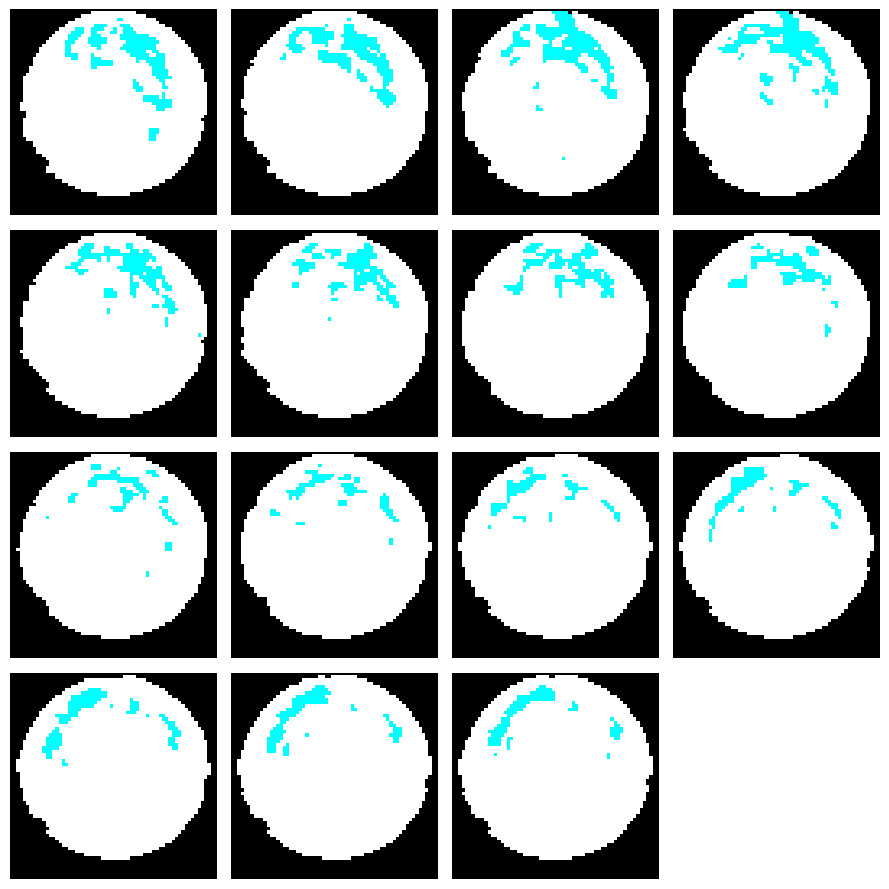

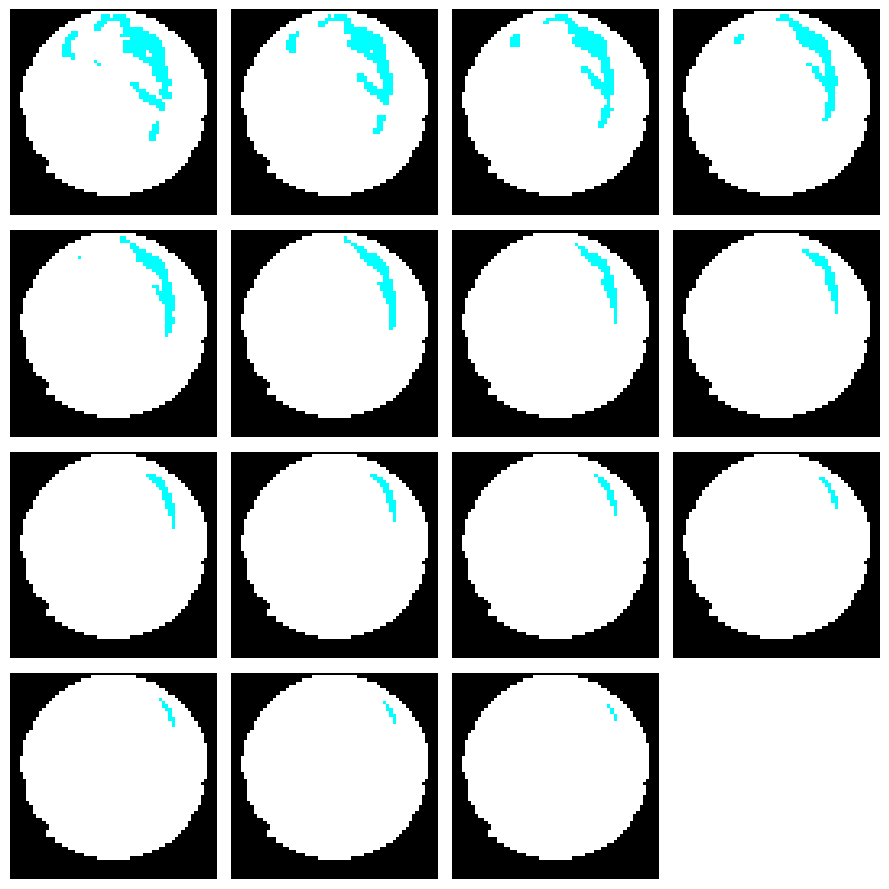

290/559


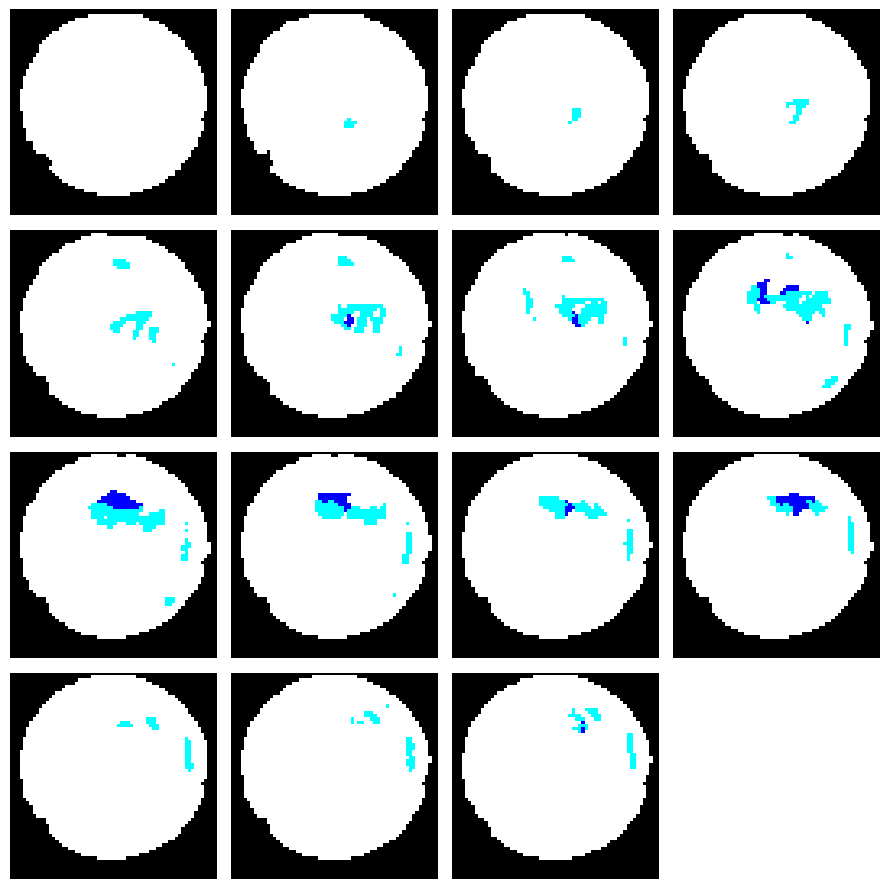

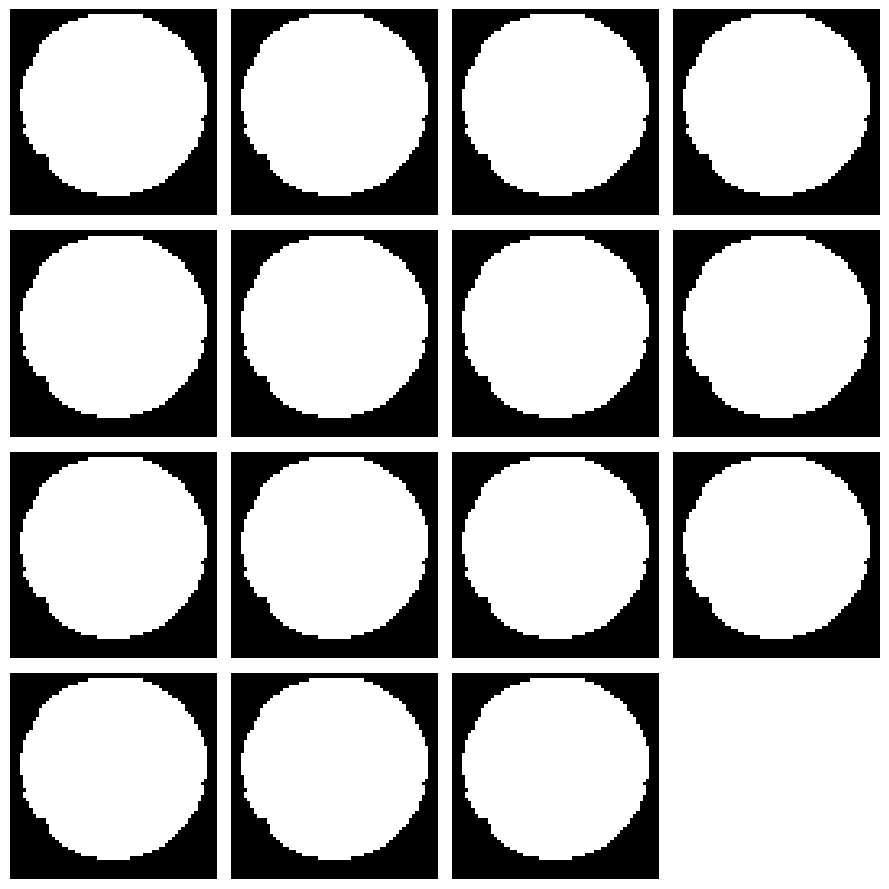

300/559


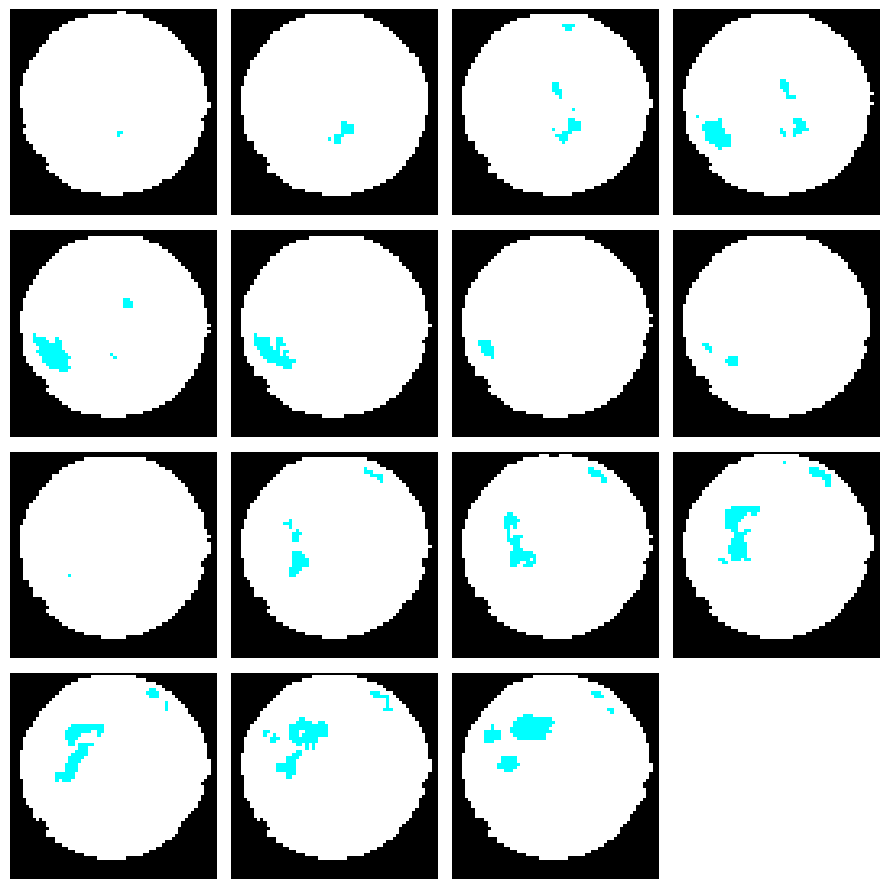

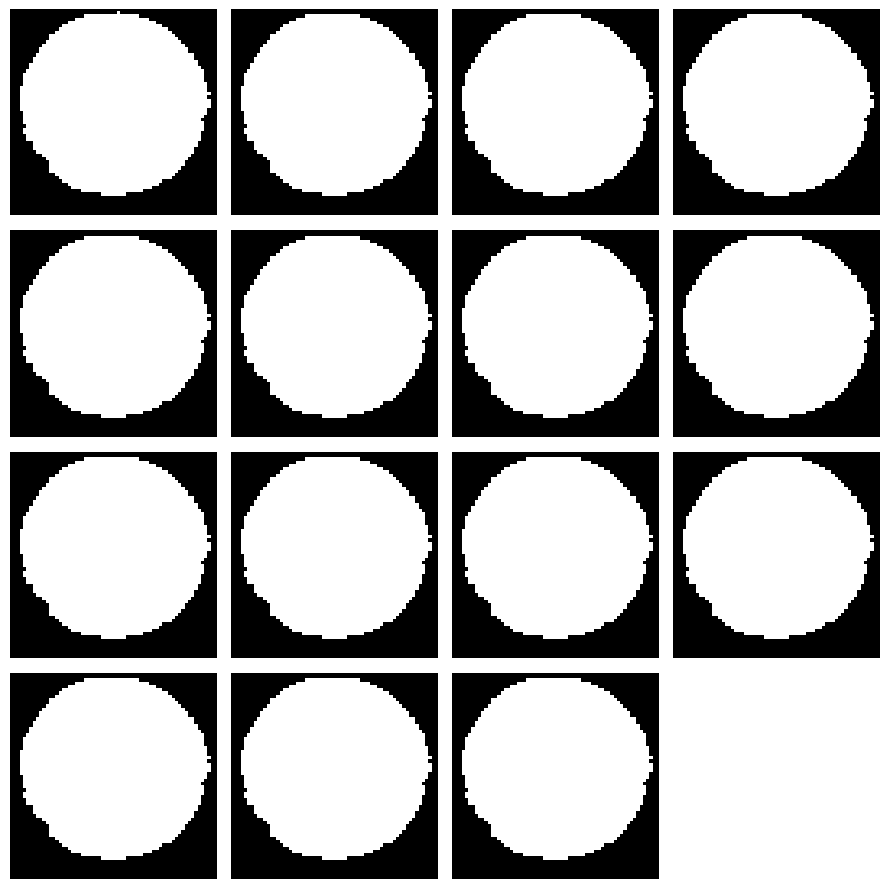

310/559


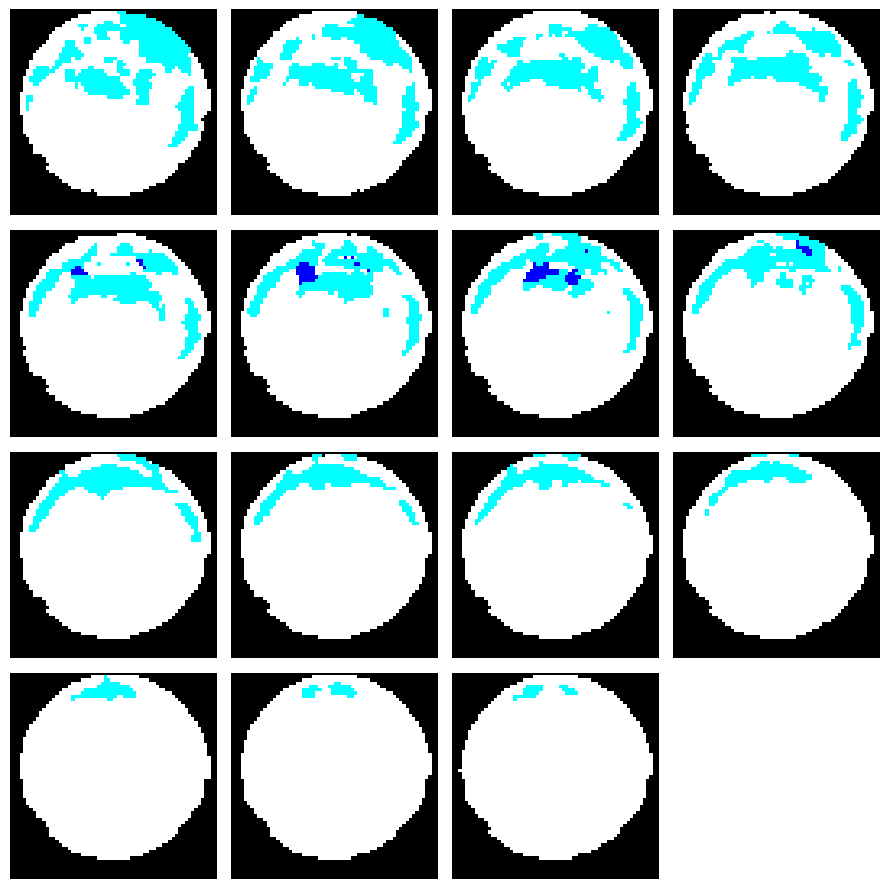

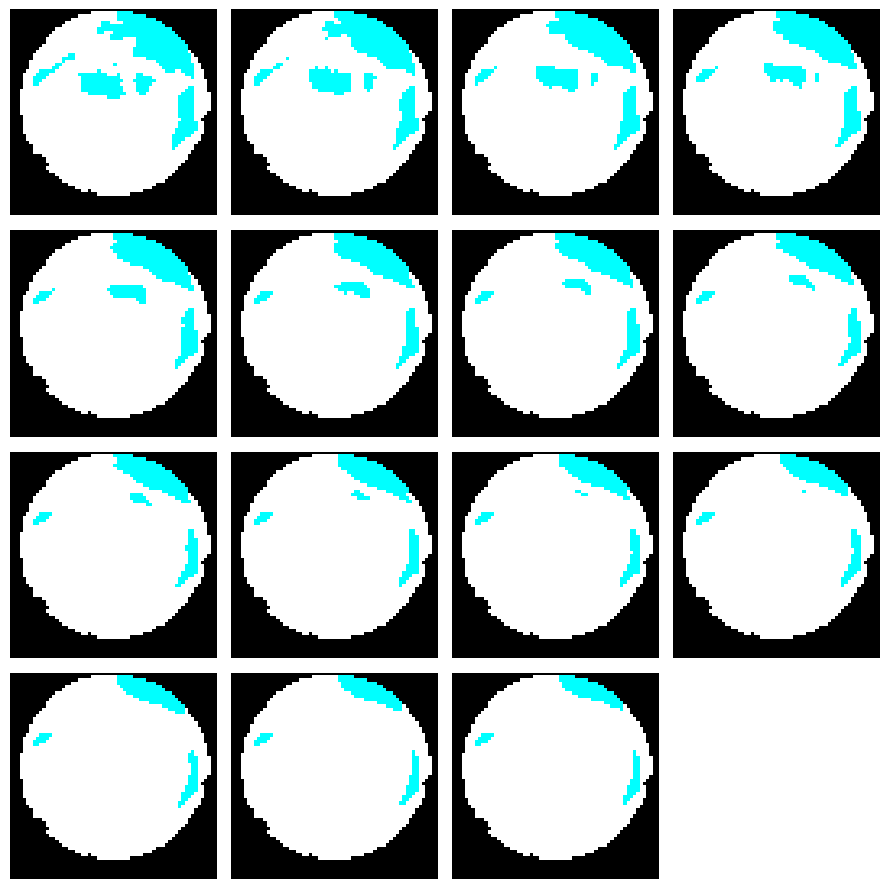

320/559


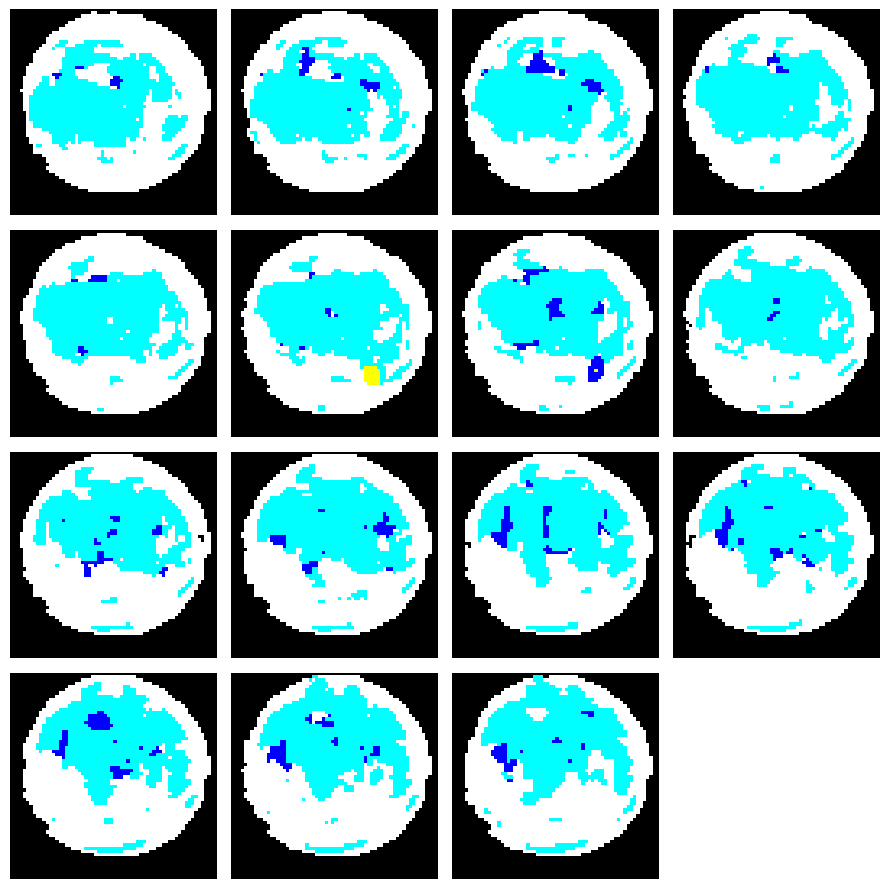

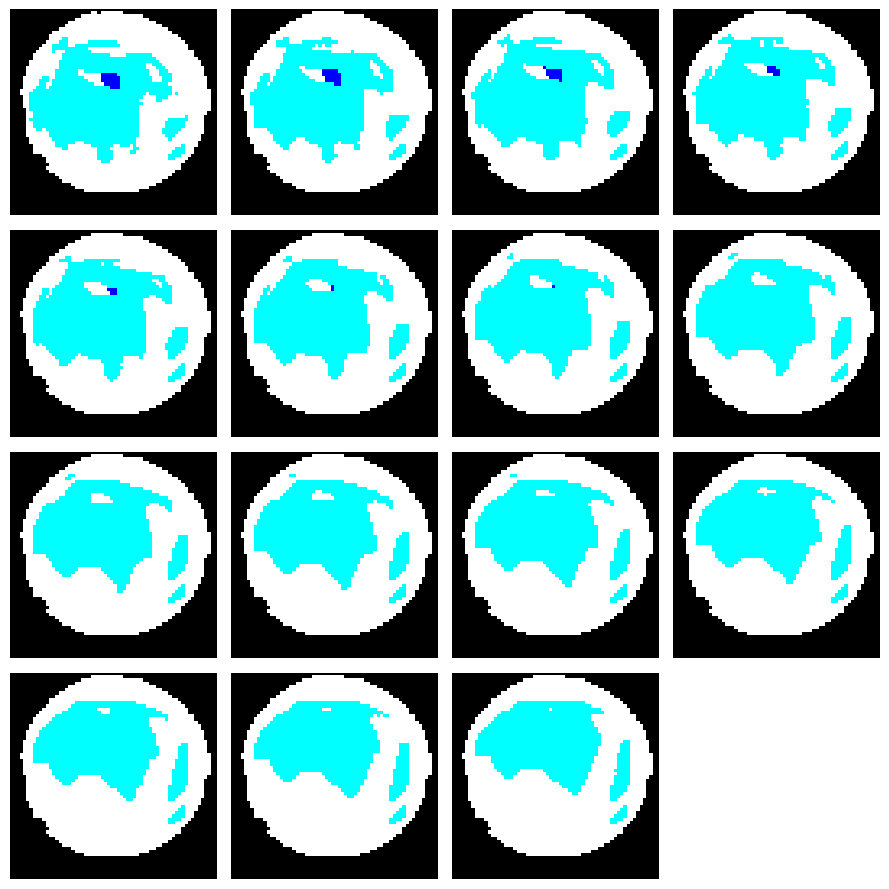

330/559


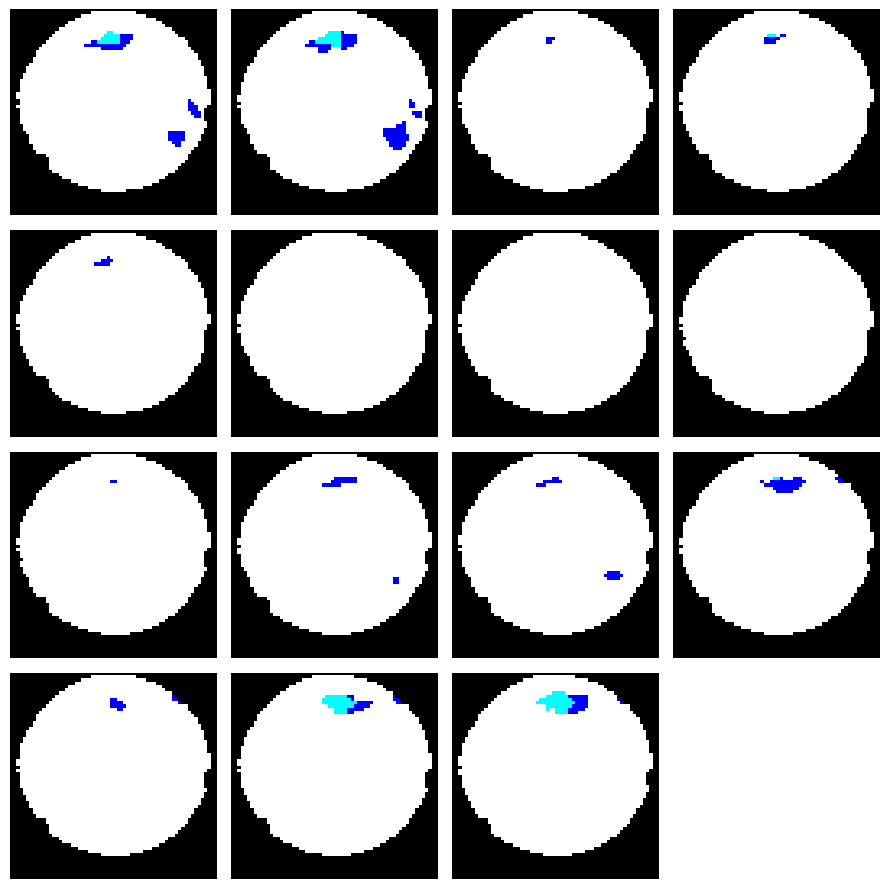

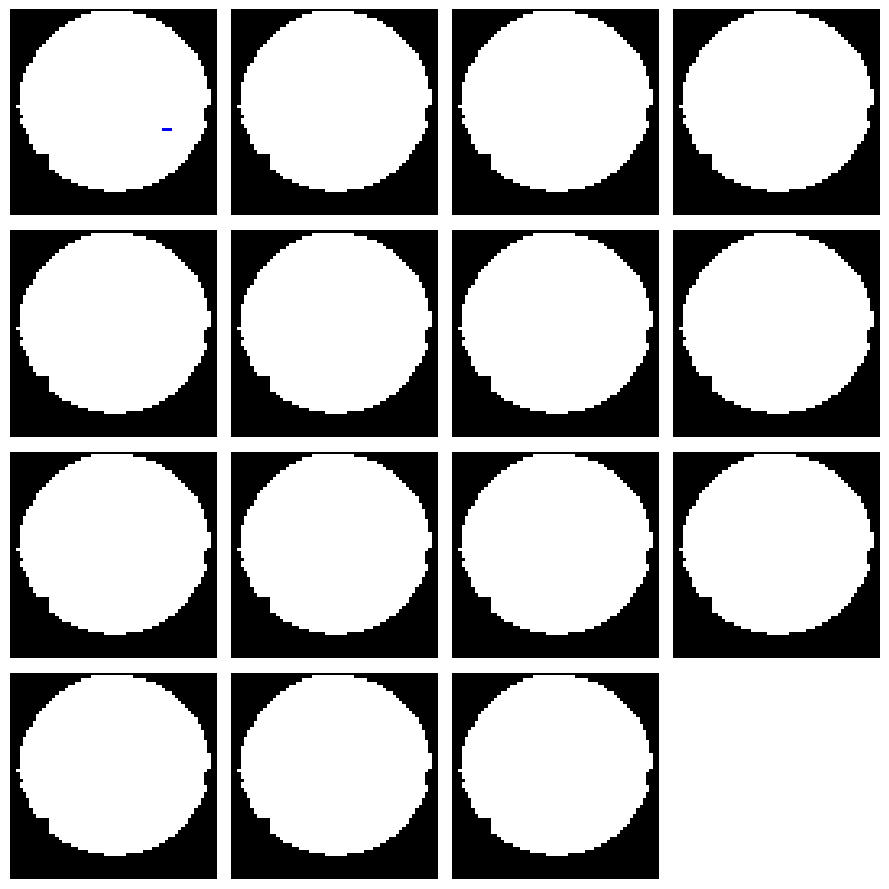

340/559


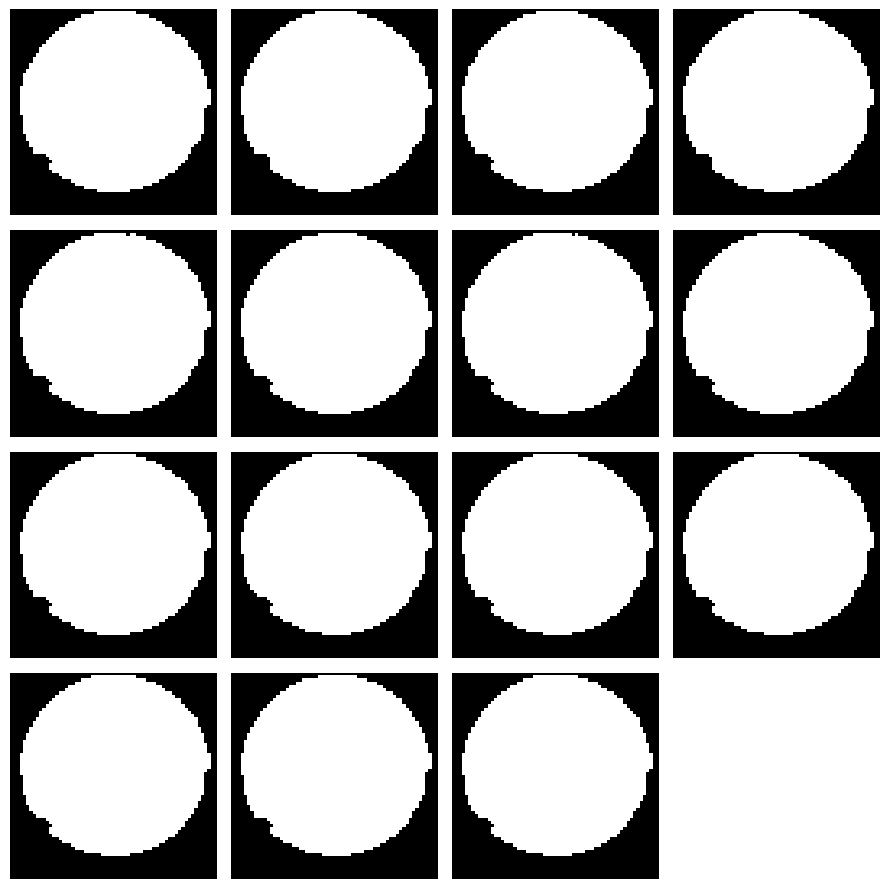

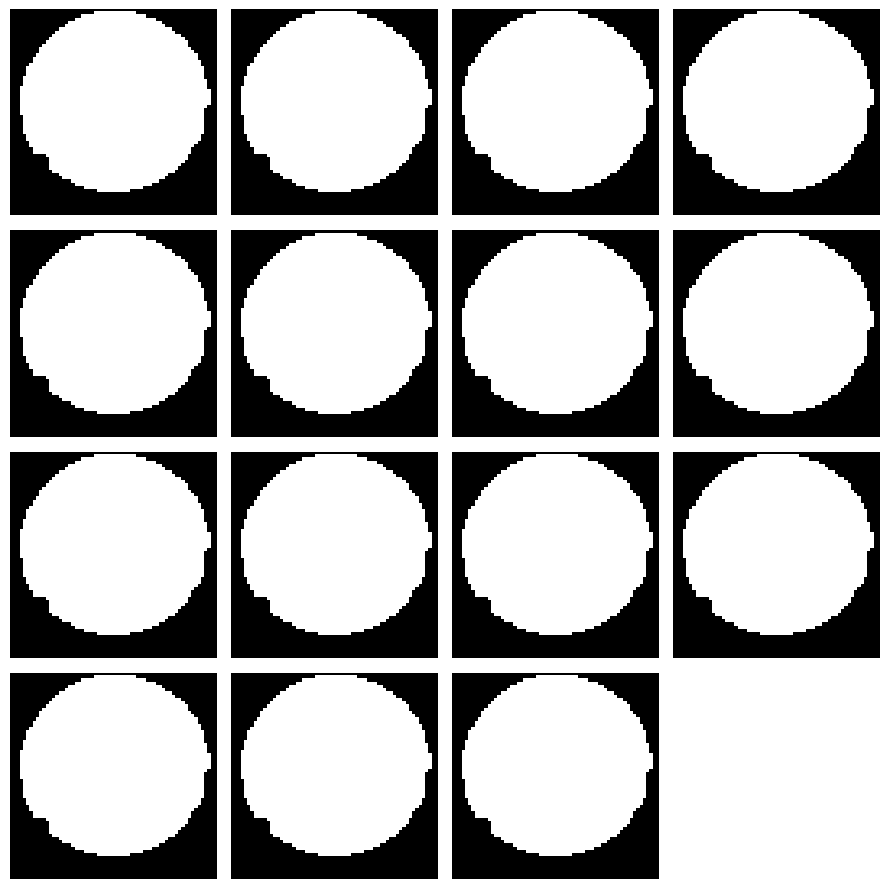

350/559


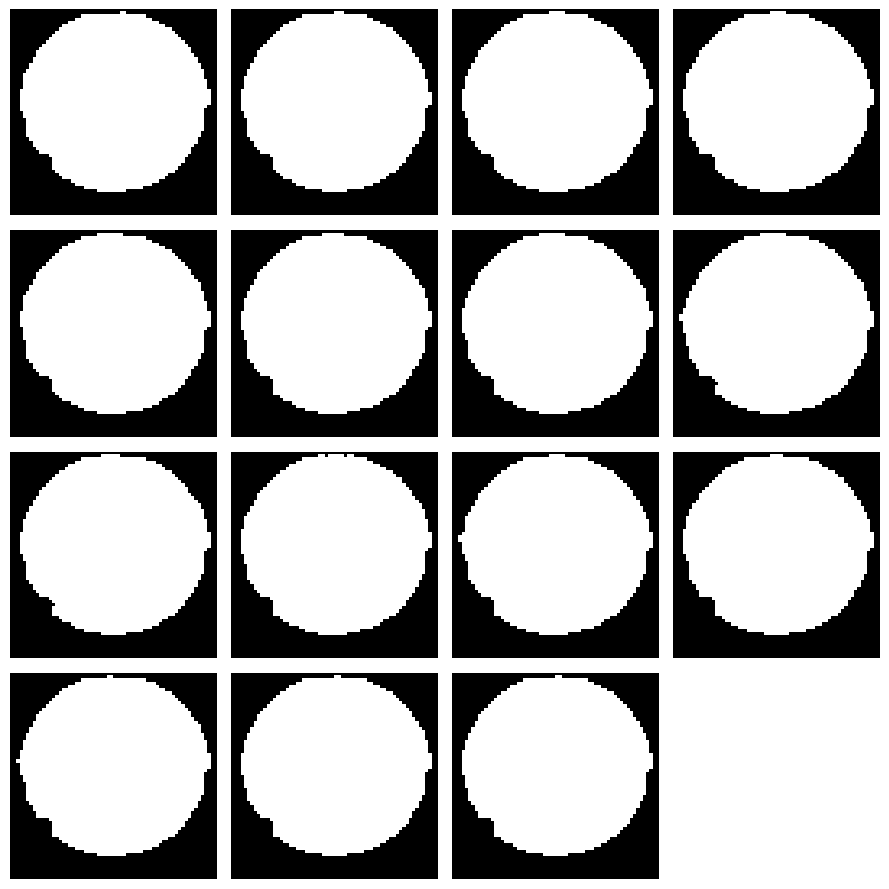

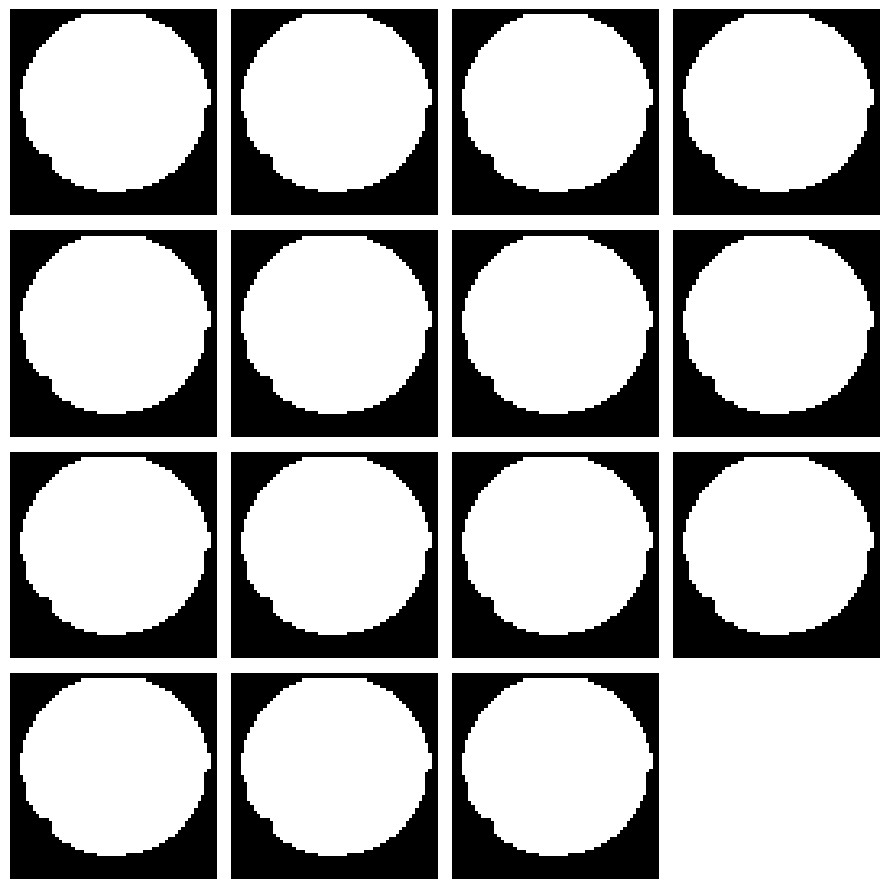

360/559


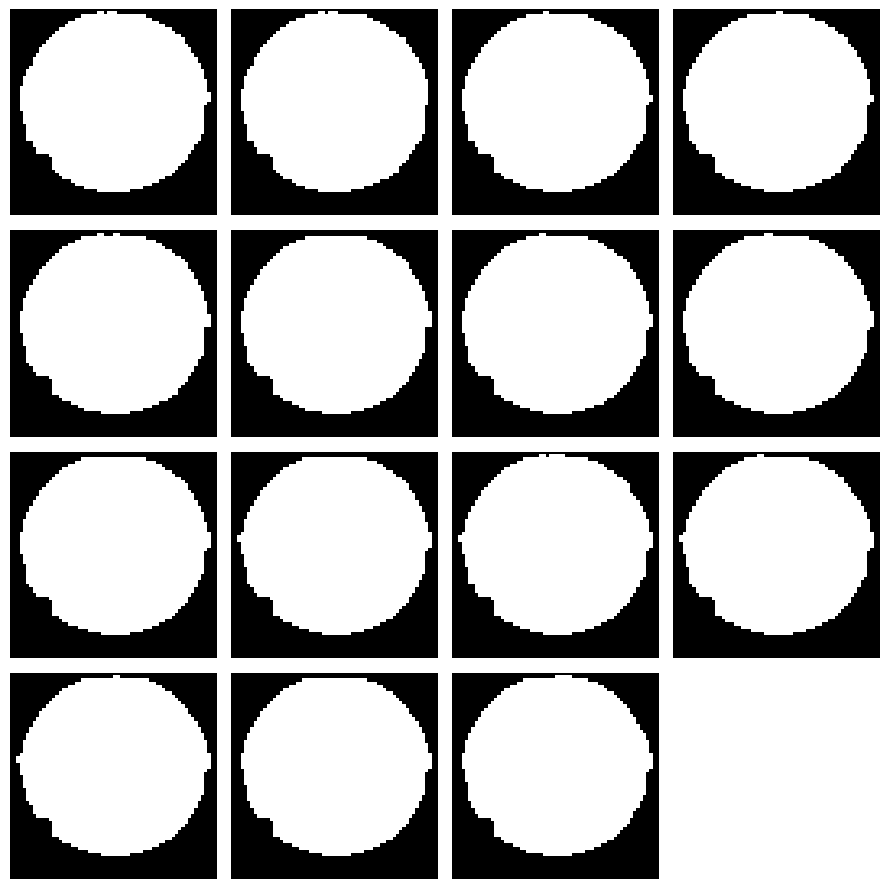

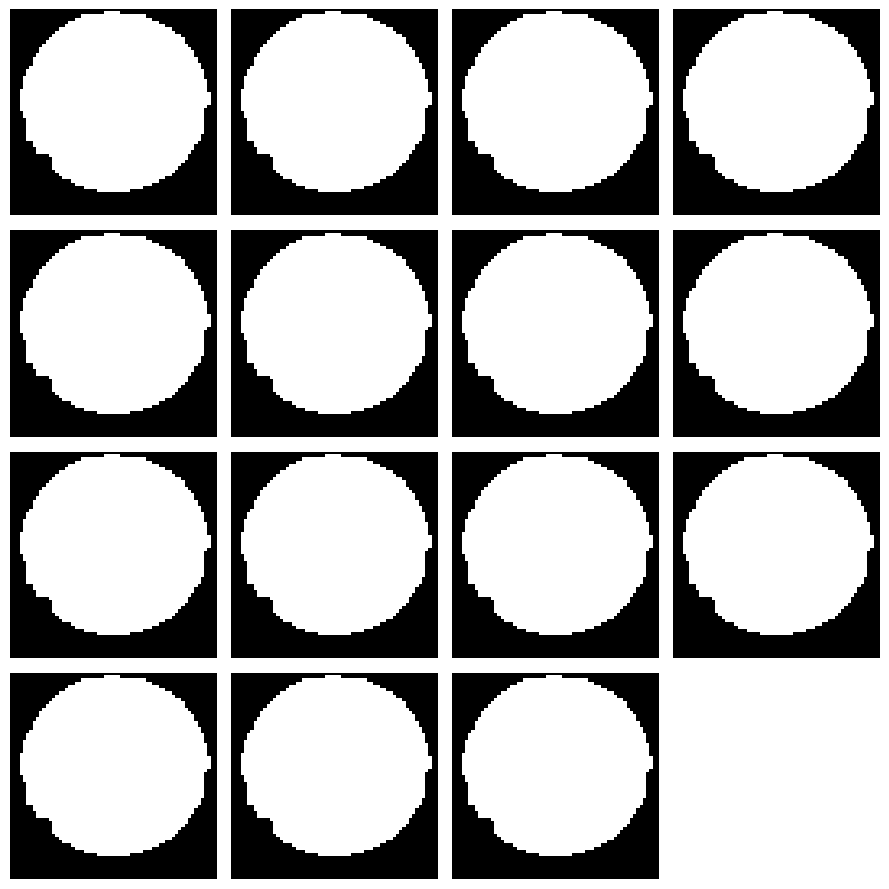

370/559


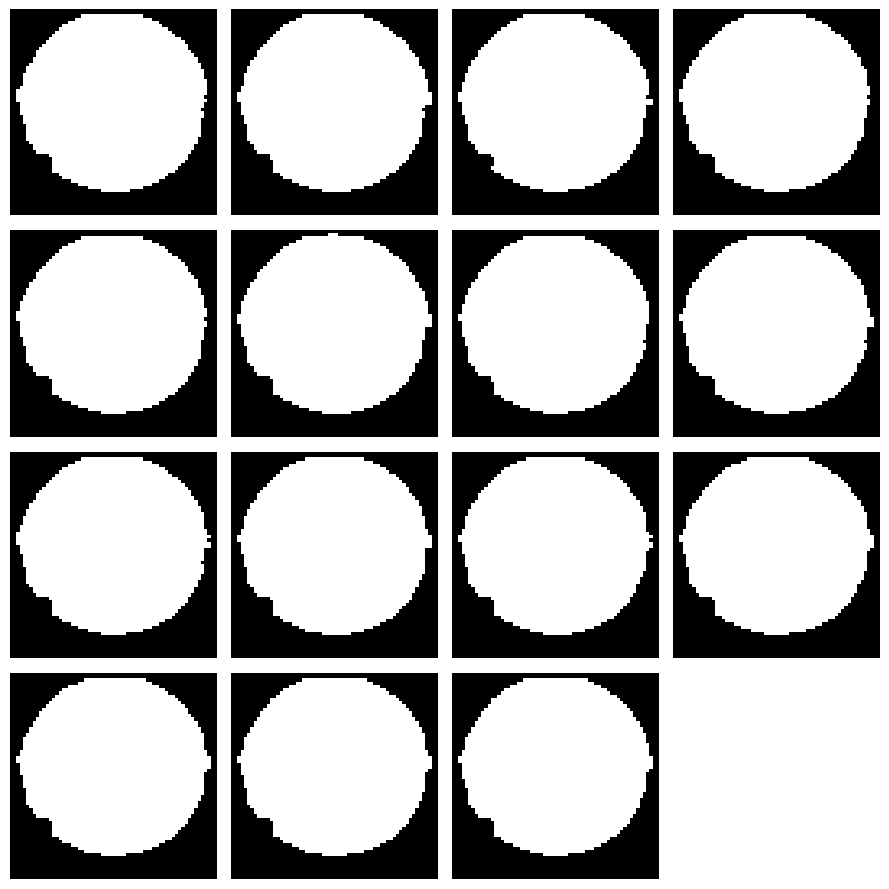

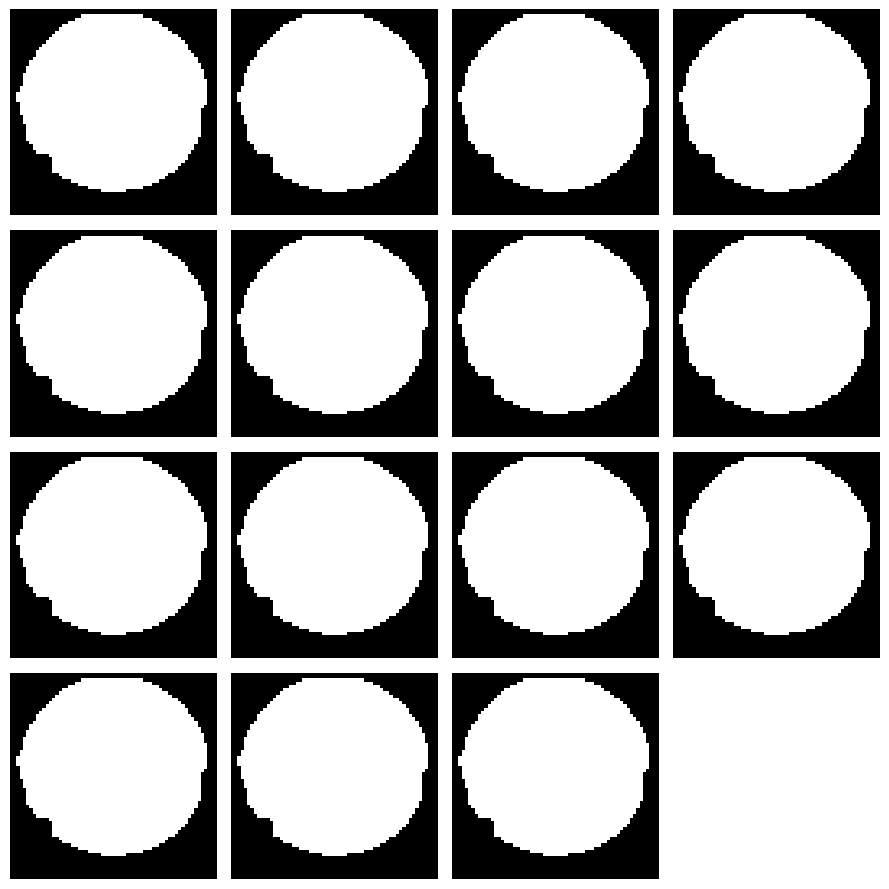

380/559


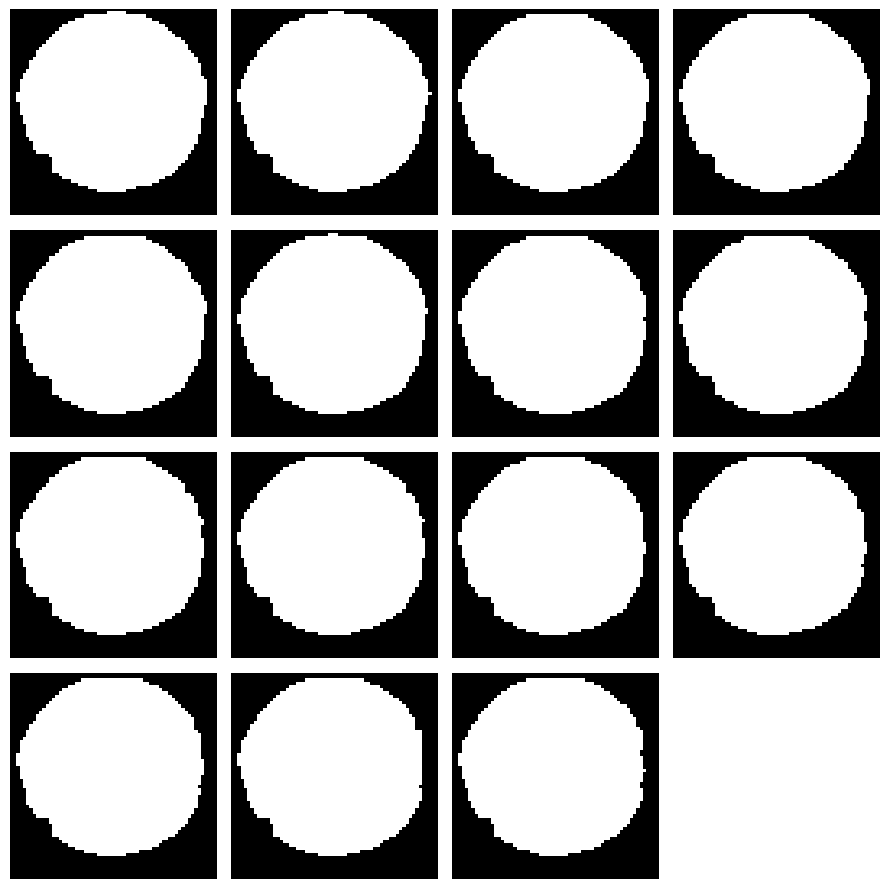

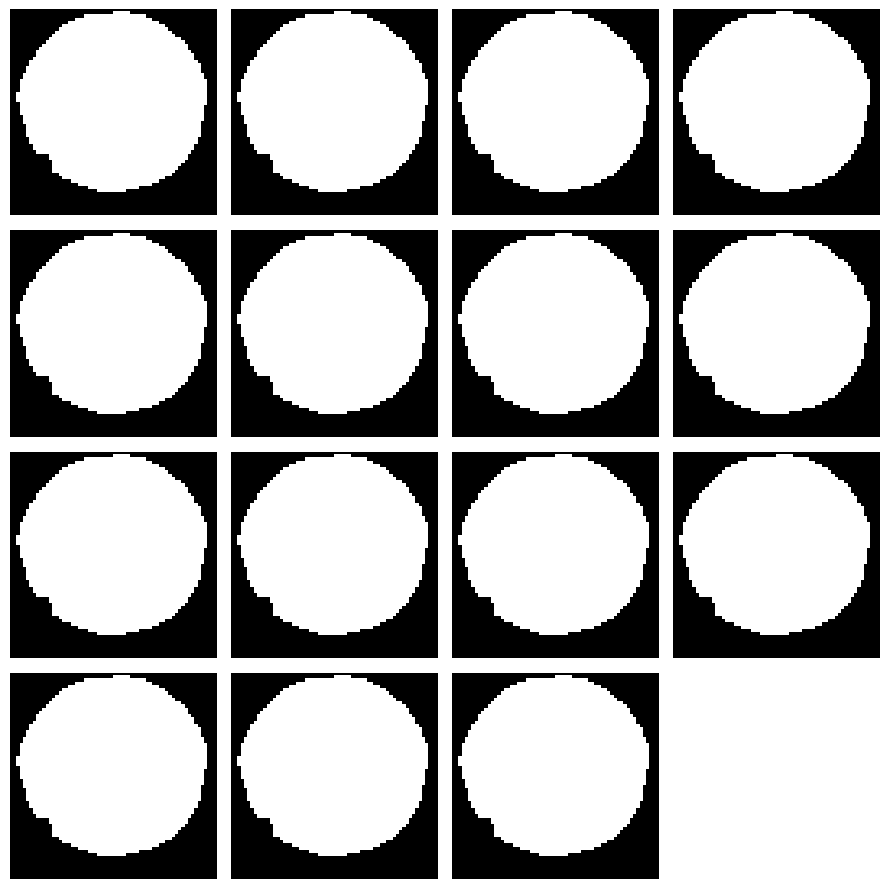

390/559


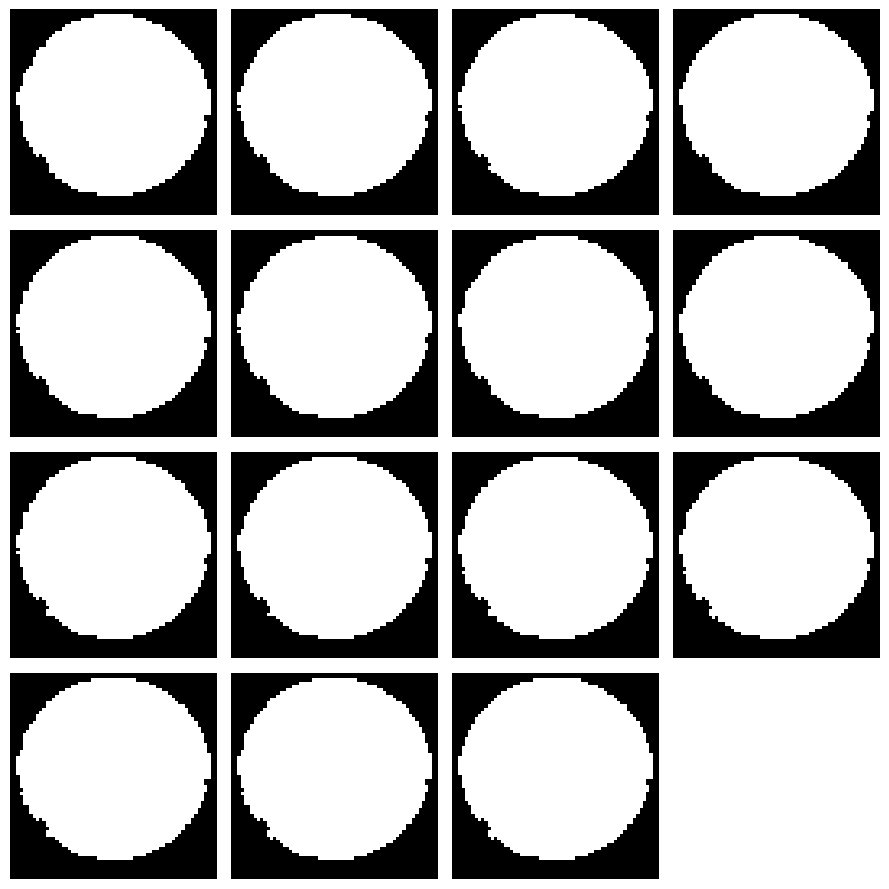

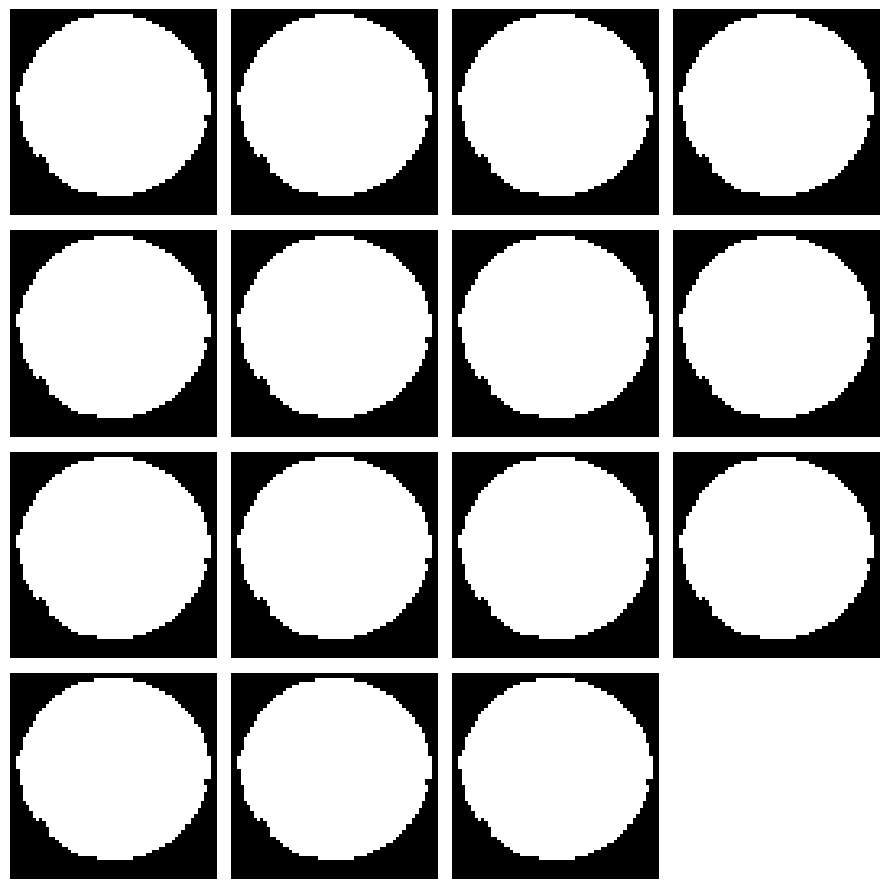

400/559


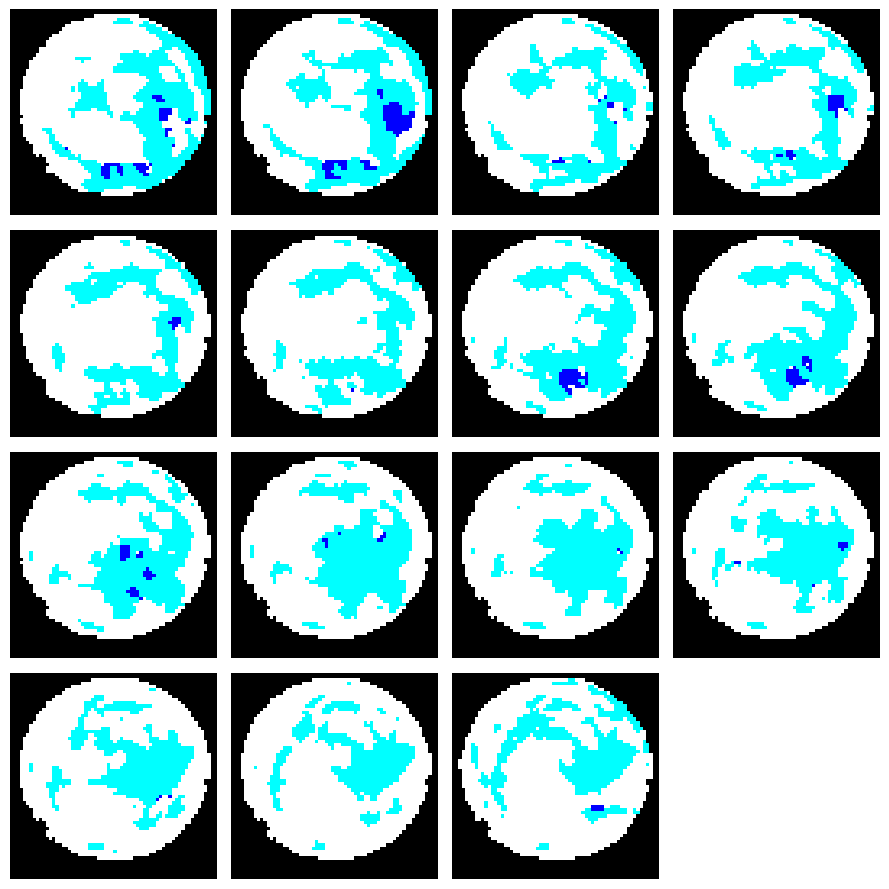

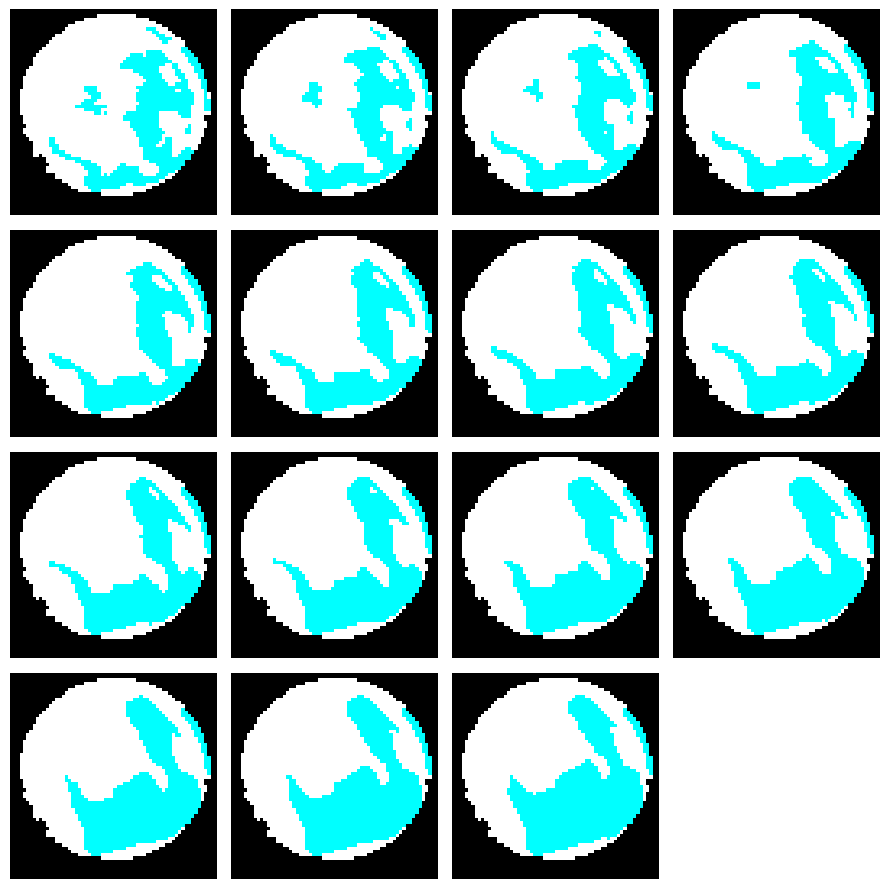

410/559


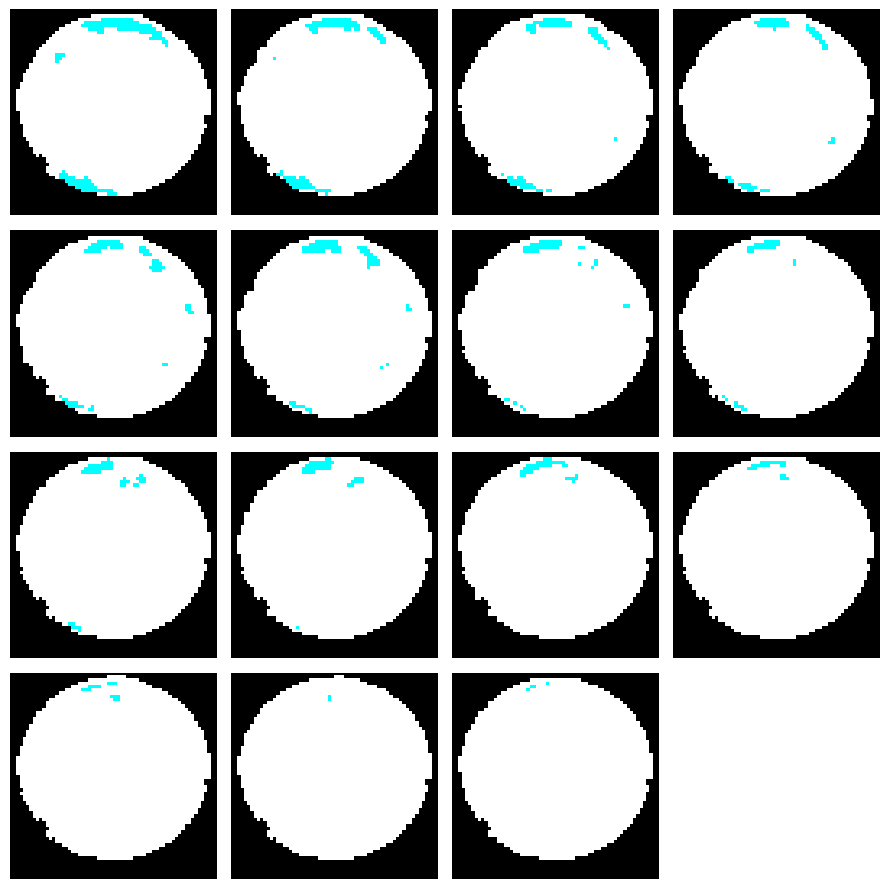

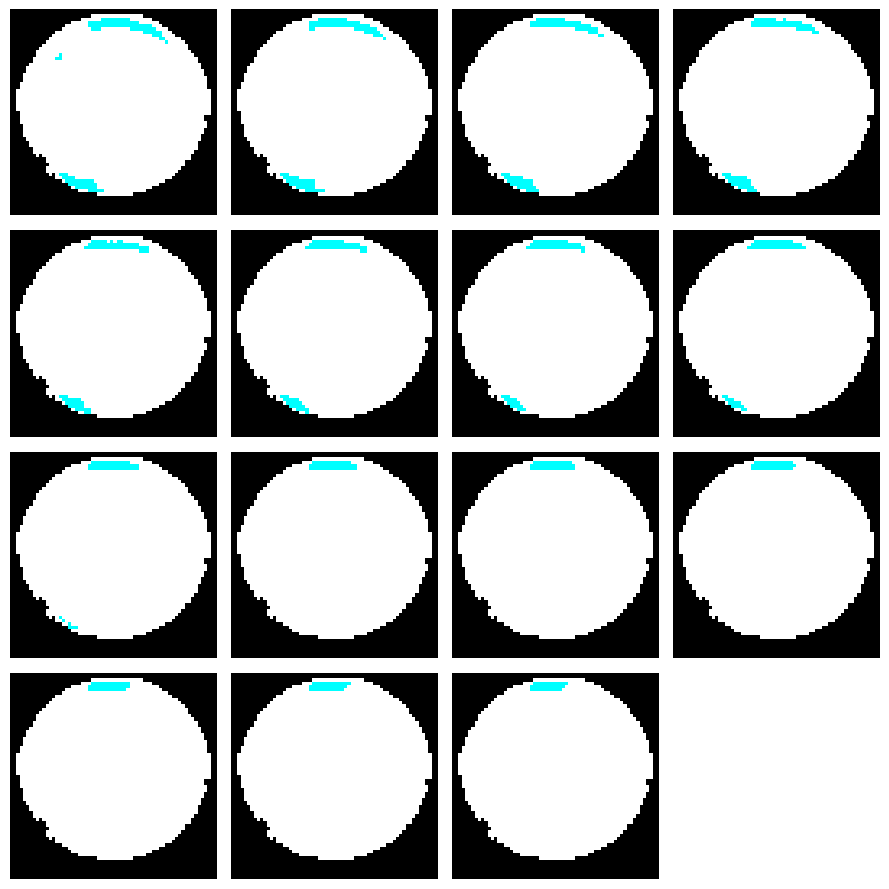

420/559


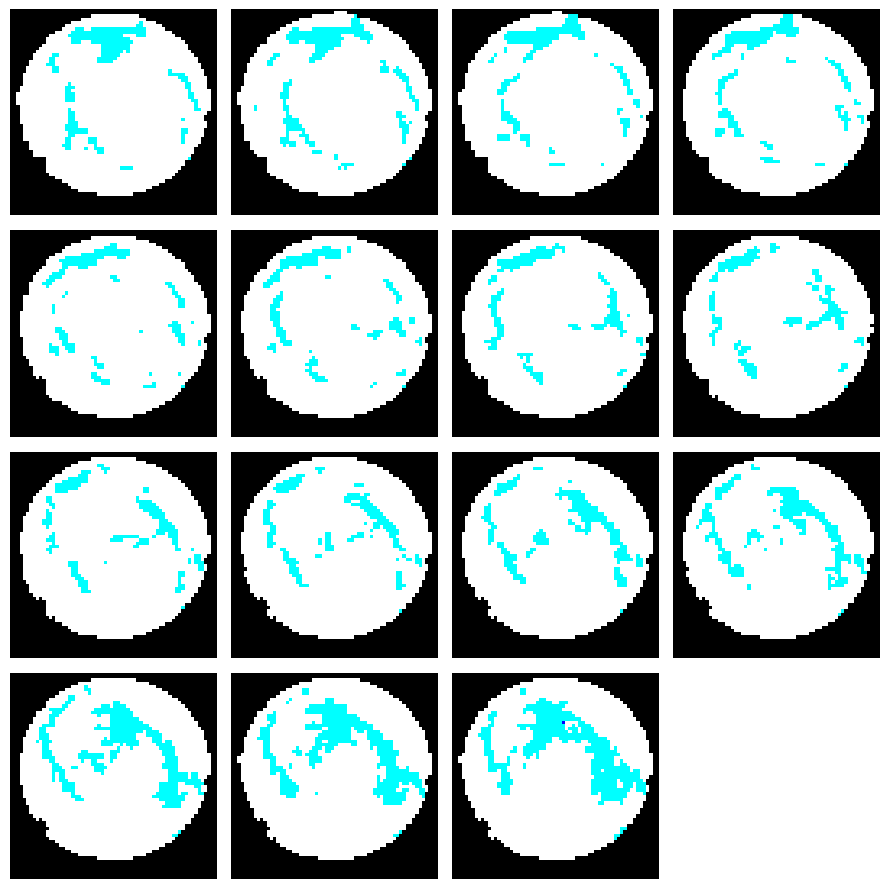

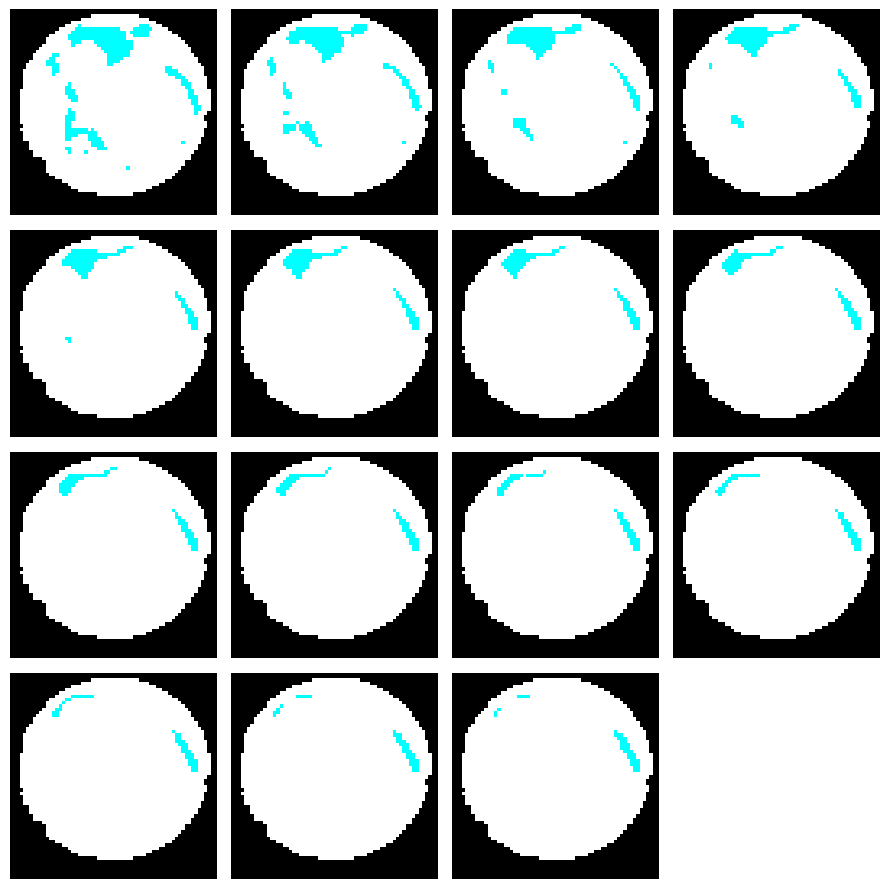

430/559


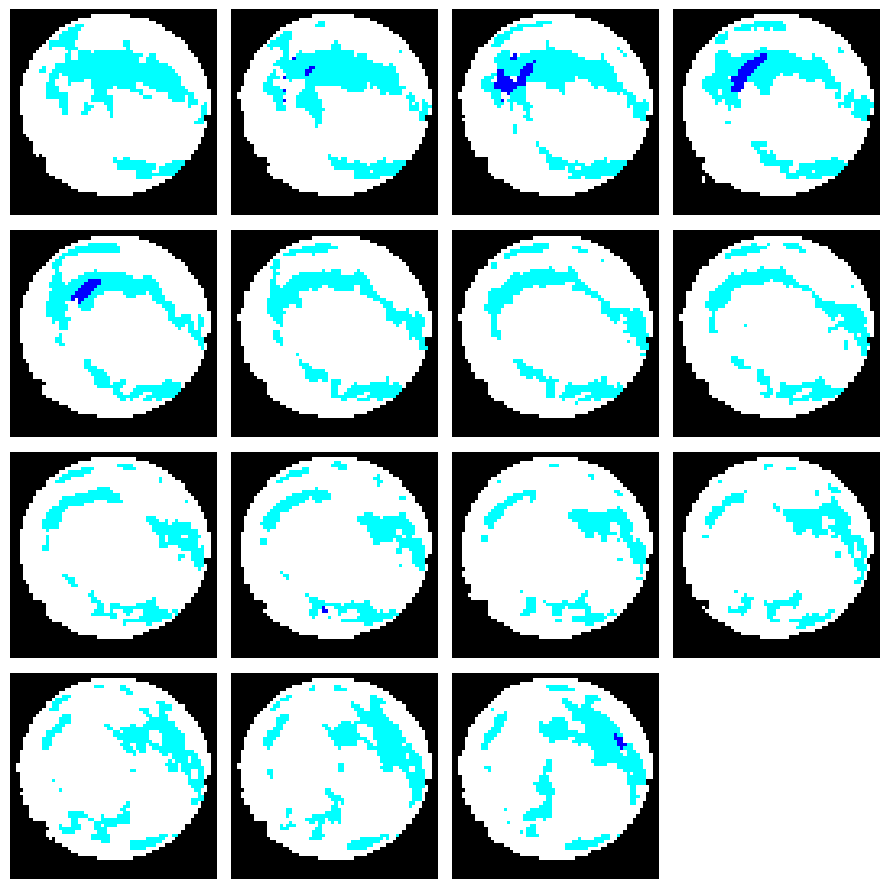

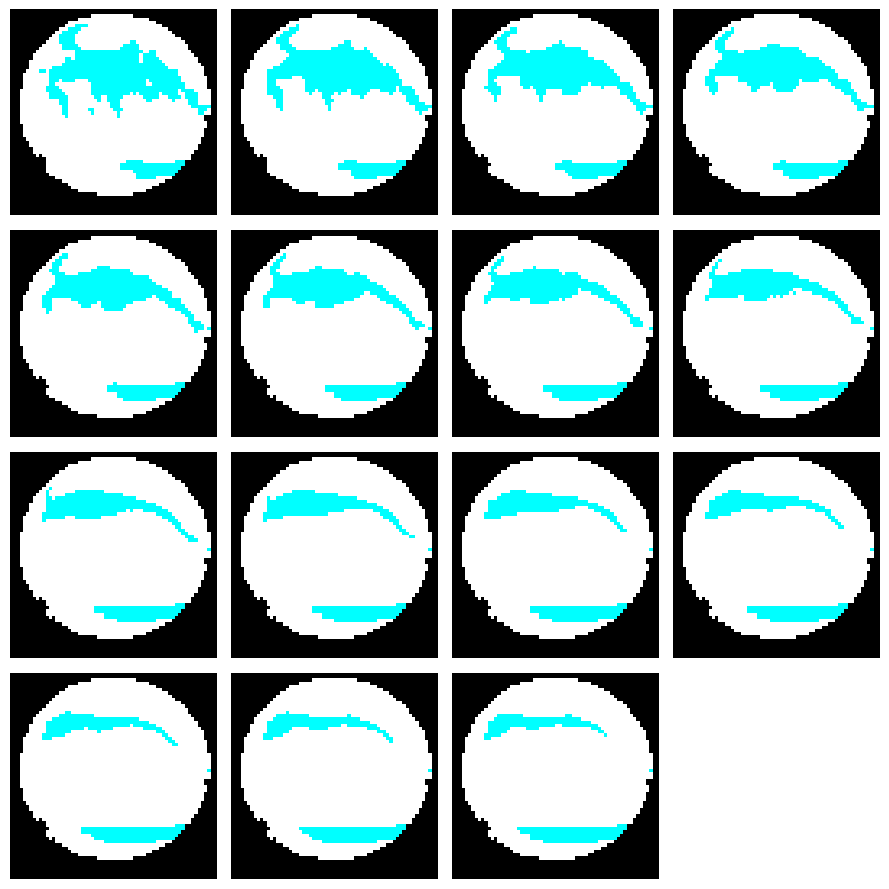

440/559


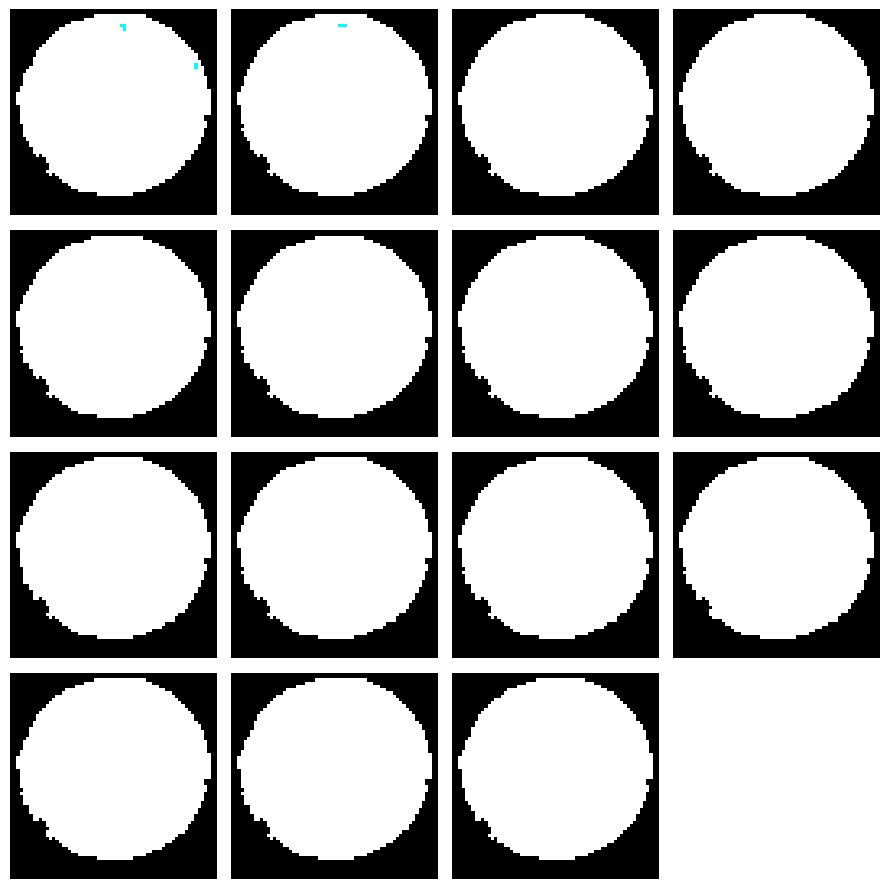

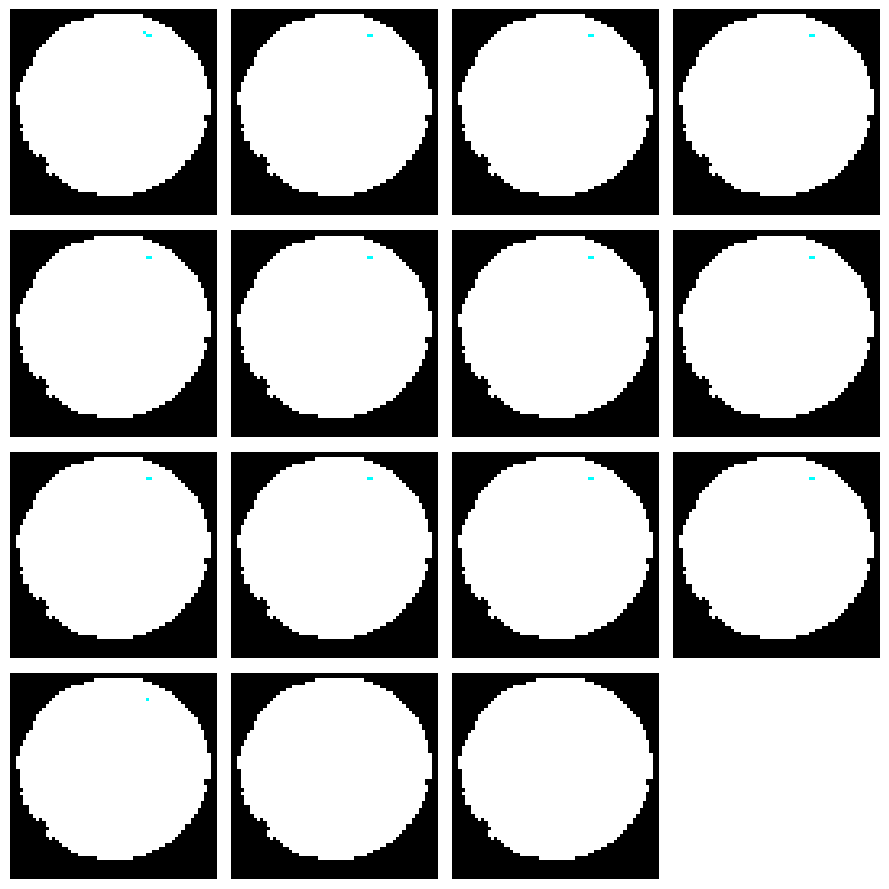

450/559


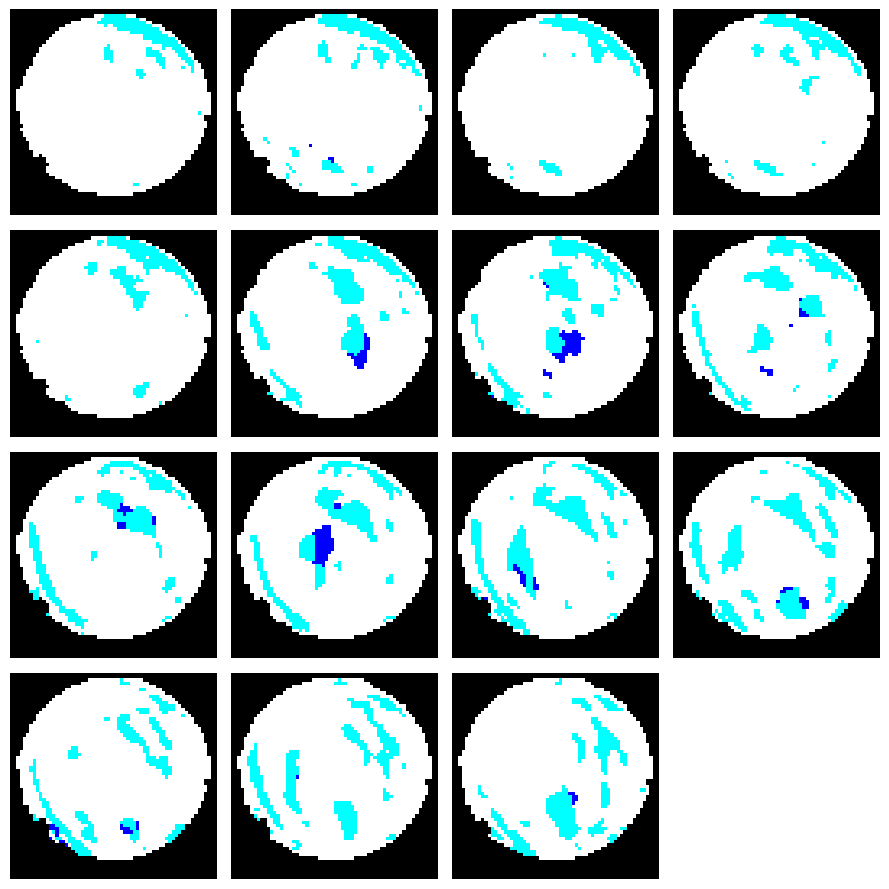

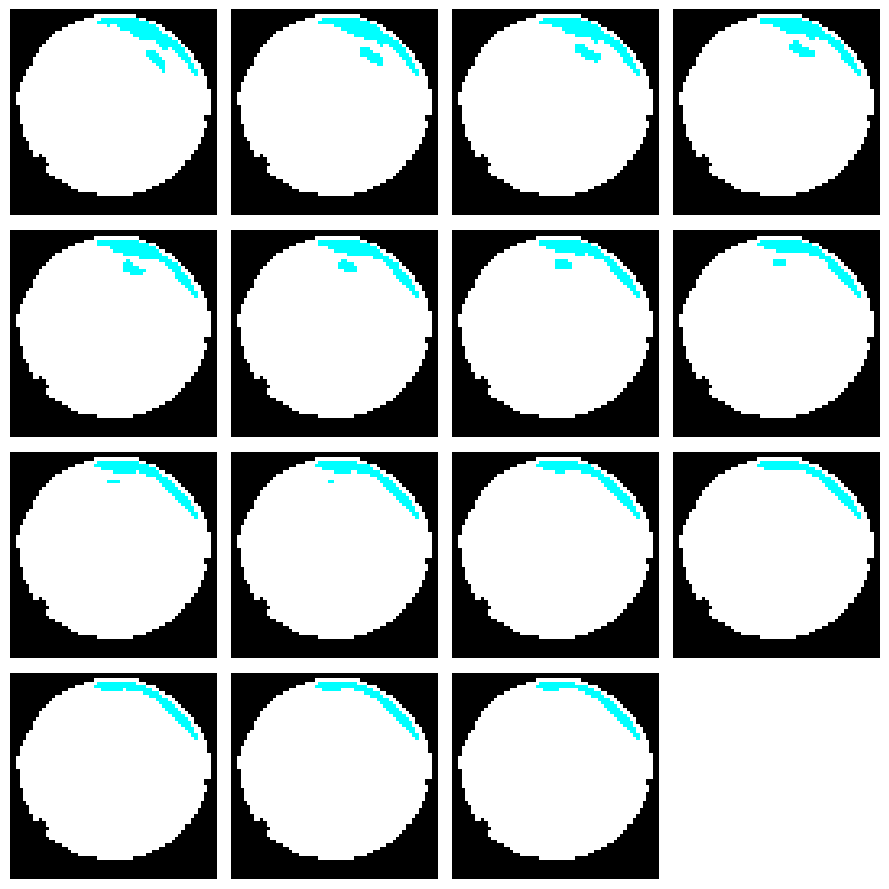

460/559


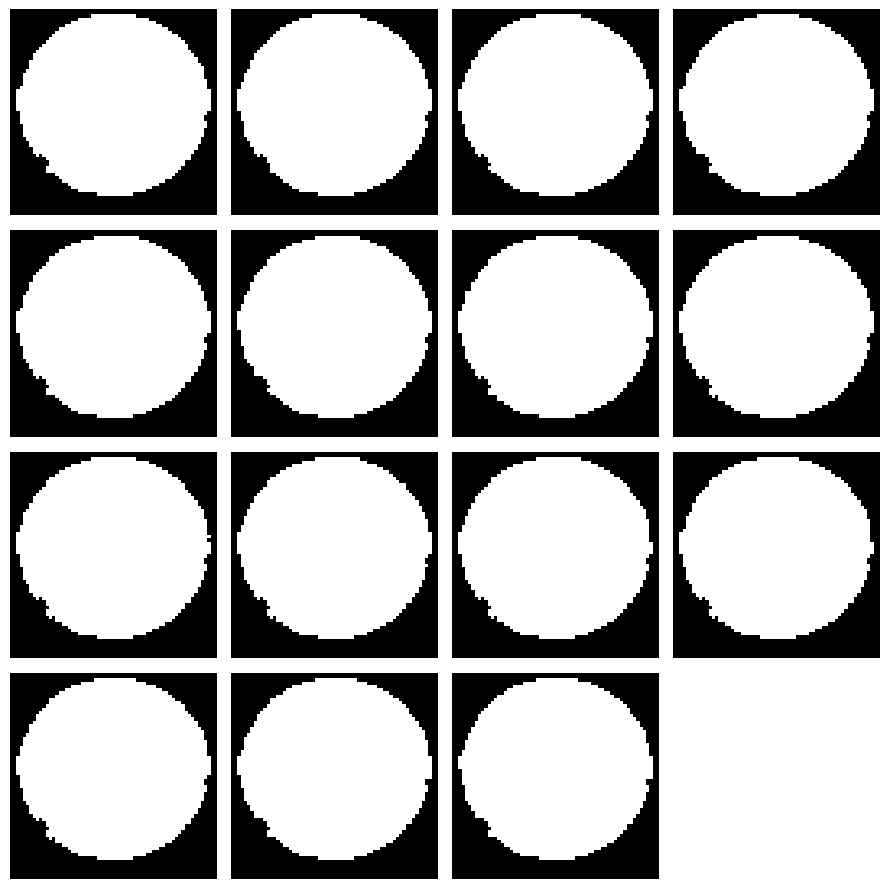

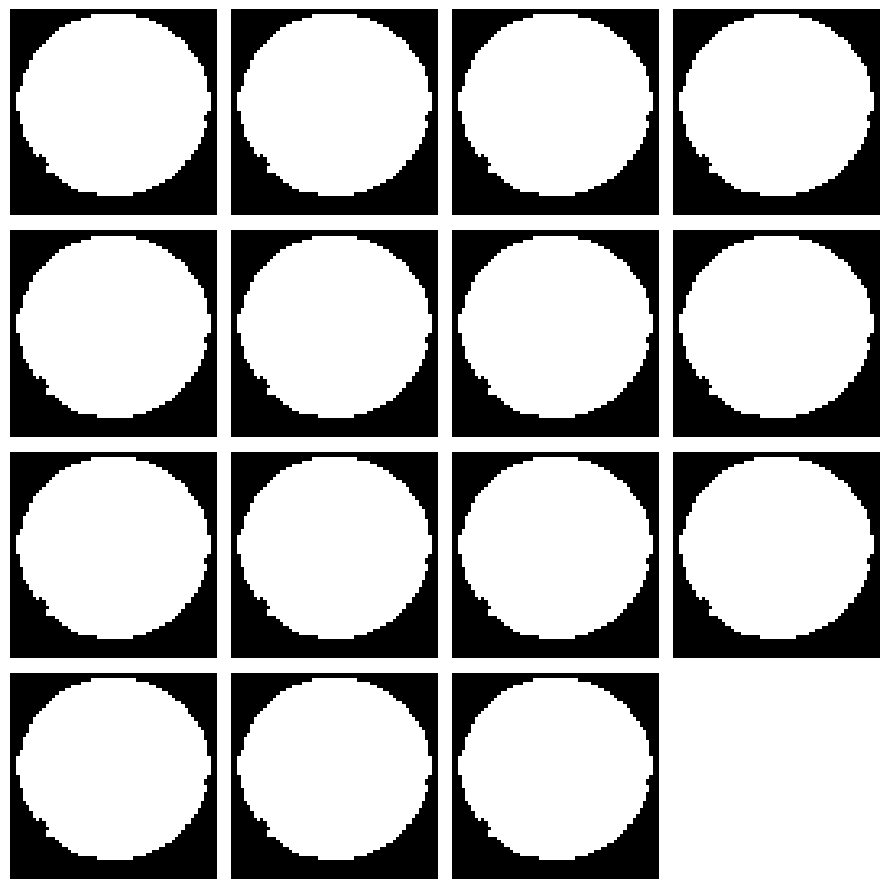

470/559


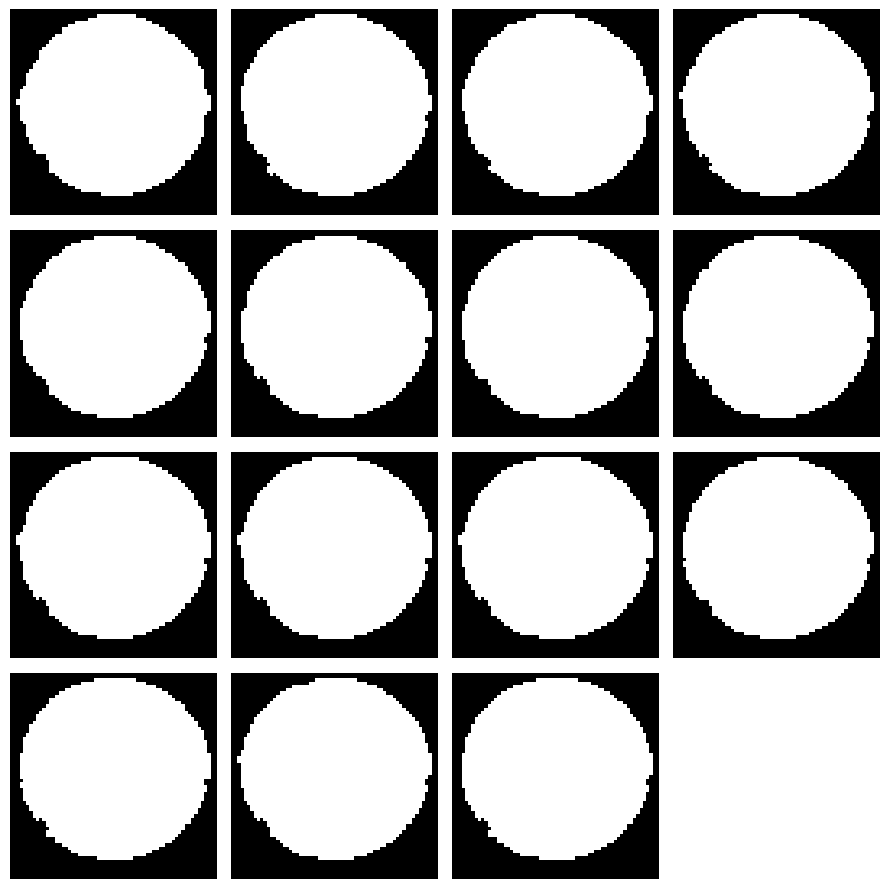

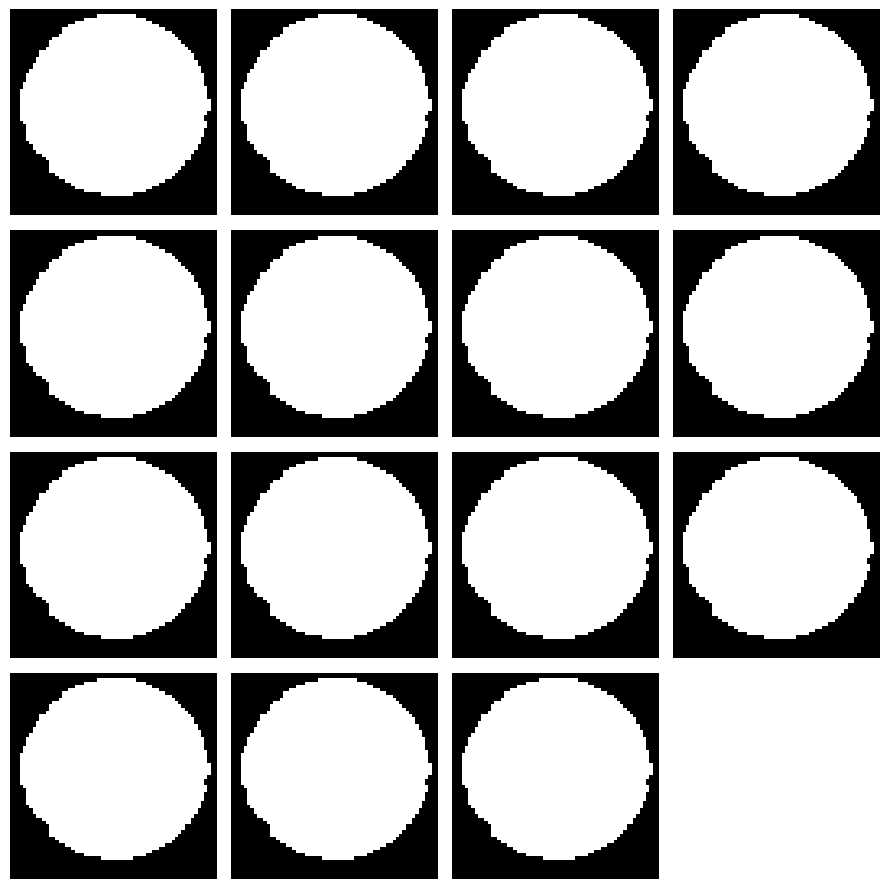

KeyboardInterrupt: 

In [69]:
for idx, (mtarg, mseg) in enumerate(btest_loader_mask):
  if idx % 10 == 0:
    print(f"{idx}/{len(btest_loader_mask)}")
    show_mask(mtarg[0])
    show_mask(mseg[0])